# Integrated Optical → SAR Crop Type + Health + Yield Pipeline

Run cells top-to-bottom. The optical stage creates `optical_crop_output` and `optical_health_output`; the SAR stage consumes them directly and also receives the standardized CSV handoff.

# Sokhda Village — End-to-End Crop Classification + Crop-Specific Health Assessment

## Pipeline Overview

This notebook implements a **two-stage satellite-derived field analysis pipeline**:

```
Stage 1 — Crop Classification
  Sentinel-2 optical time-series (NDVI/NDWI/moisture)
       ↓ phenology feature extraction
       ↓ KMeans phenology clustering (fixed k=5 for template assignment)
       ↓ Hungarian cluster→crop template matching
       ↓ weak_crop_type + weak_confidence
       ↓ confidence quality flag (threshold = 0.25)
       ↓
  classification_df  →  crop_type  (per field_id; low-confidence labels retained)

Stage 2 — SAR Crop Type + Health Prediction
  Same Sentinel-2 data (full spectral: B02–B12 + SCL)
       ↓ NDVI / EVI / SAVI / MSAVI / GNDVI / NDRE / NDMI / NDWI
       ↓ Predict crop probabilities from SAR (no hard-label leakage)
       ↓ Crop-aware peer group construction:
           priority: same crop + phenology stage (≥10 fields)
                     same crop only            (≥10 fields)
                     same phenology only       (≥15 fields)
                     INSUFFICIENT_PEERS (flagged, no score)
       ↓ Soft crop-probability features + SAR health regression
       ↓ health_score = 40%×vigor + 30%×chlorophyll + 20%×moisture + 10%×trend
       ↓
  final_field_assessment  (one row per field)
```

**Key design constraints**:
- Classification ALWAYS precedes health scoring — no data leakage.
- Health scores are **crop-specific**: Rice fields are compared against Rice, Cotton against Cotton, etc.
- This is a **satellite-derived relative condition index**, not a disease diagnosis.
- `weak_crop_type` terminology is preserved — labels are phenology/template-based, not ground-truth.

## Notebook Structure
1. Imports and Configuration
2. Data Download
3. Shared Helper Functions
4. Farm Boundary Loading
5. Sentinel-2 Scene Discovery
6. Combined Field-Level Time-Series Extraction (built ONCE for both stages)
7. Crop Classification (phenology clustering → template matching)
8. Classification Validation and Diagnostics
9. Crop-Aware Health Assessment Setup
10. Health Scoring
11. Final Field Assessment
12. Validation and Diagnostics
13. Maps and Visualization
14. Export
15. Final Summary


### Updated SAR modeling

The SAR stage now trains two models from the same selected SAR feature set:

1. **SAR → crop type** using the optical-stage weak crop labels as the training target.
2. **SAR → health** using the health pseudo-label as a regression target.

The crop label is no longer supplied as a model input, preventing crop-target leakage. The final submission uses the **predicted crop type** and crop confidence rather than the optical crop label.


## Section 1 — Imports and Configuration

In [163]:
# =============================================================================
# SECTION 1: IMPORTS AND CONFIGURATION
# =============================================================================

from __future__ import annotations

import os
os.environ["SHAPE_RESTORE_SHX"] = "YES"
import hashlib
import re
import io
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
from shapely.geometry import mapping
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from IPython.display import display

from scipy.signal import savgol_filter
from scipy.optimize import linear_sum_assignment

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.metrics.cluster import adjusted_rand_score

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("default")
plt.rcParams.update({
    "figure.autolayout": True,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# --------------------------------------------------------------------------
# PATH DISCOVERY
# --------------------------------------------------------------------------
_initial_roots = [Path("/kaggle/working"), Path("/kaggle/input"), Path.cwd()]
_initial_roots.extend(list(Path.cwd().parents[:5]))
_initial_roots = list(dict.fromkeys(p for p in _initial_roots if p.exists()))

_archive_extract_root = None
_has_data = any(any(r.rglob("Farm_boundaries_shp*.zip")) for r in _initial_roots)
if not _has_data:
    _archives = [p for r in _initial_roots for p in r.glob("Optical_proc.zip") if p.is_file()]
    if _archives:
        _archive_extract_root = (
            (Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd())
            / "Optical_proc_extracted"
        )
        _archive_extract_root.mkdir(parents=True, exist_ok=True)
        marker_file = _archive_extract_root / ".extracted_from_Optical_proc.zip"
        if not marker_file.exists():
            with zipfile.ZipFile(_archives[0], "r") as zf:
                zf.extractall(_archive_extract_root)
            marker_file.touch()
        print("Using extracted archive:", _archive_extract_root)

SEARCH_ROOTS = [Path("/kaggle/working"), Path("/kaggle/input"), Path.cwd()]
SEARCH_ROOTS.extend(list(Path.cwd().parents[:5]))
if _archive_extract_root is not None:
    SEARCH_ROOTS.insert(0, _archive_extract_root)
SEARCH_ROOTS = list(dict.fromkeys(p for p in SEARCH_ROOTS if p.exists()))

def find_data_root():
    for root in SEARCH_ROOTS:
        try:
            if any(root.rglob("Farm_boundaries_shp*.zip")) or any(root.rglob("Browser_images_*.zip")):
                return root
        except (OSError, PermissionError):
            continue
    return Path.cwd()

BASE_DIR = find_data_root()
SEARCH_ROOTS = [BASE_DIR]

OUTPUT_BASE = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUTPUT_DIR = OUTPUT_BASE / "Sokhda_Merged_Pipeline_Output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_DIR = OUTPUT_DIR / "clustering_reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

HEALTH_REPORT_DIR = OUTPUT_DIR / "health_reports"
HEALTH_REPORT_DIR.mkdir(parents=True, exist_ok=True)

FARM_ZIP = BASE_DIR / "Farm_boundaries_shp.zip"
VILLAGE_ZIP = BASE_DIR / "Village_Shp.zip"

# --------------------------------------------------------------------------
# SENTINEL-2 BANDS AND DERIVED PRODUCTS
# --------------------------------------------------------------------------
# Token maps for asset classification (preserved from original notebooks)
DATE_RANGE_RE = re.compile(r"(\d{4})-(\d{2})-(\d{2})-\d{2}[_-]\d{2}[_-](?:\d{4}-?)?\d{2}[_-]\d{2}")
DATE_FULL_RE  = re.compile(r"(\d{4})-(\d{2})-(\d{2})")

DERIVED_TOKENS = {
    "ndvi": ("NDVI",),
    "ndwi": ("NDWI",),
    "moisture_index": ("NDMI", "MOISTURE_INDEX", "MOISTUREINDEX"),
}
RAW_TOKENS = {
    "b02": ("B02", "B2", "BLUE"),
    "b03": ("B03", "B3", "GREEN"),
    "b04": ("B04", "B4", "RED"),
    "b05": ("B05", "B5", "RE1", "RED_EDGE_1"),
    "b06": ("B06", "B6", "RE2", "RED_EDGE_2"),
    "b07": ("B07", "B7", "RE3", "RED_EDGE_3"),
    "b08": ("B08", "B8", "NIR"),
    "b8a": ("B8A",),
    "b11": ("B11", "SWIR1"),
    "b12": ("B12", "SWIR2"),
    "scl": ("SCL", "SCENE_CLASSIFICATION"),
}

DERIVED_BANDS = sorted(DERIVED_TOKENS.keys())   # for classification extraction
CORE_BANDS    = ["b02","b03","b04","b05","b06","b07","b08","b8a","b11","b12"]  # for health
CORE_BAND_NAMES = {
    "b02":"blue","b03":"green","b04":"red",
    "b05":"red_edge_1","b06":"red_edge_2","b07":"red_edge_3",
    "b08":"nir","b8a":"nir_narrow","b11":"swir1","b12":"swir2",
}

# --------------------------------------------------------------------------
# CLOUD / SCL SETTINGS
# --------------------------------------------------------------------------
USE_CLOUD_MASK         = True
MAX_SCENE_CLOUD_FRACTION = 0.60
MIN_FIELD_CLEAR_FRACTION = 0.35
CLOUD_CLASSES_SCL      = {3, 8, 9, 10, 11}   # cloud/shadow/snow
CLOUD_BRIGHTNESS_Z     = 2.5
SCL_INVALID_CLASSES    = {0, 1, 2, 3, 7, 8, 9, 10, 11}
SCL_VEGETATION_CLASS   = 4
REQUIRE_RAW_B04_B08    = True   # prefer analytical B04/B08 over rendered NDVI

# --------------------------------------------------------------------------
# CLASSIFICATION SETTINGS  (Stage 1)
# --------------------------------------------------------------------------
TARGET_CROPS = ["Rice_ha", "Cotton_ha", "Maize_ha", "Bajra_ha", "Groundnut_ha"]

SMOOTH_WINDOW   = 5
SMOOTH_POLYORDER = 2
PCA_VARIANCE_TARGET = 0.90
RANDOM_SEEDS    = [42, 123, 7, 99, 55]
MIN_CLUSTER_SIZE = 5

# Fields below this threshold are flagged LOW_CONFIDENCE; crop labels are retained
CLASSIFICATION_CONFIDENCE_THRESHOLD = 0.25

# Caching the classification time-series extraction
REUSE_FIELD_TS_CACHE     = True
FIELD_TS_CACHE_PATH      = OUTPUT_DIR / "field_optical_time_series.csv"
FIELD_TS_CACHE_META_PATH = OUTPUT_DIR / "field_optical_time_series.cache.json"
FIELD_TS_CACHE_VERSION   = 2
CACHE_FINGERPRINT_VERSION = 1

# --------------------------------------------------------------------------
# HEALTH SETTINGS  (Stage 2)
# --------------------------------------------------------------------------
# New health-observation cache schema; crop_type is intentionally merged after cache load.
REUSE_HEALTH_CACHE   = True
HEALTH_CACHE_SCHEMA  = "health-v5-classification-integrated"
HEALTH_CACHE_CSV     = OUTPUT_DIR / "field_health_features_v5_classification_integrated.csv"
HEALTH_CACHE_META    = OUTPUT_DIR / "field_health_features_v5_meta.json"

REQUIRED_CACHE_COLUMNS = {
    "field_id", "date", "clear_pixel_percentage", "quality_known",
    "NDVI", "NDMI", "NDRE", "EVI", "GNDVI", "SAVI", "MSAVI",
}

# Peer group minimum sizes (Q3 decision)
MIN_CROP_PHENOLOGY_PEERS = 10
MIN_CROP_PEERS           = 10
MIN_PHENOLOGY_PEERS      = 15

# Health GeoTIFF settings (Q4 decision)
HEALTH_RASTER_DTYPE  = "float32"
HEALTH_RASTER_NODATA = -9999.0

# --------------------------------------------------------------------------
# EXPORT PATHS
# --------------------------------------------------------------------------
FINAL_CSV         = OUTPUT_DIR / "final_field_assessment.csv"
FINAL_GPKG        = OUTPUT_DIR / "final_field_assessment.gpkg"
CROP_TIF          = OUTPUT_DIR / "field_crop_classification.tif"
CROP_LEGEND_CSV   = OUTPUT_DIR / "field_crop_classification_legend.csv"
HEALTH_TIF        = OUTPUT_DIR / "field_health_score.tif"
HEALTH_LEGEND_CSV = OUTPUT_DIR / "field_health_score_legend.csv"

# --------------------------------------------------------------------------
# IN-MEMORY ZIP ASSET CACHE (avoids re-reading the same ZIP bytes)
# --------------------------------------------------------------------------
_ZIP_ASSET_BYTES: dict = {}

print("=" * 60)
print("Merged Classification + Health Pipeline — Configuration")
print("=" * 60)
print(f"  BASE_DIR:   {BASE_DIR}")
print(f"  OUTPUT_DIR: {OUTPUT_DIR}")
print(f"  TARGET_CROPS: {TARGET_CROPS}")
print(f"  CLASSIFICATION_CONFIDENCE_THRESHOLD: {CLASSIFICATION_CONFIDENCE_THRESHOLD}")
print(f"  Peer group min sizes — crop+phenology: {MIN_CROP_PHENOLOGY_PEERS}, "
      f"crop: {MIN_CROP_PEERS}, phenology: {MIN_PHENOLOGY_PEERS}")
print(f"  HEALTH_CACHE_SCHEMA: {HEALTH_CACHE_SCHEMA}")


Merged Classification + Health Pipeline — Configuration
  BASE_DIR:   /kaggle/working
  OUTPUT_DIR: /kaggle/working/Sokhda_Merged_Pipeline_Output
  TARGET_CROPS: ['Rice_ha', 'Cotton_ha', 'Maize_ha', 'Bajra_ha', 'Groundnut_ha']
  CLASSIFICATION_CONFIDENCE_THRESHOLD: 0.25
  Peer group min sizes — crop+phenology: 10, crop: 10, phenology: 15
  HEALTH_CACHE_SCHEMA: health-v5-classification-integrated


## Section 2 — Data Download

In [164]:
# Download the Optical_TimeSeries dataset (Kaggle / gdown).
# Skip this cell if the data is already available locally.
import subprocess, sys

def run_if_needed(cmd, check_path):
    if Path(check_path).exists():
        print(f"Already present: {check_path}")
        return
    print(f"Running: {cmd}")
    subprocess.run(cmd, shell=True, check=False)

run_if_needed("gdown 19YM5bgaJjGDcHMkDsD6AkncXlh0Fb3Hn", "Optical_TimeSeries.zip")
run_if_needed("unzip -n Optical_TimeSeries.zip", "Browser_images_1.zip")


Already present: Optical_TimeSeries.zip
Running: unzip -n Optical_TimeSeries.zip
Archive:  Optical_TimeSeries.zip


## Section 3 — Shared Helper Functions

All I/O, raster-reading, cloud-masking, index-building, phenology, and classification helpers are defined here once and reused by both stages.

In [165]:
# =============================================================================
# SHARED HELPER FUNCTIONS — used by both classification and health stages
# =============================================================================

# ── Date / asset classification ───────────────────────────────────────────────

def extract_date_from_name(name, default_year=2025):
    """
    Extract acquisition date from Sentinel-2 filenames/directories.

    Supports:
        2025-06-10-00_00_...
        2025-06-10
        20250610
        Browser_images_06-10.zip
    """
    name = str(name)

    # ---------------------------------------------------------
    # 1. Full YYYY-MM-DD
    # ---------------------------------------------------------
    m = re.search(r"(20\d{2})[-_](\d{2})[-_](\d{2})", name)

    if m:
        try:
            return pd.Timestamp(
                year=int(m.group(1)),
                month=int(m.group(2)),
                day=int(m.group(3))
            )
        except ValueError:
            pass

    # ---------------------------------------------------------
    # 2. Compact YYYYMMDD
    # ---------------------------------------------------------
    m = re.search(r"(20\d{2})(\d{2})(\d{2})", name)

    if m:
        try:
            return pd.Timestamp(
                year=int(m.group(1)),
                month=int(m.group(2)),
                day=int(m.group(3))
            )
        except ValueError:
            pass

    # ---------------------------------------------------------
    # 3. Browser_images_MM-DD.zip
    # ---------------------------------------------------------
    m = re.search(r"Browser_images[_-](\d{2})-(\d{2})", name, re.IGNORECASE)

    if m:
        try:
            return pd.Timestamp(
                year=default_year,
                month=int(m.group(1)),
                day=int(m.group(2))
            )
        except ValueError:
            pass

    # ---------------------------------------------------------
    # 4. Generic MM-DD fallback
    # ---------------------------------------------------------
    m = re.search(r"(?:^|[_-])(\d{2})-(\d{2})(?:[_-]|\.)", name)

    if m:
        try:
            return pd.Timestamp(
                year=default_year,
                month=int(m.group(1)),
                day=int(m.group(2))
            )
        except ValueError:
            pass

    return None
def classify_asset(name):
    """Return (band_key, kind) for a raster file. kind is 'derived' or 'raw'."""
    upper = Path(name).stem.upper()
    for key, tokens in DERIVED_TOKENS.items():
        if any(tok in upper for tok in tokens):
            return key, "derived"
    for key, tokens in RAW_TOKENS.items():
        if any(tok in upper for tok in tokens):
            return key, "raw"
    return None, "unknown"

def resolve_zip_by_patterns(base_dir, patterns):
    candidates = []
    for pat in patterns:
        candidates.extend(list(base_dir.rglob(pat)))
    return next((p for p in candidates if p.is_file()), None)

# ── Shapefile reading ────────────────────────────────────────────────────────

def read_shapefile_from_zip(zip_path, description="shapefile"):
    """
    Extract a shapefile ZIP to a temporary directory and read it with GeoPandas.

    This avoids GDAL/Fiona trying to write the .shx file through /vsizip/.
    """
    if zip_path is None or not Path(zip_path).is_file():
        return None

    try:
        zip_path = Path(zip_path)

        # Persistent extraction directory so it does not need to be
        # repeated every time the notebook runs.
        extract_dir = zip_path.parent / f".extracted_{zip_path.stem}"
        extract_dir.mkdir(parents=True, exist_ok=True)

        # Extract ZIP contents if the shapefile is not already present
        shp_files = list(extract_dir.rglob("*.shp"))

        if not shp_files:
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)

            shp_files = list(extract_dir.rglob("*.shp"))

        if not shp_files:
            raise FileNotFoundError(
                f"No .shp file found inside {zip_path}"
            )

        shp_path = shp_files[0]

        print(f"Reading {description}: {shp_path}")

        gdf = gpd.read_file(shp_path)

        if gdf.empty:
            print(f"Warning: {description} is empty.")
            return None

        print(
            f"Loaded {description}: "
            f"{len(gdf)} features from {shp_path.name}"
        )

        return gdf

    except Exception as e:
        print(
            f"Warning: could not read {description} "
            f"from {zip_path}: {e}"
        )
        return None

# ── Raster reading ───────────────────────────────────────────────────────────

def safe_read_raster(asset_spec, geom=None, geom_crs=None):
    """Read a raster from (type, path[, inner]) or memory bytes.
    Returns (array, transform, crs, profile) or (None, None, None, None)."""
    try:
        kind = asset_spec[0]
        if kind == "file":
            src = rasterio.open(asset_spec[1])
        elif kind == "memory":
            src = rasterio.open(io.BytesIO(asset_spec[1]))
        else:
            return None, None, None, None

        try:
            if geom is None:
                arr = src.read(1, masked=True)
                return arr, src.transform, src.crs, src.profile
            use_geom = geom
            if geom_crs is not None and src.crs is not None and geom_crs != src.crs:
                use_geom = gpd.GeoSeries([geom], crs=geom_crs).to_crs(src.crs).iloc[0]
            out, out_transform = mask(src, [mapping(use_geom)], crop=True, filled=False, all_touched=False)
            return out[0], out_transform, src.crs, src.profile
        finally:
            src.close()
    except Exception:
        return None, None, None, None

def read_discovered_asset(asset, geom=None, geom_crs=None):
    """Read a discovered asset tuple from the assets dict.
    Supported formats: ('file', path), ('zip'/'derived'/'raw', zip_path, inner)."""
    if asset is None:
        return None, None, None, None
    kind = asset[0]
    if kind == "file":
        return safe_read_raster(("file", asset[1]), geom=geom, geom_crs=geom_crs)
    if kind in {"zip", "derived", "raw"}:
        if len(asset) < 3:
            return None, None, None, None
        cache_key = (str(asset[1]), str(asset[2]))
        if cache_key not in _ZIP_ASSET_BYTES:
            try:
                with zipfile.ZipFile(asset[1], "r") as zf:
                    _ZIP_ASSET_BYTES[cache_key] = zf.read(asset[2])
            except Exception:
                return None, None, None, None
        return safe_read_raster(("memory", _ZIP_ASSET_BYTES[cache_key]), geom=geom, geom_crs=geom_crs)
    return None, None, None, None

# ── Cloud / SCL masking ──────────────────────────────────────────────────────

def cloud_mask_from_scl(scl_arr):
    """Return boolean cloud mask. SCL nodata is NOT treated as cloud."""
    if scl_arr is None:
        return None
    arr = np.ma.array(scl_arr)
    if arr.count() == 0:
        return None
    vals = arr.filled(np.nan).astype("float32")
    return np.isin(vals, list(CLOUD_CLASSES_SCL))

def align_mask_to_target(mask_arr, src_transform, src_crs, target_shape, target_transform, target_crs):
    """Reproject a boolean mask to the NDVI grid using nearest-neighbour."""
    if mask_arr is None:
        return None
    mask_arr = np.asarray(mask_arr, dtype=bool)
    if mask_arr.shape == tuple(target_shape) and src_transform == target_transform and src_crs == target_crs:
        return mask_arr
    if any(x is None for x in [src_transform, target_transform, src_crs, target_crs]):
        return None
    aligned = np.zeros(tuple(target_shape), dtype=np.uint8)
    reproject(source=mask_arr.astype(np.uint8), destination=aligned,
              src_transform=src_transform, src_crs=src_crs,
              dst_transform=target_transform, dst_crs=target_crs,
              resampling=Resampling.nearest, src_nodata=0, dst_nodata=0)
    return aligned.astype(bool)

def align_array_to_target(arr, src_transform, src_crs, target_shape, target_transform, target_crs):
    """Reproject a numeric band to the NDVI grid."""
    arr = np.ma.array(arr)
    values = arr.filled(np.nan).astype("float32")
    if values.shape == tuple(target_shape) and src_transform == target_transform and src_crs == target_crs:
        return values
    if any(x is None for x in [src_transform, target_transform, src_crs, target_crs]):
        return None
    aligned = np.full(tuple(target_shape), np.nan, dtype="float32")
    reproject(source=values, destination=aligned,
              src_transform=src_transform, src_crs=src_crs,
              dst_transform=target_transform, dst_crs=target_crs,
              resampling=Resampling.nearest, src_nodata=np.nan, dst_nodata=np.nan)
    return aligned

def build_fallback_cloud_mask_from_rgb(red, green, blue):
    """Fallback brightness-based cloud mask when SCL is absent."""
    if red is None or green is None or blue is None:
        return None
    r = np.asarray(np.ma.array(red).filled(np.nan), dtype="float32")
    g = np.asarray(np.ma.array(green).filled(np.nan), dtype="float32")
    b = np.asarray(np.ma.array(blue).filled(np.nan), dtype="float32")
    stack = np.stack([r, g, b], axis=0)
    bright = np.nanmean(stack, axis=0)
    spread = np.nanstd(stack, axis=0)
    z = (bright - np.nanmean(bright)) / (np.nanstd(bright) + 1e-6)
    return (z > CLOUD_BRIGHTNESS_Z) & (spread < 0.08)

# ── Band / index helpers ─────────────────────────────────────────────────────

def _normalize_reflectance(arr, profile=None):
    """Convert Sentinel-2 integer DN to 0-1 reflectance."""
    values = np.asarray(np.ma.array(arr).filled(np.nan), dtype="float32")
    if values.size == 0:
        return values
    dtype = str(profile.get("dtype", "")) if isinstance(profile, dict) else ""
    finite = values[np.isfinite(values)]
    q99 = float(np.nanpercentile(finite, 99)) if finite.size else np.nan
    if dtype.startswith(("uint", "int")):
        return (values / 10000.0).astype("float32")
    if np.isfinite(q99) and q99 > 2.0:
        return (values / 10000.0).astype("float32")
    return values

def _ratio(numerator, denominator):
    """(num - denom) / (num + denom) with NaN safety."""
    num = np.asarray(numerator, dtype="float32")
    den = np.asarray(denominator, dtype="float32")
    out = np.full(np.broadcast(num, den).shape, np.nan, dtype="float32")
    denom = num + den
    valid = np.isfinite(num) & np.isfinite(den) & np.isfinite(denom) & (np.abs(denom) > 1e-6)
    out[valid] = (num[valid] - den[valid]) / denom[valid]
    return out

def _build_index_stack(bands):
    """Compute all vegetation/moisture indices from an aligned band dict."""
    blue  = bands.get("b02"); green = bands.get("b03"); red = bands.get("b04")
    re1   = bands.get("b05"); re2   = bands.get("b06"); re3 = bands.get("b07")
    nir   = bands.get("b08"); nirn  = bands.get("b8a")
    swir1 = bands.get("b11"); swir2 = bands.get("b12")
    indices = {}
    if red is not None and nir is not None:
        indices["ndvi"] = _ratio(nir, red)
        indices["savi"] = ((1.5*(nir-red))/(nir+red+0.5+1e-6)).astype("float32")
        indices["msavi"] = (0.5*(2*nir+1-np.sqrt(np.maximum((2*nir+1)**2-8*(nir-red),0)))).astype("float32")
        if blue is not None:
            denom = nir + 6*red - 7.5*blue + 1.0
            indices["evi"] = np.where(np.isfinite(denom)&(np.abs(denom)>1e-6),
                                      2.5*(nir-red)/denom, np.nan).astype("float32")
    if green is not None and nir is not None:
        denom = green + nir
        indices["ndwi"]  = np.where(np.isfinite(denom)&(np.abs(denom)>1e-6),(green-nir)/denom,np.nan).astype("float32")
        indices["gndvi"] = np.where(np.isfinite(denom)&(np.abs(denom)>1e-6),(nir-green)/denom,np.nan).astype("float32")
    if nir is not None and swir1 is not None:
        denom = nir+swir1
        indices["ndmi"] = np.where(np.isfinite(denom)&(np.abs(denom)>1e-6),(nir-swir1)/denom,np.nan).astype("float32")
    if nir is not None and swir2 is not None:
        denom = nir+swir2
        indices["nbr"] = np.where(np.isfinite(denom)&(np.abs(denom)>1e-6),(nir-swir2)/denom,np.nan).astype("float32")
    if nirn is not None:
        red_edge_ref = re1 if re1 is not None else (re2 if re2 is not None else re3)
        if red_edge_ref is not None:
            denom = nirn+red_edge_ref
            indices["ndre"] = np.where(np.isfinite(denom)&(np.abs(denom)>1e-6),(nirn-red_edge_ref)/denom,np.nan).astype("float32")
    return indices

def _cloud_and_quality_masks(scl_arr, ndvi_arr, fallback_cloud_mask=None):
    """Return a dict of cloud/quality masks and pixel fraction stats."""
    ndvi_vals = np.asarray(np.ma.array(ndvi_arr).filled(np.nan), dtype="float32")
    base_valid = np.isfinite(ndvi_vals)
    total_pixels = int(base_valid.size)
    if scl_arr is None:
        cloud_mask = (np.asarray(fallback_cloud_mask, dtype=bool)
                      if fallback_cloud_mask is not None
                      and np.asarray(fallback_cloud_mask).shape == base_valid.shape
                      else np.zeros_like(base_valid, dtype=bool))
        clear_mask = base_valid & (~cloud_mask)
        return {
            "invalid_mask": cloud_mask.copy(), "clear_mask": clear_mask,
            "total_pixels": total_pixels, "valid_pixels": int(np.count_nonzero(base_valid)),
            "clear_pixels": int(np.count_nonzero(clear_mask)),
            "invalid_fraction": np.nan,
            "cloud_fraction": float(np.count_nonzero(cloud_mask)/total_pixels) if total_pixels else np.nan,
            "shadow_fraction": np.nan, "snow_fraction": np.nan,
            "nodata_fraction": np.nan, "veg_fraction": np.nan,
            "quality_known": fallback_cloud_mask is not None,
            "quality_method": "RGB fallback" if fallback_cloud_mask is not None else "no SCL / unknown quality",
        }
    scl_vals = np.asarray(np.ma.array(scl_arr).filled(np.nan), dtype="float32")
    if scl_vals.shape != ndvi_vals.shape:
        return _cloud_and_quality_masks(None, ndvi_vals, fallback_cloud_mask=fallback_cloud_mask)
    invalid_mask = np.isin(scl_vals, list(SCL_INVALID_CLASSES))
    clear_mask   = base_valid & (~invalid_mask)
    total_pixels = int(scl_vals.size)
    valid_pixels = int(np.count_nonzero(base_valid))
    clear_pixels = int(np.count_nonzero(clear_mask))
    veg_pixels   = int(np.count_nonzero(clear_mask & (scl_vals == SCL_VEGETATION_CLASS)))
    return {
        "invalid_mask": invalid_mask, "clear_mask": clear_mask,
        "total_pixels": total_pixels, "valid_pixels": valid_pixels, "clear_pixels": clear_pixels,
        "invalid_fraction":  float(np.count_nonzero(invalid_mask)/total_pixels) if total_pixels else np.nan,
        "cloud_fraction":    float(np.count_nonzero(np.isin(scl_vals,[8,9,10]))/total_pixels) if total_pixels else np.nan,
        "shadow_fraction":   float(np.count_nonzero(scl_vals==3)/total_pixels) if total_pixels else np.nan,
        "snow_fraction":     float(np.count_nonzero(scl_vals==11)/total_pixels) if total_pixels else np.nan,
        "nodata_fraction":   float(np.count_nonzero(scl_vals==0)/total_pixels) if total_pixels else np.nan,
        "veg_fraction":      float(veg_pixels/clear_pixels) if clear_pixels else np.nan,
        "quality_known": True, "quality_method": "SCL",
    }

def _summarize_values(values):
    """Return a dict of robust statistics for an array of pixel values."""
    values = np.asarray(values, dtype="float32").ravel()
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {k: np.nan for k in ("mean","median","std","min","max","p10","p25","p50","p75","p90",
                                    "valid_pixel_count","pixel_count")}
    return {
        "mean": float(np.nanmean(values)), "median": float(np.nanmedian(values)),
        "std":  float(np.nanstd(values)),  "min":    float(np.nanmin(values)),
        "max":  float(np.nanmax(values)),
        "p10": float(np.nanpercentile(values,10)), "p25": float(np.nanpercentile(values,25)),
        "p50": float(np.nanpercentile(values,50)), "p75": float(np.nanpercentile(values,75)),
        "p90": float(np.nanpercentile(values,90)),
        "valid_pixel_count": int(values.size), "pixel_count": int(values.size),
    }

def masked_median(arr, cloud_mask=None):
    arr = np.ma.array(arr)
    if arr.count() == 0:
        return np.nan
    vals = arr.filled(np.nan)
    if cloud_mask is not None and vals.shape == cloud_mask.shape:
        vals = np.where(cloud_mask, np.nan, vals)
    vals = np.asarray(vals).astype("float32")
    vals = vals[np.isfinite(vals)]
    return float(np.nanmedian(vals)) if len(vals) else np.nan

def robust_median(arr):
    if arr is None:
        return np.nan
    arr = np.ma.array(arr)
    if arr.count() == 0:
        return np.nan
    vals = arr.compressed().astype("float32")
    vals = vals[np.isfinite(vals)]
    return float(np.nanmedian(vals)) if len(vals) else np.nan

def valid_fraction(arr):
    arr = np.ma.array(arr)
    if arr.count() == 0:
        return 0.0
    vals = arr.filled(np.nan)
    return float(np.isfinite(vals).sum() / vals.size) if vals.size else 0.0

# ── Plotting helpers for real Sentinel-2 scene dates ─────────────────────────

def set_scene_date_ticks(ax, dates, rotation=35, max_ticks=12):
    """
    Replace normalized 0..1 season-fraction ticks with actual optical scene dates.

    The clustering curves are plotted on a normalized seasonal axis (0..1), so
    each acquisition date is converted to its corresponding position on that
    normalized axis. This keeps the resampled curve unchanged while making the
    x-axis readable in terms of the actual Sentinel-2 acquisition dates.
    """
    dates = pd.to_datetime(pd.Series(list(dates)), errors="coerce").dropna().sort_values().unique()
    if len(dates) == 0:
        return

    dates = pd.to_datetime(dates)
    start = dates[0]
    end = dates[-1]

    if len(dates) == 1 or end == start:
        positions = np.array([0.0])
    else:
        positions = np.array([(d - start).total_seconds() /
                              (end - start).total_seconds() for d in dates], dtype=float)

    # Keep labels readable for unusually dense time series.
    if len(dates) > max_ticks:
        idx = np.linspace(0, len(dates) - 1, max_ticks).round().astype(int)
        idx = np.unique(idx)
        positions = positions[idx]
        dates = dates[idx]

    ax.set_xticks(positions)
    ax.set_xticklabels([pd.Timestamp(d).strftime("%d-%b") for d in dates], rotation=rotation, ha="right")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Optical scene date")

# ── Temporal signal helpers ─────────────────────────────────────────────────

def smooth_series(series, window=5, polyorder=2):
    y = np.asarray(series, dtype="float32")
    if len(y) < 3:
        return y
    window = int(window)
    if window % 2 == 0:
        window += 1
    window = min(window, len(y) if len(y) % 2 == 1 else len(y) - 1)
    if window < 3:
        return y
    good = np.isfinite(y)
    if good.sum() < 3:
        return y
    x  = np.arange(len(y))
    yy = y.copy()
    yy[~good] = np.interp(x[~good], x[good], y[good])
    try:
        return savgol_filter(yy, window, min(polyorder, window - 1))
    except Exception:
        return yy

def fill_nan_1d(y):
    y = np.asarray(y, dtype="float32")
    good = np.isfinite(y)
    if not good.any():
        return None
    if good.sum() == 1:
        out = y.copy()
        out[~good] = y[good][0]
        return out
    x = np.arange(len(y))
    out = y.copy()
    out[~good] = np.interp(x[~good], x[good], y[good])
    return out

def normalize_curve(y):
    y = np.asarray(y, dtype="float32")
    if not np.isfinite(y).any():
        return y
    lo = np.nanpercentile(y, 5)
    hi = np.nanpercentile(y, 95)
    if not np.isfinite(lo) or not np.isfinite(hi) or np.isclose(lo, hi):
        return np.clip(y, 0, 1)
    return np.clip((y - lo) / (hi - lo), 0, 1)

# ── Phenology feature extraction ────────────────────────────────────────────

def phenology_features(curve):
    """Extract scalar phenology descriptors from a normalized NDVI curve."""
    y = np.asarray(curve, dtype="float32")
    x = np.linspace(0, 1, len(y))
    peak_idx = int(np.nanargmax(y))
    return {
        "peak":           float(y[peak_idx]),
        "peak_pos":       float(x[peak_idx]),
        "start":          float(y[0]),
        "end":            float(y[-1]),
        "amplitude":      float(np.nanmax(y) - np.nanmin(y)),
        "early_mean":     float(np.mean(y[:max(2, len(y)//5)])),
        "late_mean":      float(np.mean(y[-max(2, len(y)//5):])),
        "greenup_slope":  float(np.polyfit(x[:max(3,len(y)//2)], y[:max(3,len(y)//2)], 1)[0]),
        "senescence_slope": float(np.polyfit(x[max(0,len(y)//2):], y[max(0,len(y)//2):], 1)[0]),
        "area":           float(np.trapezoid(y, x)),
    }

# ── Crop template curves (broad Kharif phenology) ──────────────────────────

def template_curves(n):
    """Broad June-October Kharif phenology templates for weak optical labels only."""
    t = np.linspace(0, 1, n, dtype="float32")
    rice      = 0.05 + 0.88/(1+np.exp(-17*(t-0.24))) - 0.16/(1+np.exp(-18*(t-0.84)))
    cotton    = 0.08 + 0.76/(1+np.exp(-9*(t-0.38))) + 0.06*np.exp(-((t-0.78)/0.20)**2)
    maize     = 0.05 + 0.91/(1+np.exp(-17*(t-0.22))) - 0.30/(1+np.exp(-18*(t-0.69)))
    bajra     = 0.08 + 0.74/(1+np.exp(-18*(t-0.18))) - 0.42/(1+np.exp(-17*(t-0.56)))
    groundnut = 0.12 + 0.66/(1+np.exp(-12*(t-0.31))) - 0.16/(1+np.exp(-13*(t-0.80)))
    return {
        "Rice_ha":      np.clip(rice, 0, 1),
        "Cotton_ha":    np.clip(cotton, 0, 1),
        "Maize_ha":     np.clip(maize, 0, 1),
        "Bajra_ha":     np.clip(bajra, 0, 1),
        "Groundnut_ha": np.clip(groundnut, 0, 1),
    }

# ── Curve similarity metrics ────────────────────────────────────────────────

def curve_similarity(a, b):
    a, b = normalize_curve(a), normalize_curve(b)
    if np.std(a) < 1e-6 or np.std(b) < 1e-6:
        return -1.0
    return float(np.corrcoef(a, b)[0, 1])

def dtw_similarity(a, b):
    """Dependency-free DTW similarity, scaled to [-1, 1]."""
    a, b = normalize_curve(a), normalize_curve(b)
    if not (np.isfinite(a).all() and np.isfinite(b).all()):
        return -1.0
    cost = np.full((len(a)+1, len(b)+1), np.inf, dtype="float32")
    cost[0, 0] = 0.0
    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            cost[i,j] = abs(a[i-1]-b[j-1]) + min(cost[i-1,j], cost[i,j-1], cost[i-1,j-1])
    mean_distance = cost[-1,-1] / max(len(a), len(b))
    return float(1.0 - 2.0*np.clip(mean_distance, 0.0, 1.0))

# ── Hungarian cluster→crop assignment ──────────────────────────────────────

def assign_crops_to_clusters(cluster_means, templates):
    """
    One-to-one weak optical crop assignment using:
        65% correlation + 35% DTW

    The raw similarity score is in approximately [-1, 1].

    weak_confidence is computed from the relative similarity of the
    assigned crop against all candidate crop templates, using softmax.
    Therefore it lies in [0, 1] and is comparable across clusters.
    """

    cids = sorted(cluster_means)
    crops = list(templates)

    # ------------------------------------------------------------
    # Raw similarity matrix
    # ------------------------------------------------------------
    scores = np.array([
        [
            0.65 * curve_similarity(
                cluster_means[cid],
                templates[crop]
            )
            +
            0.35 * dtw_similarity(
                cluster_means[cid],
                templates[crop]
            )
            for crop in crops
        ]
        for cid in cids
    ], dtype="float64")

    # ------------------------------------------------------------
    # Hungarian one-to-one assignment
    # ------------------------------------------------------------
    rows, cols = linear_sum_assignment(-scores)
    matched = dict(zip(rows, cols))

    mapping = {}
    report = []

    for i, cid in enumerate(cids):

        # Assigned crop from Hungarian optimization
        j = matched.get(i, int(np.argmax(scores[i])))

        raw_score = float(scores[i, j])

        # --------------------------------------------------------
        # Rank / margin information
        # --------------------------------------------------------
        ranked = np.sort(scores[i])[::-1]

        runner_up_score = (
            float(ranked[1])
            if len(ranked) > 1
            else -1.0
        )

        margin = raw_score - runner_up_score

        # --------------------------------------------------------
        # Convert relative scores to confidence
        # --------------------------------------------------------
        #
        # Scores are similarities, not probabilities.
        # Softmax converts the relative scores into a probability-
        # like value across the five crop candidates.
        #
        # Lower temperature = more decisive probabilities.
        #
        temperature = 0.15

        shifted = scores[i] / temperature
        shifted = shifted - np.max(shifted)

        exp_scores = np.exp(shifted)
        probabilities = exp_scores / (
            np.sum(exp_scores) + 1e-12
        )

        confidence = float(probabilities[j])

        # --------------------------------------------------------
        # Store mapping
        # --------------------------------------------------------
        mapping[cid] = {
            "crop": crops[j],
            "score": raw_score,
            "margin": float(margin),
            "confidence": confidence,
        }

        # --------------------------------------------------------
        # Diagnostic report
        # --------------------------------------------------------
        report.append({
            "cluster_id": cid,

            **{
                crop: float(scores[i, k])
                for k, crop in enumerate(crops)
            },

            "assigned_crop": crops[j],
            "assigned_score": raw_score,
            "assigned_margin": float(margin),
            "assigned_confidence": confidence,
        })

    report_df = pd.DataFrame(report).set_index("cluster_id")

    return mapping, report_df
def safe_metrics(X, labels, inertia=None):
    try:
        sil = silhouette_score(X, labels) if len(set(labels)) > 1 else np.nan
    except Exception:
        sil = np.nan
    try:
        db = davies_bouldin_score(X, labels) if len(set(labels)) > 1 else np.nan
    except Exception:
        db = np.nan
    try:
        ch = calinski_harabasz_score(X, labels) if len(set(labels)) > 1 else np.nan
    except Exception:
        ch = np.nan
    return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch,
            "inertia": inertia if inertia is not None else np.nan}

def align_labels(reference, candidate):
    """Remap cluster IDs so that candidate maximally agrees with reference."""
    from scipy.optimize import linear_sum_assignment as _lsa
    n = max(int(reference.max()), int(candidate.max())) + 1
    cost = np.zeros((n, n), dtype=int)
    for r, c in zip(reference, candidate):
        cost[r, c] += 1
    row_ind, col_ind = _lsa(-cost)
    remap = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.array([remap.get(c, c) for c in candidate])

def adaptive_min_valid_dates(n_dates):
    if n_dates >= 8: return 4
    if n_dates >= 5: return 3
    return 2

def _clip01(x):
    return np.clip(np.asarray(x, dtype="float32"), 0.0, 1.0)

def _nanpercentile(a, q):
    a = np.asarray(a, dtype="float32")
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    return float(np.nanpercentile(a, q))

print("All shared helpers defined.")


All shared helpers defined.


## Section 4 — Farm Boundary Loading

In [166]:
# =============================================================================
# SECTION 4: LOAD FARM BOUNDARIES
# =============================================================================

# Try the primary ZIP location first; fall back to recursive discovery.
farm_zip = FARM_ZIP if FARM_ZIP.is_file() else resolve_zip_by_patterns(
    BASE_DIR, ["Farm_boundaries_shp*.zip", "*farm*shp*.zip", "*Farm*.zip"]
)
village_zip = VILLAGE_ZIP if VILLAGE_ZIP.is_file() else resolve_zip_by_patterns(
    BASE_DIR, ["Village_Shp*.zip", "*village*.zip", "*Village*.zip"]
)

print(f"Farm ZIP:    {farm_zip}")
print(f"Village ZIP: {village_zip}")

farm_gdf = read_shapefile_from_zip(farm_zip, "farm boundaries")
if farm_gdf is None or farm_gdf.empty:
    raise FileNotFoundError(
        "Farm boundaries shapefile could not be loaded. "
        "Check that Farm_boundaries_shp.zip is present in the working directory."
    )

if farm_gdf.crs is None:
    raise ValueError("Farm boundaries file has no CRS.")

# IMPORTANT: keep the source farm ID used by the SAR notebook.
# The SAR pipeline reads the farm shapefile's `FID`, so the optical
# pipeline must emit the same identifier instead of inventing a new
# sequential ID. Only fall back to a sequential ID when no FID-like
# column exists in the source shapefile.
farm_id_source_col = next(
    (c for c in ["FID", "fid", "id", "ID"] if c in farm_gdf.columns),
    None,
)

if farm_id_source_col is not None:
    farm_gdf["field_id"] = pd.to_numeric(
        farm_gdf[farm_id_source_col], errors="coerce"
    )
    if farm_gdf["field_id"].isna().any():
        raise ValueError(
            f"Source farm ID column '{farm_id_source_col}' contains non-numeric IDs."
        )
    if farm_gdf["field_id"].duplicated().any():
        raise ValueError(
            f"Source farm ID column '{farm_id_source_col}' contains duplicate IDs."
        )
    farm_gdf["field_id"] = farm_gdf["field_id"].astype(int)
    print(f"Using source farm ID column for SAR handoff: {farm_id_source_col}")
else:
    farm_gdf["field_id"] = np.arange(1, len(farm_gdf) + 1)
    print(
        "WARNING: no FID-like source ID found; using sequential field_id. "
        "This is only safe if the SAR farm shapefile uses the same ordering."
    )

print(f"Total farm fields: {len(farm_gdf)}")
print(f"CRS: {farm_gdf.crs}")

# Village border is optional — used to clip to the area of interest
village_gdf = read_shapefile_from_zip(village_zip, "village border") if village_zip else None
village_geom = None
if village_gdf is not None and village_gdf.geometry.notna().any():
    if village_gdf.crs is not None and village_gdf.crs != farm_gdf.crs:
        village_gdf = village_gdf.to_crs(farm_gdf.crs)
    try:
        village_geom = village_gdf.geometry.union_all()
    except AttributeError:
        village_geom = village_gdf.geometry.unary_union
    # Preserve the source FID/field_id after clipping. Do NOT renumber here,
    # because the SAR notebook joins crop/health outputs using the original
    # farm shapefile FID.
    farm_gdf = farm_gdf[
        farm_gdf.geometry.intersects(village_geom)
    ].copy().reset_index(drop=True)
    print(f"Village clip applied: {len(farm_gdf)} fields retained.")
else:
    print("Village border unavailable. Using all farm polygons.")

display(farm_gdf[["field_id", "geometry"]].head())


Farm ZIP:    /kaggle/working/Optical_TimeSeries/Farm_boundaries_shp.zip
Village ZIP: /kaggle/working/Optical_TimeSeries/Village_border.zip
Reading farm boundaries: /kaggle/working/Optical_TimeSeries/.extracted_Farm_boundaries_shp/Farm_boundaries_shp/Sokhda_Farms.shp
Loaded farm boundaries: 966 features from Sokhda_Farms.shp
Using source farm ID column for SAR handoff: FID
Total farm fields: 966
CRS: EPSG:4326
Reading village border: /kaggle/working/Optical_TimeSeries/.extracted_Village_border/Sokhda_Village.shp
Loaded village border: 1 features from Sokhda_Village.shp
Village clip applied: 966 fields retained.


,field_id,geometry
0,1,"POLYGON ((73.17388 22.43131, 73.17384 22.43095..."
1,2,"POLYGON ((73.17391 22.43167, 73.17453 22.43151..."
2,3,"POLYGON ((73.17384 22.43095, 73.17388 22.43131..."
3,4,"POLYGON ((73.17537 22.43125, 73.17495 22.43136..."
4,5,"POLYGON ((73.17491 22.43036, 73.17439 22.43043..."


## Section 5 — Sentinel-2 Scene Discovery

In [167]:
# =============================================================================
# SECTION 5: SENTINEL-2 SCENE DISCOVERY
# =============================================================================
# Scans Browser_images_*.zip files and any extracted raster files.
# Builds the 'assets' dict: {date -> {band -> (type, path[, inner])}}

scene_zip_paths = sorted({
    p for root in SEARCH_ROOTS for p in root.rglob("Browser_images_*.zip")
    if p.is_file() and p.name.lower() != "browser_images.zip"
})
print(f"Found {len(scene_zip_paths)} scene ZIPs.")

assets = {}
zip_rows, file_rows, date_sources = [], [], {}

def register_asset(scene_date, band, source_tuple, source_name, kind):
    assets.setdefault(scene_date, {})
    prev = assets[scene_date].get(band)
    if prev is None or (prev[-1] == "raw" and kind == "derived"):
        assets[scene_date][band] = (*source_tuple, kind)
    date_sources.setdefault(scene_date, set()).add(source_name)

for zip_path in scene_zip_paths:
    scene_date = extract_date_from_name(zip_path.name, default_year=2025)
    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            members = [n for n in zf.namelist() if not n.endswith("/")]
    except zipfile.BadZipFile as e:
        zip_rows.append({"zip": zip_path.name, "date": scene_date, "status": "BAD_ZIP",
                         "present_bands": "", "missing_bands": ",".join(DERIVED_BANDS),
                         "has_scl": False, "file_count": 0, "reason": str(e)})
        continue
    except Exception as e:
        zip_rows.append({"zip": zip_path.name, "date": scene_date, "status": "UNREADABLE",
                         "present_bands": "", "missing_bands": ",".join(DERIVED_BANDS),
                         "has_scl": False, "file_count": 0, "reason": str(e)})
        continue

    present, has_scl = set(), False
    for inner in members:
        if Path(inner).suffix.lower() not in {".tif",".tiff",".jp2",".png",".jpg",".jpeg"}:
            continue
        band, kind = classify_asset(inner)
        if band in DERIVED_BANDS or band == "scl" or band in {"b02","b03","b04","b05","b06","b07","b08","b8a","b11","b12"}:
            present.add(band)
            if band == "scl":
                has_scl = True
            register_asset(scene_date, band, ("zip", str(zip_path), inner), zip_path.name, kind)

    missing = sorted(set(DERIVED_BANDS) - set(present))
    zip_rows.append({
        "zip": zip_path.name, "date": scene_date,
        "status": "COMPLETE" if not missing else "INCOMPLETE",
        "present_bands": ",".join(sorted(present)), "missing_bands": ",".join(missing),
        "has_scl": has_scl, "file_count": len(members),
        "reason": "" if not missing else "Missing: " + ",".join(missing),
    })

# Also scan extracted files
for p in sorted({p for root in SEARCH_ROOTS for p in root.rglob("*")}):
    if not p.is_file() or p.suffix.lower() not in {".tif",".tiff",".jp2",".png",".jpg",".jpeg"}:
        continue
    if any(x in p.name.lower() for x in ["sokhda_farms","sokhda_village","farm_boundaries","village_shp"]):
        continue
    band, kind = classify_asset(p.name)
    date = extract_date_from_name(p.name, default_year=2025)
    file_rows.append({"file": p.name, "date": date, "band": band, "kind": kind})
    if (band in DERIVED_BANDS or band in {"b02","b03","b04","b08"}) and date is not None:
        register_asset(date, band, ("file", str(p)), p.name, kind)

zip_report = pd.DataFrame(zip_rows, columns=["zip","date","status","present_bands","missing_bands","has_scl","file_count","reason"])
if not zip_report.empty:
    zip_report = zip_report.sort_values(["date","zip"], na_position="last").reset_index(drop=True)

date_rows = []
for date, amap in sorted(assets.items()):
    present = sorted(amap.keys())
    missing = sorted(set(DERIVED_BANDS) - set(present))
    date_rows.append({"date": date, "source_files": "; ".join(sorted(date_sources.get(date,set()))),
                      "present_bands": ",".join(present), "missing_bands": ",".join(missing),
                      "status": "COMPLETE" if not missing else "INCOMPLETE"})
date_report = pd.DataFrame(date_rows, columns=["date","source_files","present_bands","missing_bands","status"])
if not date_report.empty:
    date_report = date_report.sort_values("date").reset_index(drop=True)

print("\n========== ZIP COMPLETENESS ==========")
display(zip_report if not zip_report.empty else pd.DataFrame([{"note": "No Browser_images_*.zip found."}]))
print("\n========== SCENE COMPLETENESS ==========")
display(date_report if not date_report.empty else pd.DataFrame([{"note": "No optical scenes found."}]))

zip_report.to_csv(OUTPUT_DIR / "optical_zip_completeness_report.csv", index=False)
date_report.to_csv(OUTPUT_DIR / "optical_scene_completeness_report.csv", index=False)

if REQUIRE_RAW_B04_B08:
    usable_dates = sorted(d for d, amap in assets.items() if "b04" in amap and "b08" in amap)
else:
    usable_dates = sorted(d for d, amap in assets.items() if "ndvi" in amap or ("b04" in amap and "b08" in amap))

print(f"\nUsable scenes (B04+B08 present): {len(usable_dates)}")
print(usable_dates)

MIN_VALID_DATES = adaptive_min_valid_dates(len(usable_dates))
print(f"MIN_VALID_DATES (adaptive): {MIN_VALID_DATES}")

if not usable_dates:
    print("WARNING: No usable scenes found. Check that raw B04 and B08 bands are present in the ZIPs.")


Found 14 scene ZIPs.

========== ZIP COMPLETENESS ==========


,zip,date,status,present_bands,missing_bands,has_scl,file_count,reason
0,Browser_images_06-02.zip,2025-06-02,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,True,23,
1,Browser_images_06-05.zip,2025-06-05,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,True,23,
2,Browser_images_06-10.zip,2025-06-10,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,True,23,
3,Browser_images_07-10.zip,2025-07-10,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,False,22,
4,Browser_images_08-04.zip,2025-08-04,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,False,22,
5,Browser_images_08-19.zip,2025-08-19,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,moisture_index,ndv...",,False,19,
6,Browser_images_09-10.zip,2025-09-10,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,False,22,
7,Browser_images_09-18.zip,2025-09-18,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,False,22,
8,Browser_images_10-03.zip,2025-10-03,COMPLETE,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,False,22,
9,Browser_images_10-13.zip,2025-10-13,COMPLETE,"moisture_index,ndvi,ndwi",,False,9,



========== SCENE COMPLETENESS ==========


,date,source_files,present_bands,missing_bands,status
0,2025-06-02,Browser_images_06-02.zip,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,COMPLETE
1,2025-06-05,Browser_images_06-05.zip,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,COMPLETE
2,2025-06-10,Browser_images_06-10.zip,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,COMPLETE
3,2025-07-10,Browser_images_07-10.zip,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,COMPLETE
4,2025-08-04,Browser_images_08-04.zip,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,COMPLETE
5,2025-08-19,Browser_images_08-19.zip,"b02,b03,b04,b05,b06,b07,b08,moisture_index,ndv...",,COMPLETE
6,2025-09-10,Browser_images_09-10.zip,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,COMPLETE
7,2025-09-18,Browser_images_09-18.zip,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,COMPLETE
8,2025-10-03,Browser_images_10-03.zip,"b02,b03,b04,b05,b06,b07,b08,b11,b12,moisture_i...",,COMPLETE
9,2025-10-13,Browser_images_10-13.zip,"moisture_index,ndvi,ndwi",,COMPLETE



Usable scenes (B04+B08 present): 11
[Timestamp('2025-06-02 00:00:00'), Timestamp('2025-06-05 00:00:00'), Timestamp('2025-06-10 00:00:00'), Timestamp('2025-07-10 00:00:00'), Timestamp('2025-08-04 00:00:00'), Timestamp('2025-08-19 00:00:00'), Timestamp('2025-09-10 00:00:00'), Timestamp('2025-09-18 00:00:00'), Timestamp('2025-10-03 00:00:00'), Timestamp('2025-10-18 00:00:00'), Timestamp('2025-10-23 00:00:00')]
MIN_VALID_DATES (adaptive): 4


## Section 6 — Combined Field-Level Time-Series Extraction

This is the **single extraction loop** that builds both:
- `ts` — NDVI/NDWI/moisture per field per date (used by classification)
- `field_obs_df` — full spectral index observations per field per date (used by health)

Each Sentinel-2 ZIP is read **once**. The in-memory cache (`_ZIP_ASSET_BYTES`) prevents
repeated ZIP decompression across fields within the same date.


In [168]:
# =============================================================================
# SECTION 6: COMBINED FIELD-LEVEL TIME-SERIES EXTRACTION
# =============================================================================
# Data flow:
#   Sentinel-2 ZIPs  →  (ts rows)        →  classification stage
#                    →  (health obs rows) →  health stage
# Both sets of rows are built in the SAME field/date loop.

# ── Cache fingerprint ─────────────────────────────────────────────────────────
# Prevent reuse of a cache generated from different fields/scenes/CRS.
def _build_cache_fingerprint(field_ids, dates, crs):
    payload = {
        "fingerprint_version": CACHE_FINGERPRINT_VERSION,
        "field_ids": [int(x) for x in sorted(field_ids)],
        "dates": [str(pd.Timestamp(d).date()) for d in sorted(dates)],
        "crs": str(crs),
    }
    raw = json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha256(raw).hexdigest(), payload

CURRENT_CACHE_FINGERPRINT, CURRENT_CACHE_CONTEXT = _build_cache_fingerprint(
    farm_gdf["field_id"].astype(int).tolist(), usable_dates, farm_gdf.crs
)

# ── Check classification cache ────────────────────────────────────────────────
cache_hit = False
ts = pd.DataFrame()

if REUSE_FIELD_TS_CACHE and FIELD_TS_CACHE_PATH.exists() and FIELD_TS_CACHE_META_PATH.exists():
    try:
        cache_meta = json.loads(FIELD_TS_CACHE_META_PATH.read_text())
        if (cache_meta.get("cache_version") == FIELD_TS_CACHE_VERSION
                and cache_meta.get("fingerprint") == CURRENT_CACHE_FINGERPRINT):
            ts = pd.read_csv(FIELD_TS_CACHE_PATH, parse_dates=["date"])
            cache_hit = True
            print(f"Classification TS cache hit: {len(ts):,} rows, {ts['date'].nunique()} dates, "
                  f"{ts['field_id'].nunique()} fields.")
        else:
            print("Classification TS cache stale (version/fingerprint mismatch) — rebuilding.")
    except Exception as e:
        print(f"Could not load classification TS cache ({e}) — rebuilding.")

# ── Check health observation cache (crop_type is merged later) ───────────────
health_cache_hit = False
field_obs_df = pd.DataFrame()

if REUSE_HEALTH_CACHE and HEALTH_CACHE_CSV.exists() and HEALTH_CACHE_META.exists():
    try:
        hcache_meta = json.loads(HEALTH_CACHE_META.read_text())
        hcached = pd.read_csv(HEALTH_CACHE_CSV, parse_dates=["date"])
        schema_ok   = hcache_meta.get("schema_version") == HEALTH_CACHE_SCHEMA
        columns_ok  = REQUIRED_CACHE_COLUMNS.issubset(hcached.columns)
        if (schema_ok and columns_ok
                and hcache_meta.get("fingerprint") == CURRENT_CACHE_FINGERPRINT):
            field_obs_df = hcached.copy()
            health_cache_hit = True
            print(f"Health observation cache hit (schema={HEALTH_CACHE_SCHEMA}): "
                  f"{len(field_obs_df):,} rows.")
        else:
            print(f"Health observation cache stale (schema={hcache_meta.get('schema_version')!r}, "
                  f"expected={HEALTH_CACHE_SCHEMA!r}, fingerprint_match={hcache_meta.get('fingerprint') == CURRENT_CACHE_FINGERPRINT}) — rebuilding.")
    except Exception as e:
        print(f"Could not load health cache ({e}) — rebuilding.")

# ── Combined extraction loop ──────────────────────────────────────────────────
need_cls    = not cache_hit
need_health = not health_cache_hit

if usable_dates and (need_cls or need_health):
    cls_records    = [] if need_cls else None
    health_records = [] if need_health else None
    obs_errors     = []
    scene_log      = []

    _season_min  = pd.to_datetime(usable_dates[0])
    _season_span = max((pd.to_datetime(usable_dates[-1]) - _season_min).total_seconds(), 1.0)

    for date_str in usable_dates:
        band_map = assets[date_str]
        source_files = sorted({Path(info[1]).name for info in band_map.values()
                                if info is not None and len(info) >= 2})
        date_ok = 0; date_fail = 0; field_clear_fracs = []; error_examples = []

        for _, row in farm_gdf.iterrows():
            geom     = row.geometry
            field_id = int(row["field_id"])

            if village_geom is not None:
                try:
                    if not geom.intersects(village_geom): continue
                except Exception: pass

            try:
                # ── Read NDVI (from B04+B08 raw or fallback derived) ────────────
                ndvi_arr = None; ndvi_transform = None; ndvi_crs = None

                if "b04" in band_map and "b08" in band_map:
                    red_obj = read_discovered_asset(band_map["b04"], geom=geom, geom_crs=farm_gdf.crs)
                    nir_obj = read_discovered_asset(band_map["b08"], geom=geom, geom_crs=farm_gdf.crs)
                    if red_obj[0] is not None and nir_obj[0] is not None:
                        red_raw, red_tr, red_crs, red_pf = red_obj
                        nir_raw, nir_tr, nir_crs, nir_pf = nir_obj
                        red = _normalize_reflectance(red_raw, red_pf)
                        nir = _normalize_reflectance(nir_raw, nir_pf)
                        red_a = align_array_to_target(red, red_tr, red_crs, np.asarray(nir).shape, nir_tr, nir_crs)
                        if red_a is not None:
                            ndvi_arr = _ratio(nir, red_a)
                            ndvi_transform, ndvi_crs = nir_tr, nir_crs
                if ndvi_arr is None and "ndvi" in band_map:
                    obj = read_discovered_asset(band_map["ndvi"], geom=geom, geom_crs=farm_gdf.crs)
                    if obj[0] is not None:
                        ndvi_arr, ndvi_transform, ndvi_crs, _ = obj
                        ndvi_arr = np.asarray(np.ma.array(ndvi_arr).filled(np.nan), dtype="float32")
                if ndvi_arr is None:
                    date_fail += 1; continue

                ndvi_ma = np.ma.array(ndvi_arr)
                ndvi_shape = ndvi_arr.shape
                base_valid = np.isfinite(ndvi_arr)

                # ── Read + align all spectral bands (for health) ─────────────
                aligned_bands = {}
                if need_health:
                    for bk in CORE_BANDS:
                        if bk not in band_map: continue
                        obj = read_discovered_asset(band_map[bk], geom=geom, geom_crs=farm_gdf.crs)
                        if obj[0] is None: continue
                        arr, arr_tr, arr_crs, arr_pf = obj
                        arr = _normalize_reflectance(arr, arr_pf)
                        arr = align_array_to_target(arr, arr_tr, arr_crs, ndvi_shape, ndvi_transform, ndvi_crs)
                        if arr is not None:
                            aligned_bands[bk] = np.asarray(arr, dtype="float32")

                # ── SCL cloud mask ──────────────────────────────────────────
                scl_arr = None
                if "scl" in band_map:
                    scl_obj = read_discovered_asset(band_map["scl"], geom=geom, geom_crs=farm_gdf.crs)
                    if scl_obj[0] is not None:
                        scl_raw, scl_tr, scl_crs, _ = scl_obj
                        scl_vals = np.asarray(np.ma.array(scl_raw).filled(np.nan), dtype="float32")
                        if scl_vals.shape != ndvi_shape:
                            scl_vals = align_array_to_target(scl_vals, scl_tr, scl_crs, ndvi_shape, ndvi_transform, ndvi_crs)
                        scl_arr = scl_vals

                # SCL-based cloud mask (for classification)
                cloud_mask_cls = None
                clear_fraction_cls = valid_fraction(ndvi_ma)
                cloud_fraction_cls = np.nan
                if USE_CLOUD_MASK and scl_arr is not None:
                    cm = cloud_mask_from_scl(scl_arr)
                    if cm is not None and cm.shape == ndvi_shape:
                        cloud_mask_cls = cm
                        vc = int(base_valid.sum())
                        if vc:
                            clear_fraction_cls = float(np.count_nonzero(base_valid & (~cm)) / vc)
                            cloud_fraction_cls = float(np.count_nonzero(base_valid & cm) / vc)
                if cloud_mask_cls is None and USE_CLOUD_MASK and all(k in aligned_bands for k in ("b02","b03","b04")):
                    try:
                        cm = build_fallback_cloud_mask_from_rgb(aligned_bands["b04"], aligned_bands["b03"], aligned_bands["b02"])
                        if cm is not None and np.asarray(cm).shape == ndvi_shape:
                            cloud_mask_cls = np.asarray(cm, dtype=bool)
                            vc = int(base_valid.sum())
                            if vc:
                                clear_fraction_cls = float(np.count_nonzero(base_valid & (~cloud_mask_cls)) / vc)
                                cloud_fraction_cls = float(np.count_nonzero(base_valid & cloud_mask_cls) / vc)
                    except Exception: pass

                # Skip heavily clouded observations
                if np.isfinite(clear_fraction_cls) and clear_fraction_cls < MIN_FIELD_CLEAR_FRACTION:
                    date_fail += 1; continue

                # ── Classification record (NDVI/NDWI/moisture medians) ──────
                if need_cls:
                    med = {}
                    # NDVI
                    ndvi_vals = ndvi_arr.copy()
                    if cloud_mask_cls is not None and ndvi_vals.shape == cloud_mask_cls.shape:
                        ndvi_vals = np.where(cloud_mask_cls, np.nan, ndvi_vals)
                    finite = ndvi_vals[np.isfinite(ndvi_vals)]
                    med["ndvi"] = float(np.nanmedian(finite)) if len(finite) else np.nan
                    if not np.isfinite(med["ndvi"]):
                        date_fail += 1; continue

                    # NDWI / moisture from derived bands or indices
                    if "ndwi" in band_map:
                        obj = read_discovered_asset(band_map["ndwi"], geom=geom, geom_crs=farm_gdf.crs)
                        if obj[0] is not None:
                            arr = np.asarray(np.ma.array(obj[0]).filled(np.nan), dtype="float32")
                            if cloud_mask_cls is not None and arr.shape == cloud_mask_cls.shape:
                                arr = np.where(cloud_mask_cls, np.nan, arr)
                            med["ndwi"] = float(np.nanmedian(arr[np.isfinite(arr)])) if np.isfinite(arr).any() else np.nan
                    if "ndwi" not in med and "b03" in aligned_bands and "b08" in aligned_bands:
                        ndwi_arr = _ratio(aligned_bands["b03"], aligned_bands["b08"])
                        med["ndwi"] = float(np.nanmedian(ndwi_arr[np.isfinite(ndwi_arr)])) if np.isfinite(ndwi_arr).any() else np.nan

                    for mi_key in ["moisture_index", "ndmi"]:
                        if mi_key in band_map:
                            obj = read_discovered_asset(band_map[mi_key], geom=geom, geom_crs=farm_gdf.crs)
                            if obj[0] is not None:
                                arr = np.asarray(np.ma.array(obj[0]).filled(np.nan), dtype="float32")
                                if cloud_mask_cls is not None and arr.shape == cloud_mask_cls.shape:
                                    arr = np.where(cloud_mask_cls, np.nan, arr)
                                med["moisture_index"] = float(np.nanmedian(arr[np.isfinite(arr)])) if np.isfinite(arr).any() else np.nan
                                break
                    if "moisture_index" not in med and "b08" in aligned_bands and "b11" in aligned_bands:
                        mi_arr = _ratio(aligned_bands["b08"], aligned_bands["b11"])
                        med["moisture_index"] = float(np.nanmedian(mi_arr[np.isfinite(mi_arr)])) if np.isfinite(mi_arr).any() else np.nan

                    time_pos = float((pd.to_datetime(date_str) - _season_min).total_seconds() / _season_span)
                    cls_records.append({
                        "field_id": field_id, "date": pd.to_datetime(date_str),
                        "clear_fraction": clear_fraction_cls, "cloud_fraction": cloud_fraction_cls,
                        "ndvi": med.get("ndvi", np.nan),
                        "ndwi": med.get("ndwi", np.nan),
                        "moisture_index": med.get("moisture_index", np.nan),
                        "time_pos": time_pos,
                    })

                # ── Health record (full spectral statistics) ─────────────────
                if need_health:
                    fallback_cm = None
                    if scl_arr is None and all(k in aligned_bands for k in ("b02","b03","b04")):
                        try:
                            fallback_cm = build_fallback_cloud_mask_from_rgb(
                                aligned_bands["b04"], aligned_bands["b03"], aligned_bands["b02"])
                        except Exception: pass

                    quality = _cloud_and_quality_masks(scl_arr, ndvi_arr, fallback_cloud_mask=fallback_cm)
                    clear_mask = quality["clear_mask"]

                    if scl_arr is not None and np.asarray(scl_arr).shape == ndvi_shape:
                        bio_mask = clear_mask & (np.asarray(scl_arr) == SCL_VEGETATION_CLASS)
                        if np.count_nonzero(bio_mask) < 5:
                            bio_mask = clear_mask.copy()
                    else:
                        bio_mask = clear_mask.copy()

                    # Re-derive NDVI from raw bands if available (consistent reflectance basis)
                    raw_indices = _build_index_stack(aligned_bands)
                    if "ndvi" in raw_indices:
                        ndvi_arr_h = raw_indices["ndvi"]
                    else:
                        ndvi_arr_h = ndvi_arr

                    index_stats = {
                        idx_name: _summarize_values(idx_arr[bio_mask])
                        for idx_name, idx_arr in raw_indices.items()
                    }

                    red_edge_stack = [aligned_bands[k] for k in ["b05","b06","b07","b8a"] if k in aligned_bands]
                    swir_stack     = [aligned_bands[k] for k in ["b11","b12"] if k in aligned_bands]
                    re_mean  = np.nanmean(np.stack(red_edge_stack,axis=0),axis=0) if red_edge_stack else np.full_like(ndvi_arr_h,np.nan)
                    sw_mean  = np.nanmean(np.stack(swir_stack,axis=0),axis=0)     if swir_stack     else np.full_like(ndvi_arr_h,np.nan)

                    hrec = {
                        "field_id": field_id, "date": pd.to_datetime(date_str),
                        "quality_known":           bool(quality.get("quality_known", False)),
                        "quality_method":          quality.get("quality_method","unknown"),
                        "total_pixel_count":       quality["total_pixels"],
                        "valid_pixel_count":       quality["valid_pixels"],
                        "clear_pixel_count":       quality["clear_pixels"],
                        "clear_pixel_percentage":  float(quality["clear_pixels"]/quality["total_pixels"]) if quality["total_pixels"] else np.nan,
                        "cloud_pixel_percentage":  quality["cloud_fraction"],
                        "cloud_shadow_percentage": quality["shadow_fraction"],
                        "snow_ice_percentage":     quality["snow_fraction"],
                        "nodata_percentage":       quality["nodata_fraction"],
                        "invalid_pixel_percentage":quality["invalid_fraction"],
                        "vegetation_pixel_percentage": quality["veg_fraction"],
                        "vegetation_pixel_count":  int(np.count_nonzero(clear_mask & (np.asarray(scl_arr)==SCL_VEGETATION_CLASS))) if scl_arr is not None else np.nan,
                        "red_edge_features":       float(np.nanmean(re_mean[bio_mask])) if np.isfinite(re_mean[bio_mask]).any() else np.nan,
                        "swir_features":           float(np.nanmean(sw_mean[bio_mask])) if np.isfinite(sw_mean[bio_mask]).any() else np.nan,
                        "spatial_variability_ndvi": float(np.nanstd(ndvi_arr_h[bio_mask])) if np.count_nonzero(bio_mask) else np.nan,
                    }
                    for bk, arr in aligned_bands.items():
                        label = CORE_BAND_NAMES.get(bk, bk)
                        for sn, sv in _summarize_values(arr[bio_mask]).items():
                            hrec[f"{label}_{sn}"] = sv
                    for idx_name, stats in index_stats.items():
                        for sn, sv in stats.items():
                            hrec[f"{idx_name}_{sn}"] = sv

                    hrec["NDVI"]  = index_stats.get("ndvi",  {}).get("mean", np.nan)
                    hrec["NDWI"]  = index_stats.get("ndwi",  {}).get("mean", np.nan)
                    hrec["NDMI"]  = index_stats.get("ndmi",  {}).get("mean", np.nan)
                    hrec["EVI"]   = index_stats.get("evi",   {}).get("mean", np.nan)
                    hrec["GNDVI"] = index_stats.get("gndvi", {}).get("mean", np.nan)
                    hrec["NDRE"]  = index_stats.get("ndre",  {}).get("mean", np.nan)
                    hrec["SAVI"]  = index_stats.get("savi",  {}).get("mean", np.nan)
                    hrec["MSAVI"] = index_stats.get("msavi", {}).get("mean", np.nan)
                    hrec["NBR"]   = index_stats.get("nbr",   {}).get("mean", np.nan)
                    health_records.append(hrec)

                date_ok += 1
                if np.isfinite(clear_fraction_cls):
                    field_clear_fracs.append(clear_fraction_cls)

            except Exception as e:
                date_fail += 1
                if len(error_examples) < 5:
                    error_examples.append(f"field {field_id}: {type(e).__name__}: {e}")
                if need_health:
                    obs_errors.append({"field_id": field_id, "date": str(date_str),
                                       "error": f"{type(e).__name__}: {e}"})

        scene_log.append({
            "date": date_str, "source_files": "; ".join(source_files),
            "fields_ok": date_ok, "fields_failed": date_fail,
            "avg_clear_fraction": float(np.nanmean(field_clear_fracs)) if field_clear_fracs else np.nan,
            "status": "OK" if date_ok else "FAILED",
            "error_examples": " | ".join(error_examples),
        })

    # ── Save classification time-series ──────────────────────────────────────
    if need_cls:
        ts = pd.DataFrame(cls_records).sort_values(["field_id","date"]).reset_index(drop=True)
        ts.to_csv(FIELD_TS_CACHE_PATH, index=False)
        FIELD_TS_CACHE_META_PATH.write_text(json.dumps({
            "cache_version": FIELD_TS_CACHE_VERSION,
            "fingerprint": CURRENT_CACHE_FINGERPRINT,
            "fingerprint_context": CURRENT_CACHE_CONTEXT,
            "rows": int(len(ts)), "dates": int(ts["date"].nunique()),
            "fields": int(ts["field_id"].nunique()),
        }, indent=2))
        print(f"Classification TS saved: {len(ts):,} rows.")

    # ── Save health observation cache ─────────────────────────────────────────
    if need_health:
        field_obs_df = pd.DataFrame(health_records).sort_values(["field_id","date"]).reset_index(drop=True)
        field_obs_df.to_csv(HEALTH_CACHE_CSV, index=False)
        HEALTH_CACHE_META.write_text(json.dumps({
            "schema_version": HEALTH_CACHE_SCHEMA,
            "fingerprint": CURRENT_CACHE_FINGERPRINT,
            "fingerprint_context": CURRENT_CACHE_CONTEXT,
            "row_count": int(len(field_obs_df)),
            "usable_dates": [str(d) for d in usable_dates],
        }, indent=2))
        print(f"Health observation cache saved: {len(field_obs_df):,} rows.")
        if obs_errors:
            print(f"Extraction errors: {len(obs_errors)}; first 5:")
            display(pd.DataFrame(obs_errors).head(5))

    scene_processing_log = pd.DataFrame(scene_log)
    print("\n========== SCENE PROCESSING LOG ==========")
    display(scene_processing_log if not scene_processing_log.empty else pd.DataFrame([{"note":"No scenes processed"}]))
    scene_processing_log.to_csv(OUTPUT_DIR / "scene_processing_log.csv", index=False)

else:
    print("Both caches valid — skipping extraction loop.")

if ts.empty:
    print("WARNING: no classification time-series rows — classification will be skipped.")
if field_obs_df.empty:
    print("WARNING: no health observations — health scoring will be skipped.")
else:
    print(f"\nExtraction summary:")
    print(f"  Classification TS rows:   {len(ts):,}  ({ts['field_id'].nunique() if not ts.empty else 0} fields, {ts['date'].nunique() if not ts.empty else 0} dates)")
    print(f"  Health obs rows:          {len(field_obs_df):,}  ({field_obs_df['field_id'].nunique()} fields)")


Classification TS cache hit: 10,515 rows, 11 dates, 956 fields.
Health observation cache hit (schema=health-v5-classification-integrated): 10,515 rows.
Both caches valid — skipping extraction loop.

Extraction summary:
  Classification TS rows:   10,515  (956 fields, 11 dates)
  Health obs rows:          10,515  (956 fields)


## Section 7 — Crop Classification

### Stage 1 of the pipeline

Uses the NDVI/NDWI/moisture time series (`ts`) to:
1. Extract per-field phenology features
2. Build a feature matrix → PCA → KMeans sweep (diagnostic)
3. Cluster with **fixed k=5** for the five-crop template assignment (production path)
4. Apply Hungarian algorithm for one-to-one cluster→crop mapping
5. Attach `weak_crop_type` + `weak_confidence` to every field

> **Terminology note**: `weak_crop_type` is a phenology/template-derived optical label, not ground-truth.


In [169]:
# =============================================================================
# SECTION 7: CROP CLASSIFICATION
# =============================================================================

# ── 7.1  Per-field phenology features ────────────────────────────────────────
field_curves     = []
field_meta_rows  = []
cluster_means    = {}
cluster_to_crop  = {}
score_matrix     = pd.DataFrame()

if ts.empty:
    print("No time-series data — classification skipped.")
    field_meta = pd.DataFrame(columns=[
        "field_id","n_obs","peak","peak_pos","start","end","amplitude",
        "early_mean","late_mean","greenup_slope","senescence_slope","area",
        "ndvi_mean","ndvi_std","ndwi_mean","moisture_mean",
    ])
else:
    _season_min  = pd.to_datetime(usable_dates[0]) if usable_dates else ts["date"].min()
    _season_span = max((ts["date"].max() - _season_min).total_seconds(), 1.0)

    for col in ["ndvi","ndwi","moisture_index"]:
        if col not in ts.columns:
            ts[col] = np.nan

    for field_id, grp in ts.groupby("field_id"):
        grp = grp.sort_values("date").reset_index(drop=True)
        ndvi     = grp["ndvi"].to_numpy(dtype="float32")
        ndwi     = grp["ndwi"].to_numpy(dtype="float32") if "ndwi" in grp else np.full(len(grp),np.nan)
        moisture = grp["moisture_index"].to_numpy(dtype="float32") if "moisture_index" in grp else np.full(len(grp),np.nan)

        if np.isfinite(ndvi).sum() < MIN_VALID_DATES:
            continue

        ndvi_f     = fill_nan_1d(ndvi)
        ndwi_f     = fill_nan_1d(ndwi)     if np.isfinite(ndwi).any()     else None
        moisture_f = fill_nan_1d(moisture)  if np.isfinite(moisture).any() else None
        if ndvi_f is None: continue

        ndvi_sm    = smooth_series(ndvi_f, SMOOTH_WINDOW, SMOOTH_POLYORDER)
        ndwi_sm    = smooth_series(ndwi_f, SMOOTH_WINDOW, SMOOTH_POLYORDER)    if ndwi_f     is not None else np.full_like(ndvi_sm, np.nan)
        moisture_sm= smooth_series(moisture_f, SMOOTH_WINDOW, SMOOTH_POLYORDER) if moisture_f is not None else np.full_like(ndvi_sm, np.nan)

        ndvi_norm    = normalize_curve(ndvi_sm)
        ndwi_norm    = normalize_curve(ndwi_sm)    if np.isfinite(ndwi_sm).any()    else np.full_like(ndvi_sm, np.nan)
        moisture_norm= normalize_curve(moisture_sm) if np.isfinite(moisture_sm).any() else np.full_like(ndvi_sm, np.nan)

        ph = phenology_features(ndvi_norm)
        field_curves.append({
            "field_id": int(field_id),
            "time_pos": ((grp["date"] - _season_min).dt.total_seconds() / _season_span).to_numpy(dtype="float32"),
            "ndvi_curve": ndvi_norm, "ndvi_raw_curve": ndvi_sm,
            "ndwi_curve": ndwi_norm, "moisture_curve": moisture_norm,
        })
        field_meta_rows.append({
            "field_id": int(field_id), "n_obs": int(np.isfinite(ndvi).sum()), **ph,
            "ndvi_mean": float(np.nanmean(ndvi_sm)), "ndvi_std": float(np.nanstd(ndvi_sm)),
            "ndvi_peak_raw": float(np.nanmax(ndvi_sm)),
            "ndwi_mean":     float(np.nanmean(ndwi_sm))    if np.isfinite(ndwi_sm).any()    else np.nan,
            "moisture_mean": float(np.nanmean(moisture_sm)) if np.isfinite(moisture_sm).any() else np.nan,
        })

    field_meta = pd.DataFrame(field_meta_rows)
    print(f"Fields with sufficient phenology data: {len(field_meta)}")
    display(field_meta.head() if not field_meta.empty else pd.DataFrame([{"note":"No fields survived MIN_VALID_DATES filter"}]))

# ── 7.2  Resample curves to 24-point common grid ─────────────────────────────
N_CURVE = 24
curve_ndvi = {}
curve_ndwi = {}
curve_moisture = {}

for fc in field_curves:
    fid  = fc["field_id"]
    tp   = fc["time_pos"]
    t24  = np.linspace(0, 1, N_CURVE)
    ndvi_r = normalize_curve(np.interp(t24, tp, fc["ndvi_curve"]))
    ndwi_r = normalize_curve(np.interp(t24, tp, fc["ndwi_curve"])) if np.isfinite(fc["ndwi_curve"]).any() else np.full(N_CURVE, np.nan)
    mi_r   = normalize_curve(np.interp(t24, tp, fc["moisture_curve"])) if np.isfinite(fc["moisture_curve"]).any() else np.full(N_CURVE, np.nan)
    curve_ndvi[fid]     = ndvi_r
    curve_ndwi[fid]     = ndwi_r
    curve_moisture[fid] = mi_r


Fields with sufficient phenology data: 956


,field_id,n_obs,peak,peak_pos,start,end,amplitude,early_mean,late_mean,greenup_slope,senescence_slope,area,ndvi_mean,ndvi_std,ndvi_peak_raw,ndwi_mean,moisture_mean
0,1,11,1.0,1.0,0.355106,1.000000,1.0,0.195299,0.926735,-0.258396,0.858350,0.415393,0.200315,0.063320,0.324921,0.752121,0.240509
1,2,11,1.0,0.0,1.000000,0.178034,1.0,0.762200,0.136585,-2.273959,-0.877338,0.270706,0.275184,0.108411,0.568078,0.689646,0.221075
2,3,11,1.0,1.0,0.964456,1.000000,1.0,0.634499,0.889564,-2.129668,1.595009,0.328607,0.252132,0.100196,0.426386,0.704528,0.171429
3,4,11,1.0,0.0,1.000000,0.807822,1.0,0.841985,0.831842,-2.648587,1.022869,0.483566,0.292802,0.071231,0.415758,0.675126,0.001783
4,5,11,1.0,1.0,0.705848,1.000000,1.0,0.460886,0.982943,-1.504821,1.219530,0.414725,0.223500,0.046228,0.291075,0.739012,0.155590


In [170]:
# ── 7.3  Feature matrix, PCA sweep, KMeans sweep (diagnostic) ────────────────
# The sweep selects the best k and feature configuration for DIAGNOSTIC purposes.
# The PRODUCTION classification path always uses k=5 (one cluster per crop).
if not field_meta.empty and len(field_meta) >= 3:
    fids_ordered = list(field_meta["field_id"])
    idx_map = {fid: i for i, fid in enumerate(fids_ordered)}

    # Build feature matrices for several configurations
    feat_ndvi = np.vstack([curve_ndvi[fid] for fid in fids_ordered if fid in curve_ndvi])
    ph_cols   = ["peak","peak_pos","amplitude","greenup_slope","senescence_slope",
                 "area","ndvi_mean","ndwi_mean","moisture_mean"]
    ph_matrix = field_meta[[c for c in ph_cols if c in field_meta.columns]].fillna(0).to_numpy(dtype="float32")
    feat_full = np.hstack([feat_ndvi[:len(ph_matrix)], ph_matrix]) if len(feat_ndvi) == len(ph_matrix) else feat_ndvi

    X_configs = {"ndvi_curve": feat_ndvi, "phenology+curve": feat_full}
    X_model_by_config = {}
    quality_sweep_rows = []

    for config_name, X_raw in X_configs.items():
        if len(X_raw) < 3: continue
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_raw)
        pca = PCA(n_components=min(X_scaled.shape[1], X_scaled.shape[0]-1))
        pca.fit(X_scaled)
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        n_comp = max(2, int(np.searchsorted(cumvar, PCA_VARIANCE_TARGET) + 1))
        n_comp = min(n_comp, len(cumvar))
        X_pca = PCA(n_components=n_comp).fit_transform(X_scaled)
        X_model_by_config[config_name] = X_pca

        for k in range(2, min(9, len(X_pca))):
            km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_pca)
            m  = safe_metrics(X_pca, km.labels_, km.inertia_)
            quality_sweep_rows.append({"feature_configuration": config_name, "k": k, **m})

    quality_sweep = pd.DataFrame(quality_sweep_rows)

    # Select best k by rank aggregation (diagnostic only)
    selected_config = "ndvi_curve"
    selected_k = 3
    if not quality_sweep.empty:
        qs = quality_sweep.copy()
        qs["sil_rank"] = qs.groupby("feature_configuration")["silhouette"].rank(ascending=False)
        qs["db_rank"]  = qs.groupby("feature_configuration")["davies_bouldin"].rank(ascending=True)
        qs["mean_rank"]= (qs["sil_rank"] + qs["db_rank"]) / 2
        best_row = qs.loc[qs["mean_rank"].idxmin()]
        selected_config = str(best_row["feature_configuration"])
        selected_k      = int(best_row["k"])
        print(f"[Diagnostic] Best k={selected_k} with '{selected_config}' by rank aggregation")

    quality_sweep.to_csv(REPORT_DIR / "k_sweep_internal_validity.csv", index=False)

    X_selected = X_model_by_config.get(selected_config, list(X_model_by_config.values())[0])

    # Diagnostic clustering at best k
    best_km = KMeans(n_clusters=selected_k, random_state=42, n_init=50).fit(X_selected)
    field_meta["phenology_cluster_id"] = best_km.labels_
    field_meta["selected_feature_configuration"] = selected_config
    field_meta["selected_phenology_k"] = selected_k

    # ── Stability analysis ──────────────────────────────────────────────────
    runs = np.vstack([KMeans(n_clusters=selected_k, random_state=s, n_init=20).fit_predict(X_selected)
                      for s in RANDOM_SEEDS])
    aris = [adjusted_rand_score(runs[0], runs[i]) for i in range(1, len(runs))]
    aligned_runs = np.vstack([align_labels(runs[0], r) for r in runs])
    per_field_consistency = (aligned_runs == aligned_runs[0]).mean(axis=0)
    field_meta["cluster_seed_consistency"] = per_field_consistency
    field_meta["low_cluster_stability"]    = per_field_consistency < 0.80

    pd.DataFrame([{
        "selected_k": selected_k, "n_seed_runs": len(RANDOM_SEEDS),
        "mean_ari_vs_seed0": float(np.mean(aris)),
        "min_ari_vs_seed0":  float(np.min(aris)),
        "mean_field_consistency": float(per_field_consistency.mean()),
        "low_stability_fields": int((per_field_consistency < 0.80).sum()),
    }]).to_csv(REPORT_DIR / "stability_summary.csv", index=False)

    # ── GMM alternative ─────────────────────────────────────────────────────
    try:
        gmm = GaussianMixture(n_components=selected_k, covariance_type="full", n_init=10, random_state=42).fit(X_selected)
        gmm_labels = gmm.predict(X_selected)
        gmm_prob   = gmm.predict_proba(X_selected).max(axis=1)
        aligned_gmm = align_labels(best_km.labels_, gmm_labels)
        field_meta["gmm_cluster_id"]      = gmm_labels
        field_meta["gmm_max_probability"] = gmm_prob
        field_meta["kmeans_gmm_disagree"] = best_km.labels_ != aligned_gmm
    except Exception as e:
        print(f"GMM skipped: {e}")

    # ────────────────────────────────────────────────────────────────────────
    # PRODUCTION PATH: fixed k=5 for five-crop template assignment
    # (Q2 decision: this is the actual crop label output)
    # ────────────────────────────────────────────────────────────────────────
    X_prod = X_selected
    if len(X_prod) < len(TARGET_CROPS):
        print(
            f"WARNING: only {len(X_prod)} fields have sufficient classification data; "
            f"{len(TARGET_CROPS)} target crops require at least {len(TARGET_CROPS)} eligible fields "
            "for fixed-k template assignment. Production crop labels will be Unknown."
        )
        cluster_to_crop = {}
        score_matrix = pd.DataFrame()
        field_meta["cluster_id"] = -1
    else:
        fixed5_km = KMeans(n_clusters=len(TARGET_CROPS), random_state=42, n_init=50).fit(X_prod)
        field_meta["cluster_id"] = fixed5_km.labels_

    templates = template_curves(N_CURVE)

    if len(X_prod) >= len(TARGET_CROPS):
        # Compute cluster mean NDVI curves for template matching
        for cid in sorted(field_meta["cluster_id"].dropna().unique()):
            idx = field_meta.index[field_meta["cluster_id"] == cid].tolist()
            fids_in_cluster = [fids_ordered[i] for i in idx if i < len(fids_ordered)]
            curves = [curve_ndvi[fid] for fid in fids_in_cluster if fid in curve_ndvi]
            if curves:
                cluster_means[int(cid)] = np.nanmean(np.vstack(curves), axis=0)

        cluster_to_crop, score_matrix = assign_crops_to_clusters(cluster_means, templates)

        print(f"\nCluster→crop assignment (Hungarian, fixed k={len(TARGET_CROPS)}):")
        for cid in sorted(cluster_to_crop):
            info = cluster_to_crop[cid]
            print(f"  cluster {cid} → {info['crop']}  score={info['score']:.3f}  margin={info['margin']:.3f}")
        display(score_matrix)
        score_matrix.to_csv(REPORT_DIR / "cluster_template_scores.csv")
else:
    print("Insufficient fields for clustering.")
    field_meta["cluster_id"] = pd.Series(dtype="int64")


[Diagnostic] Best k=3 with 'phenology+curve' by rank aggregation

Cluster→crop assignment (Hungarian, fixed k=5):
  cluster 0 → Maize_ha  score=0.127  margin=0.000
  cluster 1 → Groundnut_ha  score=0.586  margin=0.000
  cluster 2 → Cotton_ha  score=0.666  margin=0.177
  cluster 3 → Bajra_ha  score=-0.224  margin=0.336
  cluster 4 → Rice_ha  score=-0.226  margin=-0.036


,Rice_ha,Cotton_ha,Maize_ha,Bajra_ha,Groundnut_ha,assigned_crop,assigned_score,assigned_margin,assigned_confidence
cluster_id,,,,,,,,,
0,-0.038895,-0.215418,0.127333,0.413741,-0.115049,Maize_ha,0.127333,0.000000,0.119337
1,0.500344,0.686367,0.360697,-0.020851,0.586067,Groundnut_ha,0.586067,0.000000,0.266213
2,0.437663,0.666204,0.266935,-0.034200,0.488738,Cotton_ha,0.666204,0.177466,0.623655
3,-0.679311,-0.560682,-0.569600,-0.224283,-0.628073,Bajra_ha,-0.224283,0.336399,0.756362
4,-0.226350,-0.006045,-0.321959,-0.371673,-0.190311,Rice_ha,-0.226350,-0.036039,0.132919


In [171]:
# ============================================================
# BUILD AUTHORITATIVE CLASSIFICATION RESULT
# ============================================================
# Section 7 produces:
#   field_meta["cluster_id"]
#   cluster_to_crop
#
# Build the field-level classification directly from those objects.
# IMPORTANT: do not use a placeholder such as result = ...

required_classification_cols = [
    "field_id",
    "weak_crop_type",
    "weak_confidence",
    "weak_score",
    "weak_margin",
    "classification_method",
    "cluster_id",
    "n_obs",
    "crop_type",
    "classification_score",
    "classification_margin",
    "crop_confidence",
]

if field_meta is None or field_meta.empty:
    print("No field-level phenology data available.")
    classification_df = pd.DataFrame(columns=required_classification_cols)

else:
    result = field_meta.copy()

    if "cluster_id" not in result.columns:
        result["cluster_id"] = -1

    if "n_obs" not in result.columns:
        result["n_obs"] = np.nan

    # ------------------------------------------------------------
    # Convert cluster -> crop assignment into field-level labels
    # ------------------------------------------------------------
    weak_crop_type = []
    weak_confidence = []
    weak_score = []
    weak_margin = []

    for _, row in result.iterrows():
        cid = row["cluster_id"]

        if pd.isna(cid):
            weak_crop_type.append("Unknown")
            weak_confidence.append(0.0)
            weak_score.append(np.nan)
            weak_margin.append(np.nan)
            continue

        cid = int(cid)

        if cid < 0 or not isinstance(cluster_to_crop, dict):
            weak_crop_type.append("Unknown")
            weak_confidence.append(0.0)
            weak_score.append(np.nan)
            weak_margin.append(np.nan)
            continue

        info = cluster_to_crop.get(cid)

        if not isinstance(info, dict):
            weak_crop_type.append("Unknown")
            weak_confidence.append(0.0)
            weak_score.append(np.nan)
            weak_margin.append(np.nan)
            continue

        crop = info.get("crop", "Unknown")
        score = info.get("score", np.nan)
        margin = info.get("margin", np.nan)

        # New assign_crops_to_clusters() returns a probability-like
        # relative confidence. Fall back only for compatibility with
        # older notebook states that do not contain "confidence".
        confidence = info.get("confidence", np.nan)

        try:
            confidence = float(confidence)
        except (TypeError, ValueError):
            confidence = np.nan

        # Backward-compatible fallback for an older mapping.
        # This is NOT used when the new confidence is present.
        if not np.isfinite(confidence):
            try:
                raw_score = float(score)
            except (TypeError, ValueError):
                raw_score = np.nan

            if np.isfinite(raw_score):
                # Map similarity [-1, 1] to [0, 1] only as a
                # compatibility fallback.
                confidence = float(np.clip((raw_score + 1.0) / 2.0, 0.0, 1.0))
            else:
                confidence = 0.0

        confidence = float(np.clip(confidence, 0.0, 1.0))

        weak_crop_type.append(crop)
        weak_confidence.append(confidence)
        weak_score.append(score)
        weak_margin.append(margin)

    result["weak_crop_type"] = weak_crop_type
    result["weak_confidence"] = weak_confidence
    result["weak_score"] = weak_score
    result["weak_margin"] = weak_margin

    # ------------------------------------------------------------
    # Classification method
    # ------------------------------------------------------------
    result["classification_method"] = np.where(
        result["weak_crop_type"].eq("Unknown"),
        "INSUFFICIENT_CLASSIFICATION_DATA",
        "WEAK_OPTICAL_TEMPLATE",
    )

    # ------------------------------------------------------------
    # Build authoritative classification dataframe
    # ------------------------------------------------------------
    classification_df = result[
        [
            "field_id",
            "weak_crop_type",
            "weak_confidence",
            "weak_score",
            "weak_margin",
            "classification_method",
            "cluster_id",
            "n_obs",
        ]
    ].copy()

    # Canonical crop label
    classification_df["crop_type"] = (
        classification_df["weak_crop_type"].fillna("Unknown")
    )

    # Canonical diagnostics
    classification_df["classification_score"] = pd.to_numeric(
        classification_df["weak_score"],
        errors="coerce",
    )

    classification_df["classification_margin"] = pd.to_numeric(
        classification_df["weak_margin"],
        errors="coerce",
    )

    classification_df["crop_confidence"] = pd.to_numeric(
        classification_df["weak_confidence"],
        errors="coerce",
    ).fillna(0.0)

    # ------------------------------------------------------------
    # Confidence handling
    # ------------------------------------------------------------
    # A valid Hungarian/template assignment is still retained even when
    # its confidence is below the review threshold. Low confidence is a
    # QUALITY FLAG, not a reason to erase the crop label. This prevents
    # correctly assigned clusters from becoming "Unknown" simply because
    # the similarity margin is modest.
    missing_crop = (
        classification_df["crop_type"].isna()
        | classification_df["crop_type"].astype(str).str.strip().eq("")
        | classification_df["crop_type"].astype(str).str.strip().eq("Unknown")
    )

    low_confidence = (
        classification_df["crop_confidence"]
        < CLASSIFICATION_CONFIDENCE_THRESHOLD
    )

    # Only genuinely unavailable assignments become Unknown.
    classification_df.loc[
        missing_crop,
        "crop_type",
    ] = "Unknown"

    classification_df.loc[
        missing_crop,
        "classification_method",
    ] = "INSUFFICIENT_CLASSIFICATION_DATA"

    # Preserve the assigned crop even when confidence is low.
    classification_df.loc[
        low_confidence & ~missing_crop,
        "classification_method",
    ] = "LOW_CONFIDENCE_WEAK_OPTICAL_TEMPLATE"

    classification_df.loc[
        (~low_confidence) & (~missing_crop),
        "classification_method",
    ] = "WEAK_OPTICAL_TEMPLATE"

    classification_df["classification_method"] = (
        classification_df["classification_method"]
        .fillna("WEAK_OPTICAL_TEMPLATE")
    )

# ============================================================
# SAVE CLASSIFICATION CSV
# ============================================================

cls_csv = OUTPUT_DIR / "field_weak_crop_labels.csv"
classification_df.to_csv(cls_csv, index=False)

print(f"Classification CSV saved: {cls_csv}")

# ============================================================
# CREATE GEODATAFRAME FOR EXPORT
# ============================================================

cls_gdf = farm_gdf[["field_id", "geometry"]].merge(
    classification_df,
    on="field_id",
    how="left",
)

cls_gdf["crop_type"] = cls_gdf["crop_type"].fillna("Unknown")

cls_gdf["crop_confidence"] = pd.to_numeric(
    cls_gdf["crop_confidence"],
    errors="coerce",
).fillna(0.0)

# ============================================================
# CLASSIFICATION SUMMARY
# ============================================================

print("\n========== CLASSIFICATION SUMMARY ==========")

display(
    cls_gdf["crop_type"]
    .value_counts(dropna=False)
    .rename_axis("crop_type")
    .to_frame("fields")
)

print("Total fields:", len(cls_gdf))
print(
    "Classified fields:",
    int((cls_gdf["crop_type"] != "Unknown").sum()),
)
print(
    "Unknown / low-confidence:",
    int((cls_gdf["crop_type"] == "Unknown").sum()),
)


Classification CSV saved: /kaggle/working/Sokhda_Merged_Pipeline_Output/field_weak_crop_labels.csv

========== CLASSIFICATION SUMMARY ==========


,fields
crop_type,
Bajra_ha,220
Rice_ha,218
Cotton_ha,197
Groundnut_ha,181
Maize_ha,140
Unknown,10


Total fields: 966
Classified fields: 956
Unknown / low-confidence: 10


In [172]:
print("\n========== CLASSIFICATION DIAGNOSTICS ==========")

print("Total:", len(classification_df))

print(
    "Missing crop:",
    classification_df["weak_crop_type"].isna().sum()
)

print(
    "Unknown weak crop:",
    (
        classification_df["weak_crop_type"]
        .astype(str)
        .str.strip()
        .eq("Unknown")
    ).sum()
)

print(
    "Below confidence threshold:",
    (
        classification_df["weak_confidence"]
        < CLASSIFICATION_CONFIDENCE_THRESHOLD
    ).sum()
)

print(
    "Confidence threshold:",
    CLASSIFICATION_CONFIDENCE_THRESHOLD
)

print("\nConfidence statistics:")
print(
    classification_df["weak_confidence"]
    .describe()
)

print("\nCrop labels before confidence filtering:")
display(
    classification_df["weak_crop_type"]
    .value_counts(dropna=False)
    .rename_axis("crop_type")
    .to_frame("fields")
)


========== CLASSIFICATION DIAGNOSTICS ==========
Total: 956
Missing crop: 0
Unknown weak crop: 0
Below confidence threshold: 358
Confidence threshold: 0.25

Confidence statistics:
count    956.000000
mean       0.400761
std        0.266076
min        0.119337
25%        0.132919
50%        0.266213
75%        0.623655
max        0.756362
Name: weak_confidence, dtype: float64

Crop labels before confidence filtering:


,fields
crop_type,
Bajra_ha,220
Rice_ha,218
Cotton_ha,197
Groundnut_ha,181
Maize_ha,140


## Section 8 — Crop Classification Validation and Diagnostics

========== CROP DISTRIBUTION ==========


,fields
crop_type,
Bajra_ha,220
Rice_ha,218
Cotton_ha,197
Groundnut_ha,181
Maize_ha,140



Best unconstrained template by cluster (diagnostic):


,clusters
Cotton_ha,3
Bajra_ha,2


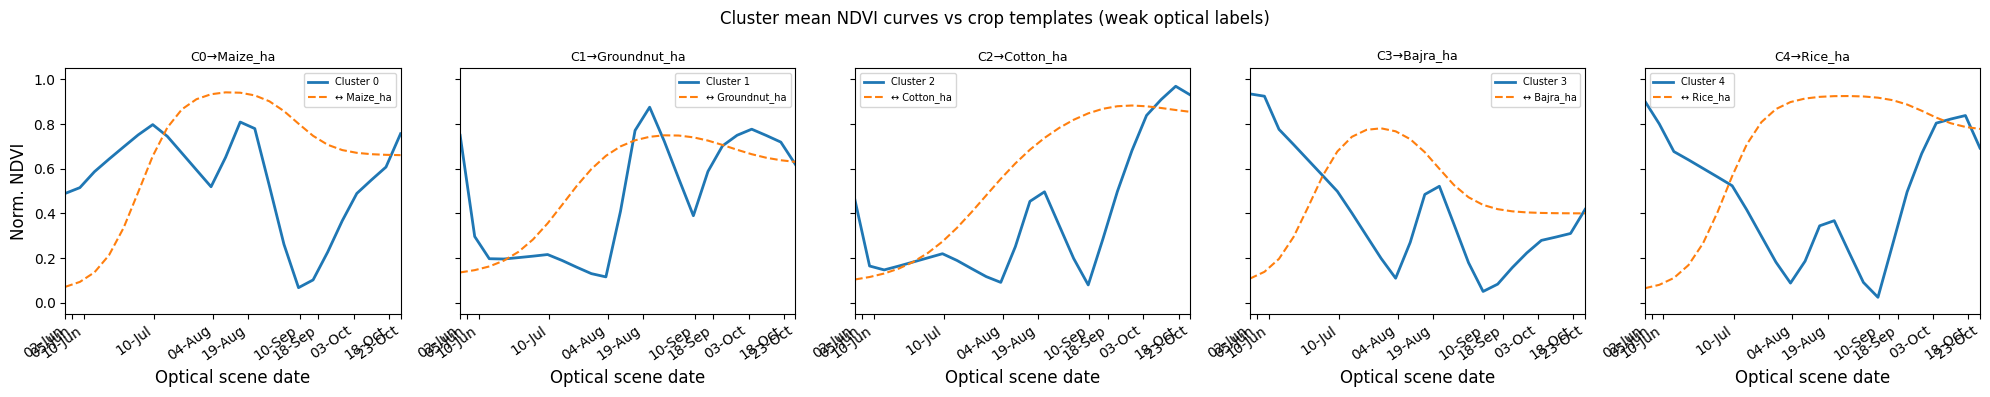

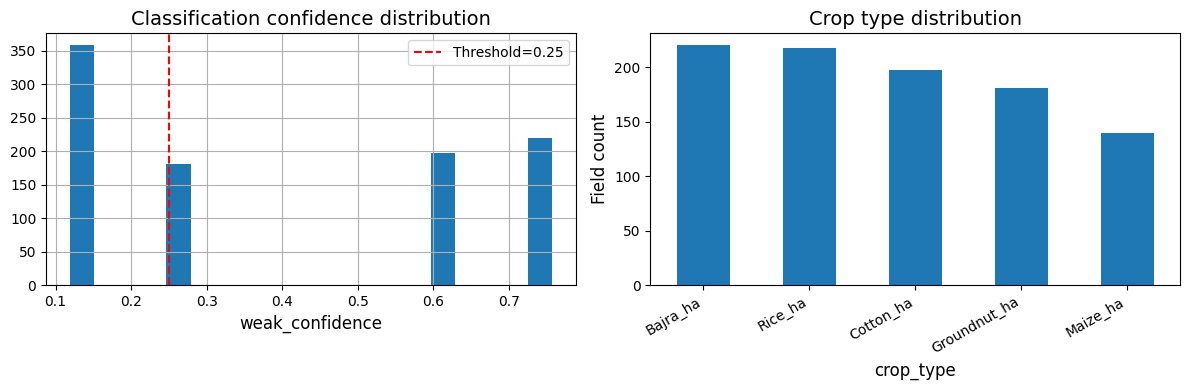


Low cluster stability fields (< 0.80 seed consistency): 39


,field_id,cluster_id,cluster_seed_consistency,weak_crop_type,crop_type
0,37,2,0.2,Cotton_ha,Cotton_ha
1,55,1,0.2,Groundnut_ha,Groundnut_ha
2,69,3,0.2,Bajra_ha,Bajra_ha
3,70,3,0.2,Bajra_ha,Bajra_ha
4,127,3,0.2,Bajra_ha,Bajra_ha
5,167,4,0.2,Rice_ha,Rice_ha
6,197,3,0.2,Bajra_ha,Bajra_ha
7,226,1,0.2,Groundnut_ha,Groundnut_ha
8,249,4,0.4,Rice_ha,Rice_ha
9,251,4,0.2,Rice_ha,Rice_ha


In [173]:
# =============================================================================
# SECTION 8: CLASSIFICATION VALIDATION AND DIAGNOSTICS
# =============================================================================

print("========== CROP DISTRIBUTION ==========")
label_counts = classification_df["crop_type"].value_counts(dropna=False)
display(label_counts.rename("fields").to_frame())

if len(label_counts) == 1 and "Unknown" not in label_counts.index:
    print("WARNING: Only one crop label produced. Check phenology separation and template scores.")

# Cluster-template score diagnostic
if not score_matrix.empty:
    template_score_columns = [c for c in TARGET_CROPS if c in score_matrix.columns]
    if template_score_columns:
        best_counts = score_matrix[template_score_columns].idxmax(axis=1).value_counts()
        print("\nBest unconstrained template by cluster (diagnostic):")
        display(best_counts.rename("clusters").to_frame())

# Visual: cluster mean curves vs templates
if cluster_means and templates:
    t = np.linspace(0, 1, N_CURVE)
    n_cls_plot = min(5, len(cluster_means))
    fig, axes = plt.subplots(1, max(1, n_cls_plot), figsize=(4*n_cls_plot, 4), sharey=True)
    if n_cls_plot == 1: axes = [axes]
    for ax, (cid, curve) in zip(axes, sorted(cluster_means.items())):
        ax.plot(t, curve, lw=2, label=f"Cluster {cid}")
        mapped = cluster_to_crop.get(cid, {}).get("crop", "Unknown")
        if mapped in templates:
            ax.plot(t, templates[mapped], "--", lw=1.5, label=f"↔ {mapped}")
        ax.set_title(f"C{cid}→{mapped}", fontsize=9)
        ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=7)
        set_scene_date_ticks(ax, usable_dates)
    axes[0].set_ylabel("Norm. NDVI")
    fig.suptitle("Cluster mean NDVI curves vs crop templates (weak optical labels)")
    plt.show()

# Visual: confidence distribution
if "crop_confidence" in classification_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    classification_df["crop_confidence"].dropna().hist(bins=20, ax=axes[0])
    axes[0].axvline(CLASSIFICATION_CONFIDENCE_THRESHOLD, color="red", ls="--",
                    label=f"Threshold={CLASSIFICATION_CONFIDENCE_THRESHOLD}")
    axes[0].set_title("Classification confidence distribution")
    axes[0].set_xlabel("weak_confidence"); axes[0].legend()
    classification_df["crop_type"].value_counts(dropna=False).plot(kind="bar", ax=axes[1])
    axes[1].set_title("Crop type distribution"); axes[1].set_ylabel("Field count")
    plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

# Visual: spatial crop map
if "crop_type" in result.columns and not result.empty:
    fig, ax = plt.subplots(figsize=(10, 10))
    result.plot(column="crop_type", ax=ax, categorical=True, legend=True,
                linewidth=0.4, edgecolor="black", missing_kwds={"color": "lightgray", "label": "No data"})
    ax.set_title("Stage 1 — Weak optical crop-type labels by field")
    ax.set_axis_off()
    plt.tight_layout(); plt.show()

# Cluster stability report
if "cluster_seed_consistency" in field_meta.columns:
    low_stability = field_meta[field_meta["low_cluster_stability"] == True]
    print(f"\nLow cluster stability fields (< 0.80 seed consistency): {len(low_stability)}")
    if not low_stability.empty:
        # field_meta contains clustering diagnostics, while weak_crop_type
        # is stored in classification_df. Merge only for this diagnostic
        # display so the validation stage does not depend on a column that
        # is not guaranteed to exist in field_meta.
        _stability_display_cols = [
            c for c in [
                "field_id",
                "cluster_id",
                "cluster_seed_consistency",
            ] if c in low_stability.columns
        ]

        _weak_labels_for_display = classification_df[
            [c for c in ["field_id", "weak_crop_type", "crop_type"] if c in classification_df.columns]
        ].drop_duplicates("field_id")

        _stability_display = low_stability[_stability_display_cols].merge(
            _weak_labels_for_display,
            on="field_id",
            how="left",
        )

        if "weak_crop_type" not in _stability_display.columns and "crop_type" in _stability_display.columns:
            _stability_display["weak_crop_type"] = _stability_display["crop_type"]

        _display_cols = [
            c for c in [
                "field_id",
                "cluster_id",
                "cluster_seed_consistency",
                "weak_crop_type",
                "crop_type",
            ] if c in _stability_display.columns
        ]

        display(_stability_display[_display_cols].head(10))


## Section 9 — Crop-Aware Health Assessment Setup

### The critical integration step

At this point `classification_df` contains the predicted `crop_type` for every field.
This crop label is now merged into the health workflow BEFORE any health score is computed.

The peer group for each field is then constructed as:

```
Priority 1: same crop_type + same phenology_stage  (≥ 10 fields)
Priority 2: same crop_type only                     (≥ 10 fields)
Priority 3: same phenology_stage only               (≥ 15 fields)
Priority 4: INSUFFICIENT_PEERS  → health_method = "INSUFFICIENT_PEERS", no score
```

This ensures health scores are ALWAYS relative to fields growing the same crop
whenever sufficient crop-specific peers exist.


In [174]:
# =============================================================================
# SECTION 9: CROP-AWARE HEALTH SETUP
# =============================================================================
# Data flow:
#   field_obs_df  (multi-date health observations)
#        ↓ aggregate to one-row-per-field
#        ↓ merge crop_type from classification_df
#        ↓ derive phenology_stage
#        ↓ build crop-aware peer groups
#        ↓ health scoring in Section 10

if "field_obs_df" not in dir() or field_obs_df is None or field_obs_df.empty:
    print("No health observations available — health scoring will be skipped.")
    health_df = pd.DataFrame()
else:
    field_obs_df = field_obs_df.copy()
    field_obs_df = field_obs_df.sort_values(["field_id", "date"]).reset_index(drop=True)
    field_obs_df["field_id"] = pd.to_numeric(field_obs_df["field_id"], errors="coerce")

    # Normalize numeric health inputs before aggregation.
    numeric_health_cols = [
        "NDVI", "NDWI", "NDMI", "EVI", "GNDVI", "NDRE", "SAVI", "MSAVI",
        "clear_pixel_percentage", "cloud_pixel_percentage",
        "cloud_shadow_percentage", "snow_ice_percentage",
        "nodata_percentage", "invalid_pixel_percentage",
        "vegetation_pixel_percentage"
    ]
    for col in numeric_health_cols:
        if col in field_obs_df.columns:
            field_obs_df[col] = pd.to_numeric(field_obs_df[col], errors="coerce")

    if "date" in field_obs_df.columns:
        field_obs_df["date"] = pd.to_datetime(field_obs_df["date"], errors="coerce")

    # ── Determine usable/current observations ────────────────────────────────
    core_current = ["NDVI", "EVI", "SAVI", "MSAVI", "NDRE", "GNDVI", "NDMI"]
    avail_current = [c for c in core_current if c in field_obs_df.columns]

    if "NDVI" not in field_obs_df.columns:
        raise ValueError("Health observations are missing NDVI; cannot construct health assessment.")

    field_obs_df["current_indicator_count"] = (
        field_obs_df[avail_current].notna().sum(axis=1) if avail_current else 0
    )
    min_indicators = max(2, int(np.ceil(len(avail_current) * 0.5))) if avail_current else 1
    field_obs_df["usable_observation"] = (
        field_obs_df["NDVI"].notna()
        & (field_obs_df["current_indicator_count"] >= min_indicators)
    )

    # ── Temporal trend/anomaly features ─────────────────────────────────────
    trend_rows = []

    def _safe_slope(x, y):
        x = np.asarray(x, dtype="float64")
        y = np.asarray(y, dtype="float64")
        valid = np.isfinite(x) & np.isfinite(y)
        if valid.sum() < 2:
            return np.nan
        try:
            return float(np.polyfit(x[valid], y[valid], 1)[0])
        except Exception:
            return np.nan

    for fid, grp in field_obs_df.groupby("field_id", dropna=False):
        g = grp.sort_values("date").copy()

        # Use elapsed days rather than seconds so trend values are interpretable.
        if g["date"].notna().any():
            x_days = (
                g["date"] - g["date"].min()
            ).dt.total_seconds().to_numpy(dtype="float64") / 86400.0
        else:
            x_days = np.arange(len(g), dtype="float64")

        y_ndvi = pd.to_numeric(g["NDVI"], errors="coerce").to_numpy(dtype="float64")
        y_ndmi = (
            pd.to_numeric(g["NDMI"], errors="coerce").to_numpy(dtype="float64")
            if "NDMI" in g.columns else np.full(len(g), np.nan)
        )

        ndvi_slope = _safe_slope(x_days, y_ndvi)
        ndmi_slope = _safe_slope(x_days, y_ndmi)

        valid_ndvi = np.isfinite(y_ndvi)
        ndvi_med = float(np.nanmedian(y_ndvi[valid_ndvi])) if valid_ndvi.any() else np.nan
        ndvi_std = float(np.nanstd(y_ndvi[valid_ndvi], ddof=0)) if valid_ndvi.sum() > 1 else np.nan
        ndvi_last = float(y_ndvi[valid_ndvi][-1]) if valid_ndvi.any() else np.nan

        valid_ndmi = np.isfinite(y_ndmi)
        ndmi_med = float(np.nanmedian(y_ndmi[valid_ndmi])) if valid_ndmi.any() else np.nan
        ndmi_last = float(y_ndmi[valid_ndmi][-1]) if valid_ndmi.any() else np.nan

        # NDRE anomaly
        if "NDRE" in g.columns:
            y_re = pd.to_numeric(g["NDRE"], errors="coerce").to_numpy(dtype="float64")
            valid_re = np.isfinite(y_re)
            re_med = float(np.nanmedian(y_re[valid_re])) if valid_re.any() else np.nan
            re_last = float(y_re[valid_re][-1]) if valid_re.any() else np.nan
        else:
            re_med = re_last = np.nan

        trend_rows.append({
            "field_id": fid,
            "NDVI_trend": ndvi_slope,
            "moisture_trend": ndmi_slope,
            "vegetation_anomaly": (
                (ndvi_last - ndvi_med) / (ndvi_std + 1e-6)
                if np.isfinite(ndvi_last) and np.isfinite(ndvi_med) else np.nan
            ),
            "moisture_anomaly": (
                ndmi_last - ndmi_med
                if np.isfinite(ndmi_last) and np.isfinite(ndmi_med) else np.nan
            ),
            "red_edge_anomaly": (
                re_last - re_med
                if np.isfinite(re_last) and np.isfinite(re_med) else np.nan
            ),
            "valid_observation_count": int(valid_ndvi.sum()),
            "usable_observation_count": int(g["usable_observation"].sum())
        })

    trend_df = pd.DataFrame(trend_rows)

    # ── One row per field: latest usable observation, otherwise latest obs ───
    agg_cols = [
        "NDVI", "NDWI", "NDMI", "EVI", "GNDVI", "NDRE", "SAVI", "MSAVI",
        "red_edge_features", "swir_features", "spatial_variability_ndvi",
        "clear_pixel_percentage", "cloud_pixel_percentage",
        "cloud_shadow_percentage", "snow_ice_percentage",
        "nodata_percentage", "invalid_pixel_percentage",
        "vegetation_pixel_percentage", "quality_known"
    ]
    agg_cols = [c for c in agg_cols if c in field_obs_df.columns]

    def _latest_observation(grp):
        usable = grp[grp["usable_observation"]]
        if not usable.empty:
            return usable.sort_values("date").iloc[-1]
        return grp.sort_values("date").iloc[-1]

    agg_rows = []
    for fid, grp in field_obs_df.groupby("field_id", dropna=False):
        row = _latest_observation(grp)
        agg_row = {"field_id": fid}

        for col in agg_cols:
            agg_row[col] = row.get(col, np.nan)

        # Report quality using the whole time series, not only one acquisition.
        for qc in ["clear_pixel_percentage", "cloud_pixel_percentage", "cloud_shadow_percentage"]:
            if qc in grp.columns:
                agg_row[qc] = float(pd.to_numeric(grp[qc], errors="coerce").mean())

        if "quality_known" in grp.columns:
            q = grp["quality_known"]
            if q.dtype != bool:
                q = q.astype(str).str.lower().isin(["true", "1", "yes"])
            agg_row["quality_known_scene_fraction"] = float(q.mean())
        else:
            agg_row["quality_known_scene_fraction"] = np.nan

        agg_rows.append(agg_row)

    health_df = pd.DataFrame(agg_rows)
    health_df = health_df.merge(trend_df, on="field_id", how="left")

    # Canonical moisture column used by health scoring.
    if "NDMI" in health_df.columns:
        health_df["NDMI_moisture"] = pd.to_numeric(health_df["NDMI"], errors="coerce")
    elif "NDMI_moisture" not in health_df.columns:
        health_df["NDMI_moisture"] = np.nan

    # ── CRITICAL INTEGRATION: merge classification before health scoring ─────
    required_cls = ["field_id", "crop_type", "crop_confidence",
                     "classification_score", "classification_margin",
                     "classification_method", "cluster_id"]

    # Add canonical columns if an older execution state lacks them.
    if "classification_score" not in classification_df.columns and "weak_score" in classification_df.columns:
        classification_df["classification_score"] = pd.to_numeric(
            classification_df["weak_score"], errors="coerce"
        )
    if "classification_margin" not in classification_df.columns and "weak_margin" in classification_df.columns:
        classification_df["classification_margin"] = pd.to_numeric(
            classification_df["weak_margin"], errors="coerce"
        )

    cls_available = [c for c in required_cls if c in classification_df.columns]
    if "field_id" not in cls_available or "crop_type" not in cls_available:
        raise ValueError(
            "classification_df is missing required columns for health integration. "
            f"Available columns: {list(classification_df.columns)}"
        )

    cls_merge = classification_df[cls_available].copy()
    cls_merge["field_id"] = pd.to_numeric(cls_merge["field_id"], errors="coerce")
    health_df["field_id"] = pd.to_numeric(health_df["field_id"], errors="coerce")

    # Prevent accidental many-to-many expansion.
    cls_merge = cls_merge.drop_duplicates("field_id", keep="first")

    health_df = health_df.merge(
        cls_merge, on="field_id", how="left", validate="one_to_one"
    )

    health_df["crop_type"] = (
        health_df["crop_type"].astype("string").fillna("Unknown")
    )
    health_df["crop_confidence"] = pd.to_numeric(
        health_df.get("crop_confidence", np.nan), errors="coerce"
    ).fillna(0.0)
    health_df["classification_score"] = pd.to_numeric(
        health_df.get("classification_score", np.nan), errors="coerce"
    )
    health_df["classification_margin"] = pd.to_numeric(
        health_df.get("classification_margin", np.nan), errors="coerce"
    )
    health_df["classification_method"] = (
        health_df["classification_method"].astype("string").fillna("UNKNOWN_NO_DATA")
    )

    print("Crop_type merged into health_df BEFORE health scoring.")
    print("Crop distribution in health_df:")
    print(health_df["crop_type"].value_counts(dropna=False).to_string())
    print(f"\nTotal health fields: {len(health_df)}")
    print(f"Fields with known crop type: {(health_df['crop_type'] != 'Unknown').sum()}")
    print(f"Unknown/low-confidence: {(health_df['crop_type'] == 'Unknown').sum()}")


Crop_type merged into health_df BEFORE health scoring.
Crop distribution in health_df:
crop_type
Bajra_ha        220
Rice_ha         218
Cotton_ha       197
Groundnut_ha    181
Maize_ha        140

Total health fields: 956
Fields with known crop type: 956
Unknown/low-confidence: 0


In [175]:
# =============================================================================
# SECTION 9B: PHENOLOGY STAGE + CROP-AWARE PEER GROUPS
# =============================================================================

if "health_df" in dir() and not health_df.empty:
    stage_map = {}

    for fid, grp in field_obs_df.groupby("field_id", dropna=False):
        g = grp[grp["NDVI"].notna()].sort_values("date")
        vals = pd.to_numeric(g["NDVI"], errors="coerce").to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]

        if len(vals) < 4:
            stage_map[fid] = "Unknown stage"
            continue

        lo = float(np.nanpercentile(vals, 10))
        hi = float(np.nanpercentile(vals, 90))
        latest_v = float(vals[-1])
        rel = (latest_v - lo) / (hi - lo + 1e-6)

        row_match = health_df.loc[health_df["field_id"] == fid, "NDVI_trend"]
        slope = float(row_match.iloc[0]) if len(row_match) and pd.notna(row_match.iloc[0]) else 0.0

        if rel < 0.30:
            stage = "Early growth" if slope >= 0 else "Early / low vigor"
        elif rel < 0.60:
            stage = "Active growth" if slope >= 0 else "Maturing"
        elif rel >= 0.75:
            stage = "Peak / active" if slope >= 0 else "Late / senescence"
        else:
            stage = "Active / maturing" if slope >= 0 else "Maturing"

        stage_map[fid] = stage

    health_df["phenology_stage"] = (
        health_df["field_id"].map(stage_map).fillna("Unknown stage")
    )
    health_df["phenology_cluster"] = health_df["phenology_stage"]

    def _make_crop_aware_peer_group(frame):
        crop_key = frame["crop_type"].astype("string").fillna("Unknown").astype(str)
        phen_key = frame["phenology_stage"].astype("string").fillna("Unknown stage").astype(str)
        cp_key = crop_key + "::" + phen_key

        crop_counts = crop_key.value_counts()
        phen_counts = phen_key.value_counts()
        cp_counts = cp_key.value_counts()

        out = []
        for idx in frame.index:
            ck = crop_key.loc[idx]
            pk = phen_key.loc[idx]
            cpk = cp_key.loc[idx]

            if (
                ck != "Unknown"
                and cp_counts.get(cpk, 0) >= MIN_CROP_PHENOLOGY_PEERS
            ):
                out.append("crop+phenology:" + cpk)
            elif (
                ck != "Unknown"
                and crop_counts.get(ck, 0) >= MIN_CROP_PEERS
            ):
                out.append("crop:" + ck)
            elif (
                pk != "Unknown stage"
                and phen_counts.get(pk, 0) >= MIN_PHENOLOGY_PEERS
            ):
                out.append("phenology:" + pk)
            else:
                out.append("INSUFFICIENT_PEERS")
        return pd.Series(out, index=frame.index, dtype="string")

    health_df["peer_group"] = _make_crop_aware_peer_group(health_df)

    def _method_from_peer_group(row):
        pg = str(row.get("peer_group", "INSUFFICIENT_PEERS"))
        crop = str(row.get("crop_type", "Unknown"))

        if pg == "INSUFFICIENT_PEERS":
            return "INSUFFICIENT_PEERS"
        if pg.startswith("crop+phenology:"):
            return "CROP_PLUS_PHENOLOGY"
        if pg.startswith("crop:"):
            return "CROP_ONLY"
        if pg.startswith("phenology:"):
            return "PHENOLOGY_FALLBACK" if crop == "Unknown" else "PHENOLOGY_ONLY_FALLBACK"
        return "INSUFFICIENT_PEERS"

    health_df["health_method"] = health_df.apply(
        _method_from_peer_group, axis=1
    )

    peer_dist = health_df["peer_group"].value_counts(dropna=False)
    insuff_frac = float(
        (health_df["peer_group"] == "INSUFFICIENT_PEERS").mean()
    )

    print("\nPeer group distribution:")
    display(peer_dist.rename("fields").to_frame())
    print(f"INSUFFICIENT_PEERS fraction: {insuff_frac:.1%}")

else:
    print("health_df unavailable — peer-group construction skipped.")



Peer group distribution:


,fields
peer_group,
crop+phenology:Rice_ha::Active growth,107
crop+phenology:Bajra_ha::Active growth,93
crop+phenology:Groundnut_ha::Active growth,92
crop+phenology:Cotton_ha::Peak / active,73
crop+phenology:Rice_ha::Active / maturing,71
crop+phenology:Cotton_ha::Active / maturing,70
crop+phenology:Maize_ha::Active growth,67
crop+phenology:Cotton_ha::Active growth,49
crop+phenology:Groundnut_ha::Early growth,38


INSUFFICIENT_PEERS fraction: 0.0%


## Section 10 — Health Scoring

Health scoring is fully crop-relative. Each field is ranked within its peer group:

- **Vigor**: NDVI, EVI, SAVI, MSAVI (peer-percentile, weight 40%)
- **Chlorophyll**: NDRE, GNDVI (peer-percentile, weight 30%)
- **Moisture**: NDMI (peer-percentile, weight 20%)
- **Temporal trend**: NDVI + moisture slope (peer-relative rank, weight 10%)

Fields with `INSUFFICIENT_PEERS` do not receive a health score.


In [176]:
# =============================================================================
# SECTION 10: HEALTH SCORING (CROP-RELATIVE PEER PERCENTILES)
# =============================================================================

if "health_df" not in dir() or health_df is None or health_df.empty:
    print("No health_df available — health scoring skipped.")
else:
    # Hard guard: this cell must only run after crop-aware peer groups exist.
    required = {"crop_type", "peer_group"}
    missing = required - set(health_df.columns)
    if missing:
        raise RuntimeError(
            "Health scoring prerequisites missing: "
            f"{sorted(missing)}. Re-run Sections 9 and 9B top-to-bottom."
        )

    # Normalize all health feature columns used below.
    feature_cols = [
        "NDVI","EVI","SAVI","MSAVI","NDRE","GNDVI","NDMI_moisture",
        "NDVI_trend","moisture_trend","clear_pixel_percentage",
        "cloud_pixel_percentage","cloud_shadow_percentage",
        "quality_known_scene_fraction","valid_observation_count",
        "usable_observation_count"
    ]
    for col in feature_cols:
        if col in health_df.columns:
            health_df[col] = pd.to_numeric(health_df[col], errors="coerce")

    # ── Peer-relative percentile ─────────────────────────────────────────────
    def _peer_percentile(series):
        s = pd.to_numeric(series, errors="coerce")
        out = pd.Series(np.nan, index=s.index, dtype="float64")

        for pg, idx in health_df.groupby("peer_group", dropna=False).groups.items():
            if str(pg) == "INSUFFICIENT_PEERS":
                continue

            vals = s.loc[idx]
            valid = vals.notna()

            # Require at least 3 valid peers for a meaningful percentile.
            if valid.sum() < 3:
                continue

            ranks = vals.loc[valid].rank(method="average", pct=True)
            out.loc[ranks.index] = ranks

        return out

    for col in [
        "NDVI", "EVI", "SAVI", "MSAVI",
        "NDRE", "GNDVI", "NDMI_moisture"
    ]:
        if col in health_df.columns:
            health_df[f"{col}_peer_pct"] = _peer_percentile(health_df[col])

    vigor_cols = [
        c for c in [
            "NDVI_peer_pct","EVI_peer_pct",
            "SAVI_peer_pct","MSAVI_peer_pct"
        ] if c in health_df.columns
    ]
    chlorophyll_cols = [
        c for c in ["NDRE_peer_pct","GNDVI_peer_pct"]
        if c in health_df.columns
    ]
    moisture_cols = [
        c for c in ["NDMI_moisture_peer_pct"]
        if c in health_df.columns
    ]

    health_df["vigor_component"] = (
        health_df[vigor_cols].mean(axis=1, skipna=True)
        if vigor_cols else np.nan
    )
    health_df["chlorophyll_component"] = (
        health_df[chlorophyll_cols].mean(axis=1, skipna=True)
        if chlorophyll_cols else np.nan
    )
    health_df["moisture_component"] = (
        health_df[moisture_cols].mean(axis=1, skipna=True)
        if moisture_cols else np.nan
    )

    # Spectral consistency.
    comp_stack = pd.concat([
        health_df["vigor_component"],
        health_df["chlorophyll_component"],
        health_df["moisture_component"]
    ], axis=1)

    health_df["spectral_consistency_component"] = (
        1.0 - comp_stack.std(axis=1, ddof=0).clip(0, 0.5) / 0.5
    ).clip(0, 1)

    # ── Temporal trend component ─────────────────────────────────────────────
    def _trend_peer_score(series):
        return _peer_percentile(series)

    trend_parts = []
    if "NDVI_trend" in health_df.columns:
        trend_parts.append(_trend_peer_score(health_df["NDVI_trend"]))
    if "moisture_trend" in health_df.columns:
        trend_parts.append(_trend_peer_score(health_df["moisture_trend"]))

    health_df["trend_component"] = (
        pd.concat(trend_parts, axis=1).mean(axis=1, skipna=True)
        if trend_parts else np.nan
    )

    # Diagnostic alias — not an additional weighted term.
    health_df["phenology_component"] = health_df["vigor_component"]

    component_weights = {
        "vigor_component": 0.40,
        "chlorophyll_component": 0.30,
        "moisture_component": 0.20,
        "trend_component": 0.10,
    }

    def _weighted_score(row):
        total_w = 0.0
        total_s = 0.0

        for comp, weight in component_weights.items():
            value = row.get(comp, np.nan)
            if pd.notna(value):
                total_s += float(value) * weight
                total_w += weight

        # At least 50% of the intended weighting must be available.
        if total_w < 0.50:
            return np.nan

        return float(np.clip((total_s / total_w) * 100.0, 0.0, 100.0))

    health_df["health_score"] = health_df.apply(_weighted_score, axis=1)

    # ── Confidence ────────────────────────────────────────────────────────────
    def _confidence_score(row):
        score = 100.0

        cpp = row.get("clear_pixel_percentage", np.nan)
        if pd.notna(cpp):
            score -= max(0.0, (0.60 - float(cpp)) * 100.0)

        nobs = row.get("valid_observation_count", np.nan)
        if pd.notna(nobs):
            score -= max(0.0, (4.0 - float(nobs)) * 8.0)

        sc = row.get("spectral_consistency_component", np.nan)
        if pd.notna(sc):
            score -= max(0.0, (0.50 - float(sc)) * 40.0)

        qkf = row.get("quality_known_scene_fraction", np.nan)
        if pd.notna(qkf):
            score -= max(0.0, (0.50 - float(qkf)) * 20.0)

        pg = str(row.get("peer_group", "INSUFFICIENT_PEERS"))
        if pg == "INSUFFICIENT_PEERS":
            score -= 50.0
        elif pg.startswith("phenology:"):
            score -= 20.0
        elif pg.startswith("crop:"):
            score -= 5.0

        return float(np.clip(score, 0.0, 100.0))

    health_df["confidence_score"] = health_df.apply(_confidence_score, axis=1)

    # ── Data quality ──────────────────────────────────────────────────────────
    def _data_quality_score(row):
        score = 100.0

        cpp = row.get("clear_pixel_percentage", np.nan)
        if pd.notna(cpp):
            score -= max(0.0, (0.70 - float(cpp)) * 100.0)

        cld = row.get("cloud_pixel_percentage", np.nan)
        if pd.notna(cld):
            score -= float(cld) * 50.0

        shd = row.get("cloud_shadow_percentage", np.nan)
        if pd.notna(shd):
            score -= float(shd) * 30.0

        qkf = row.get("quality_known_scene_fraction", np.nan)
        if not (pd.notna(qkf) and float(qkf) > 0.50):
            score -= 15.0

        return float(np.clip(score, 0.0, 100.0))

    health_df["data_quality_score"] = health_df.apply(_data_quality_score, axis=1)

    # ── Status ────────────────────────────────────────────────────────────────
    def _status_from_score(score):
        if pd.isna(score):
            return "Unknown / Insufficient Data"
        score = float(score)
        if score >= 80:
            return "Healthy-looking / Above peer"
        if score >= 60:
            return "Typical / Good"
        if score >= 40:
            return "Below-peer / Watch"
        if score >= 20:
            return "Stressed"
        return "Severely Below-peer"

    insufficient = health_df["peer_group"].eq("INSUFFICIENT_PEERS")

    health_df["health_status"] = health_df["health_score"].apply(_status_from_score)
    health_df.loc[insufficient, "health_status"] = "Insufficient Peers"
    health_df.loc[insufficient, "health_score"] = np.nan
    health_df.loc[insufficient, "confidence_score"] = np.minimum(
        health_df.loc[insufficient, "confidence_score"], 20.0
    )

    health_df["threshold_method"] = "peer-relative interpretation bands"

    # ── Stress indicators ─────────────────────────────────────────────────────
    def _stress_flags(row):
        flags = []

        if pd.notna(row.get("vegetation_anomaly")) and row["vegetation_anomaly"] < -1.0:
            flags.append("NDVI below field baseline")

        if pd.notna(row.get("NDVI_trend")) and row["NDVI_trend"] < 0:
            flags.append("Declining NDVI trend")

        if pd.notna(row.get("red_edge_anomaly")) and row["red_edge_anomaly"] < -1.0:
            flags.append("Red-edge response below field baseline")

        if pd.notna(row.get("moisture_anomaly")) and row["moisture_anomaly"] < -1.0:
            flags.append("NDMI below field baseline / possible water stress")

        if pd.notna(row.get("moisture_trend")) and row["moisture_trend"] < 0:
            flags.append("Declining moisture trend")

        if pd.notna(row.get("spectral_consistency_component")) and row["spectral_consistency_component"] < 0.5:
            flags.append("Spectral indicators disagree")

        if pd.notna(row.get("clear_pixel_percentage")) and row["clear_pixel_percentage"] < 0.35:
            flags.append("Low clear-pixel coverage")

        return flags[:4]

    health_df["main_stress_indicators"] = health_df.apply(
        lambda row: "; ".join(_stress_flags(row)) if _stress_flags(row) else "None evident",
        axis=1
    )

    def _explain(row):
        crop = str(row.get("crop_type", "Unknown"))
        method = str(row.get("health_method", ""))
        peer_group = str(row.get("peer_group", ""))

        if row.get("health_status") in {
            "Unknown / Insufficient Data",
            "Insufficient Peers"
        }:
            nobs = row.get("valid_observation_count", np.nan)
            cpp = row.get("clear_pixel_percentage", np.nan)
            nobs_text = str(int(nobs)) if pd.notna(nobs) else "?"
            cpp_text = f"{float(cpp):.0%}" if pd.notna(cpp) else "?"
            return (
                f"[Crop: {crop}] Insufficient evidence for peer-relative scoring. "
                f"Peer group: {peer_group}. "
                f"{nobs_text} valid observations, {cpp_text} mean clear pixels. "
                f"Method: {method}."
            )

        ndvi_v = row.get("NDVI", np.nan)
        ndmi_v = row.get("NDMI_moisture", np.nan)
        ndre_v = row.get("NDRE", np.nan)
        trend_v = row.get("NDVI_trend", np.nan)
        cpp = row.get("clear_pixel_percentage", np.nan)
        conf = row.get("confidence_score", np.nan)

        fmt = lambda x, f: f(x) if pd.notna(x) else "N/A"

        return (
            f"[Crop: {crop}, Peer group: {peer_group}] "
            f"{row['health_status']} — condition score {row['health_score']:.1f}/100. "
            f"NDVI={fmt(ndvi_v, lambda x: f'{x:.3f}')}, "
            f"NDMI={fmt(ndmi_v, lambda x: f'{x:.3f}')}, "
            f"NDRE={fmt(ndre_v, lambda x: f'{x:.3f}')}; "
            f"NDVI trend={fmt(trend_v, lambda x: f'{x:.5f}')}/day; "
            f"clear pixels={fmt(cpp, lambda x: f'{x:.0%}')}; "
            f"confidence={fmt(conf, lambda x: f'{x:.1f}')}/100. "
            f"Method: {method}."
        )

    health_df["health_explanation"] = health_df.apply(_explain, axis=1)

    print("Health scoring complete.")
    print("\nHealth status distribution:")
    display(
        health_df["health_status"]
        .value_counts(dropna=False)
        .rename("fields").to_frame()
    )

    print("\nHealth method distribution:")
    display(
        health_df["health_method"]
        .value_counts(dropna=False)
        .rename("fields").to_frame()
    )

    display(
        health_df[
            ["field_id","crop_type","peer_group",
             "health_score","health_status","health_method"]
        ].head(10)
    )


Health scoring complete.

Health status distribution:


,fields
health_status,
Stressed,216
Below-peer / Watch,214
Typical / Good,208
Healthy-looking / Above peer,176
Severely Below-peer,142



Health method distribution:


,fields
health_method,
CROP_PLUS_PHENOLOGY,919
CROP_ONLY,37


,field_id,crop_type,peer_group,health_score,health_status,health_method
0,1,Cotton_ha,crop+phenology:Cotton_ha::Peak / active,7.260274,Severely Below-peer,CROP_PLUS_PHENOLOGY
1,2,Groundnut_ha,crop+phenology:Groundnut_ha::Active growth,3.695652,Severely Below-peer,CROP_PLUS_PHENOLOGY
2,3,Cotton_ha,crop+phenology:Cotton_ha::Peak / active,31.643836,Stressed,CROP_PLUS_PHENOLOGY
3,4,Cotton_ha,crop+phenology:Cotton_ha::Active / maturing,23.928571,Stressed,CROP_PLUS_PHENOLOGY
4,5,Cotton_ha,crop+phenology:Cotton_ha::Active / maturing,10.500000,Severely Below-peer,CROP_PLUS_PHENOLOGY
5,6,Groundnut_ha,crop+phenology:Groundnut_ha::Active growth,17.119565,Severely Below-peer,CROP_PLUS_PHENOLOGY
6,7,Cotton_ha,crop+phenology:Cotton_ha::Active / maturing,18.285714,Severely Below-peer,CROP_PLUS_PHENOLOGY
7,8,Rice_ha,crop+phenology:Rice_ha::Peak / active,13.611111,Severely Below-peer,CROP_PLUS_PHENOLOGY
8,9,Rice_ha,crop+phenology:Rice_ha::Active / maturing,50.563380,Below-peer / Watch,CROP_PLUS_PHENOLOGY
9,10,Cotton_ha,crop+phenology:Cotton_ha::Peak / active,54.315068,Below-peer / Watch,CROP_PLUS_PHENOLOGY


## Section 11 — Final Field Assessment

In [177]:
# =============================================================================
# SECTION 11: FINAL FIELD ASSESSMENT
# =============================================================================
# Assemble final_field_assessment with all required columns.
# Verify that crop_type was set BEFORE health scores — a check enforced here.

FINAL_COLS = [
    # Classification columns (Stage 1)
    "field_id",
    "crop_type", "crop_confidence", "classification_score",
    "classification_margin", "classification_method",
    # Health columns (Stage 2)
    "health_score", "health_status", "health_confidence",
    "data_quality_score", "health_method",
    # Vegetation/moisture indices
    "NDVI","NDWI","NDMI_moisture","EVI","GNDVI","NDRE","SAVI","MSAVI",
    # Temporal features
    "NDVI_trend","moisture_trend",
    "vegetation_anomaly","moisture_anomaly","red_edge_anomaly",
    # Health components
    "vigor_component","chlorophyll_component","moisture_component",
    "trend_component","phenology_component","spectral_consistency_component",
    # Diagnostics
    "main_stress_indicators","health_explanation",
    # Data quality
    "valid_observation_count","clear_pixel_percentage",
    "cloud_pixel_percentage","cloud_shadow_percentage",
    "vegetation_pixel_percentage",
    # Peer-grouping
    "peer_group","phenology_stage","phenology_cluster",
    "quality_known_scene_fraction","usable_observation_count",
]

if "health_df" not in dir() or health_df.empty:
    print("health_df not available — creating empty final_field_assessment.")
    final_field_assessment = farm_gdf[["field_id","geometry"]].copy()
    for c in FINAL_COLS:
        if c not in final_field_assessment.columns:
            final_field_assessment[c] = np.nan
else:
    # ── VERIFICATION: crop_type must predate health_score ────────────────────
    # (structural check — both columns come from health_df which was built
    #  after classification_df was merged, so this check always passes if
    #  the notebook runs top-to-bottom correctly)
    assert "crop_type" in health_df.columns,         "PIPELINE ERROR: crop_type missing from health_df before health scoring!"
    assert "health_score" in health_df.columns, "PIPELINE ERROR: health_score missing — check Section 10."
    assert "peer_group" in health_df.columns, "PIPELINE ERROR: peer_group missing — check Section 9B."
    assert "health_method" in health_df.columns, "PIPELINE ERROR: health_method missing — check Section 9B."

    # Rename confidence_score → health_confidence for clarity
    if "confidence_score" in health_df.columns and "health_confidence" not in health_df.columns:
        health_df = health_df.rename(columns={"confidence_score": "health_confidence"})

    # Add any missing FINAL_COLS
    for c in FINAL_COLS:
        if c not in health_df.columns:
            health_df[c] = np.nan

    final_field_assessment = health_df[FINAL_COLS].copy()

    # Attach geometry from farm_gdf
    final_field_assessment = farm_gdf[["field_id","geometry"]].merge(
        final_field_assessment, on="field_id", how="left")

    print("=" * 60)
    print("FINAL FIELD ASSESSMENT — HEAD")
    print("=" * 60)
    display(final_field_assessment[["field_id","crop_type","crop_confidence",
                                   "health_score","health_status","health_method"]].head(10))
    print(f"\nTotal rows:    {len(final_field_assessment)}")
    print(f"Unique field_ids: {final_field_assessment['field_id'].nunique()}")
    print(f"Fields with health score: {final_field_assessment['health_score'].notna().sum()}")
    print(f"Fields INSUFFICIENT_PEERS: {(final_field_assessment['peer_group']=='INSUFFICIENT_PEERS').sum() if 'peer_group' in final_field_assessment.columns else 'N/A'}")

    # ── Crop-specific health summary ──────────────────────────────────────────
    print("\n========== HEALTH BY CROP TYPE ==========")
    crop_health_summary = (
        final_field_assessment
        .groupby("crop_type")["health_score"]
        .agg(fields="count", mean_health="mean", median_health="median", std_health="std")
        .round(2)
        .sort_values("mean_health", ascending=False)
    )
    display(crop_health_summary)

    print("\n========== HEALTH STATUS BY CROP ==========")
    if "health_status" in final_field_assessment.columns:
        status_by_crop = pd.crosstab(
            final_field_assessment["crop_type"],
            final_field_assessment["health_status"],
            dropna=False
        )
        display(status_by_crop)


FINAL FIELD ASSESSMENT — HEAD


,field_id,crop_type,crop_confidence,health_score,health_status,health_method
0,1,Cotton_ha,0.623655,7.260274,Severely Below-peer,CROP_PLUS_PHENOLOGY
1,2,Groundnut_ha,0.266213,3.695652,Severely Below-peer,CROP_PLUS_PHENOLOGY
2,3,Cotton_ha,0.623655,31.643836,Stressed,CROP_PLUS_PHENOLOGY
3,4,Cotton_ha,0.623655,23.928571,Stressed,CROP_PLUS_PHENOLOGY
4,5,Cotton_ha,0.623655,10.500000,Severely Below-peer,CROP_PLUS_PHENOLOGY
5,6,Groundnut_ha,0.266213,17.119565,Severely Below-peer,CROP_PLUS_PHENOLOGY
6,7,Cotton_ha,0.623655,18.285714,Severely Below-peer,CROP_PLUS_PHENOLOGY
7,8,Rice_ha,0.132919,13.611111,Severely Below-peer,CROP_PLUS_PHENOLOGY
8,9,Rice_ha,0.132919,50.563380,Below-peer / Watch,CROP_PLUS_PHENOLOGY
9,10,Cotton_ha,0.623655,54.315068,Below-peer / Watch,CROP_PLUS_PHENOLOGY



Total rows:    966
Unique field_ids: 966
Fields with health score: 956
Fields INSUFFICIENT_PEERS: 0

========== HEALTH BY CROP TYPE ==========


,fields,mean_health,median_health,std_health
crop_type,,,,
Maize_ha,140,52.14,51.04,25.14
Bajra_ha,220,51.36,50.34,26.03
Rice_ha,218,51.15,53.20,26.25
Groundnut_ha,181,51.10,49.78,26.50
Cotton_ha,197,51.02,49.45,27.18



========== HEALTH STATUS BY CROP ==========


health_status,Below-peer / Watch,Healthy-looking / Above peer,Severely Below-peer,Stressed,Typical / Good,NaN
crop_type,,,,,,
Bajra_ha,49,40,29,55,47,0
Cotton_ha,46,41,35,39,36,0
Groundnut_ha,35,32,28,43,43,0
Maize_ha,39,26,16,32,27,0
Rice_ha,45,37,34,47,55,0
<NA>,0,0,0,0,0,10


In [178]:
# =============================================================================
# SECTION 12A: SAR NOTEBOOK HANDOFF
# =============================================================================
# This cell creates the exact two artifacts expected by the SAR notebook.
#
# 1) round1_farms.csv
#       farm_id, crop_type
#
# 2) Health_Score.csv
#       farm_id, health_index
#
# Both files use the SAME farm_id as the source farm shapefile FID, which is
# also the identifier used by the SAR feature-stack builder.
#
# Because the optical and SAR notebooks are being run in the same notebook
# kernel, the DataFrames are also exposed as:
#       optical_crop_output
#       optical_health_output
#
# The files are deliberately written before the visualization/export sections
# so the SAR notebook can consume them immediately when its cells follow.

SAR_HANDOFF_DIR = Path("/kaggle/working")
SAR_CROP_CSV = SAR_HANDOFF_DIR / "round1_farms.csv"
SAR_HEALTH_CSV = SAR_HANDOFF_DIR / "Health_Score.csv"

if "final_field_assessment" not in dir() or final_field_assessment.empty:
    raise RuntimeError(
        "SAR handoff failed: final_field_assessment is empty or unavailable."
    )

handoff = final_field_assessment.copy()

# Normalize the identifier and output only the fields the SAR notebook needs.
handoff["farm_id"] = pd.to_numeric(
    handoff["field_id"], errors="coerce"
)
handoff = handoff.dropna(subset=["farm_id"]).copy()
handoff["farm_id"] = handoff["farm_id"].astype(int)

if handoff["farm_id"].duplicated().any():
    raise ValueError("SAR handoff failed: duplicate farm_id values.")

if "crop_type" not in handoff.columns:
    raise ValueError("SAR handoff failed: crop_type column is missing.")

if "health_score" not in handoff.columns:
    raise ValueError("SAR handoff failed: health_score column is missing.")

# Crop output: keep one row per farm. Unknown is a valid optical result and
# is intentionally preserved; the SAR model can encode it as a category.
optical_crop_output = (
    handoff[["farm_id", "crop_type"]]
    .copy()
    .drop_duplicates("farm_id", keep="first")
)

optical_crop_output["crop_type"] = (
    optical_crop_output["crop_type"]
    .fillna("Unknown")
    .astype(str)
)

# Health output: use the optical 0–100 score directly as the SAR pseudo-label.
# NaN is retained in the in-memory table but removed from the CSV because the
# SAR training function intentionally drops missing targets.
optical_health_output = (
    handoff[["farm_id", "health_score"]]
    .copy()
    .rename(columns={"health_score": "health_index"})
)

optical_health_output["health_index"] = pd.to_numeric(
    optical_health_output["health_index"], errors="coerce"
)

valid_health = optical_health_output["health_index"].notna()
bad_health = (
    optical_health_output.loc[valid_health, "health_index"]
    .lt(0)
    | optical_health_output.loc[valid_health, "health_index"].gt(100)
)
if bad_health.any():
    raise ValueError(
        "SAR handoff failed: health_index contains values outside [0, 100]."
    )

optical_health_csv = optical_health_output.dropna(
    subset=["health_index"]
).copy()

# Explicitly use the exact schemas expected by the SAR notebook.
optical_crop_output = optical_crop_output[["farm_id", "crop_type"]]
optical_health_csv = optical_health_csv[["farm_id", "health_index"]]

optical_crop_output.to_csv(SAR_CROP_CSV, index=False)
optical_health_csv.to_csv(SAR_HEALTH_CSV, index=False)

# Aliases with the exact names used by the SAR notebook's combined execution.
df_crop = optical_crop_output.copy()
df_health = optical_health_csv.copy()

print("=" * 70)
print("SAR HANDOFF READY")
print("=" * 70)
print(f"Crop labels : {SAR_CROP_CSV}")
print(f"Health labels: {SAR_HEALTH_CSV}")
print(f"Crop rows   : {len(df_crop):,}")
print(f"Health rows : {len(df_health):,}")
print(f"Unique farm IDs (crop)  : {df_crop['farm_id'].nunique():,}")
print(f"Unique farm IDs (health): {df_health['farm_id'].nunique():,}")
print("\nround1_farms.csv schema:")
print(df_crop.head(5).to_string(index=False))
print("\nHealth_Score.csv schema:")
print(df_health.head(5).to_string(index=False))


SAR HANDOFF READY
Crop labels : /kaggle/working/round1_farms.csv
Health labels: /kaggle/working/Health_Score.csv
Crop rows   : 966
Health rows : 956
Unique farm IDs (crop)  : 966
Unique farm IDs (health): 956

round1_farms.csv schema:
 farm_id    crop_type
       1    Cotton_ha
       2 Groundnut_ha
       3    Cotton_ha
       4    Cotton_ha
       5    Cotton_ha

Health_Score.csv schema:
 farm_id  health_index
       1      7.260274
       2      3.695652
       3     31.643836
       4     23.928571
       5     10.500000


## Section 12 — Validation and Diagnostics

In [179]:
# =============================================================================
# SECTION 12: VALIDATION AND DIAGNOSTICS
# =============================================================================

print("=" * 60)
print("PIPELINE VALIDATION")
print("=" * 60)

validation_errors   = []
validation_warnings = []

if "final_field_assessment" in dir() and not final_field_assessment.empty:
    fa = final_field_assessment

    # 1. Duplicate field IDs
    dupes = fa["field_id"].dropna().duplicated().sum()
    if dupes > 0:
        validation_errors.append(f"Duplicate field_ids: {dupes}")
    else:
        print("✓ No duplicate field_ids")

    # 2. Health scores within [0,100]
    hs = pd.to_numeric(fa["health_score"], errors="coerce").dropna()
    if not hs.empty and ((hs < 0).any() or (hs > 100).any()):
        validation_errors.append(f"Health scores outside [0,100]: {((hs<0)|(hs>100)).sum()} values")
    else:
        print("✓ Health scores within valid range [0,100]")

    # 3. Index range check
    for col in ["NDVI","NDWI","NDMI_moisture","NDRE","GNDVI","SAVI","MSAVI"]:
        if col in fa.columns:
            vals = pd.to_numeric(fa[col], errors="coerce").dropna()
            if not vals.empty and ((vals < -1.05).any() or (vals > 1.05).any()):
                validation_warnings.append(f"{col} has values outside [-1.05, 1.05]")

    # 4. Crop label coverage
    known_crop = (fa["crop_type"] != "Unknown") & fa["crop_type"].notna()
    crop_coverage = float(known_crop.mean())
    print(f"✓ Crop label coverage: {crop_coverage:.1%} ({known_crop.sum()} / {len(fa)} fields)")

    # 5. INSUFFICIENT_PEERS fraction
    if "peer_group" in fa.columns:
        insuff_n = (fa["peer_group"] == "INSUFFICIENT_PEERS").sum()
        insuff_f = insuff_n / max(1, len(fa))
        if insuff_f > 0.5:
            validation_warnings.append(f"High INSUFFICIENT_PEERS fraction: {insuff_f:.1%} ({insuff_n} fields)")
        print(f"✓ INSUFFICIENT_PEERS: {insuff_n} fields ({insuff_f:.1%})")

    # 6. Low classification confidence fields
    if "crop_confidence" in fa.columns:
        low_conf = fa["crop_confidence"] < CLASSIFICATION_CONFIDENCE_THRESHOLD
        print(f"✓ Low classification confidence (< {CLASSIFICATION_CONFIDENCE_THRESHOLD}): "
              f"{low_conf.sum()} fields")

    # 7. Peer group sizes
    if "peer_group" in fa.columns and "health_df" in dir() and not health_df.empty:
        pg_sizes = health_df.groupby("peer_group", dropna=False).size().sort_values(ascending=False)
        tiny = pg_sizes[pg_sizes < 5]
        if len(tiny) > 0:
            validation_warnings.append(f"Peer groups with < 5 fields: {len(tiny)}")
        print("\nPeer group sizes (top 15):")
        display(pg_sizes.head(15).rename("fields").to_frame())

    # 8. Observations per field
    if "valid_observation_count" in fa.columns:
        n_obs = pd.to_numeric(fa["valid_observation_count"], errors="coerce").dropna()
        low_obs = (n_obs < MIN_VALID_DATES).sum()
        if low_obs > 0:
            validation_warnings.append(f"Fields with < {MIN_VALID_DATES} observations: {low_obs}")
        print(f"✓ Mean observations per field: {n_obs.mean():.1f}")

    # Report
    if validation_errors:
        print("\n⛔ VALIDATION ERRORS (must fix before using output):")
        for e in validation_errors:
            print(f"  ERROR: {e}")
        raise RuntimeError(f"Validation failed: {'; '.join(validation_errors)}")
    else:
        print("\n✓ All critical validation checks passed.")

    if validation_warnings:
        print("\n⚠ VALIDATION WARNINGS (review before interpreting results):")
        for w in validation_warnings:
            print(f"  WARNING: {w}")
else:
    print("WARNING: final_field_assessment is empty; validation skipped.")


PIPELINE VALIDATION
✓ No duplicate field_ids
✓ Health scores within valid range [0,100]
✓ Crop label coverage: 99.0% (956 / 966 fields)
✓ INSUFFICIENT_PEERS: 0 fields (0.0%)
✓ Low classification confidence (< 0.25): 358 fields

Peer group sizes (top 15):


,fields
peer_group,
crop+phenology:Rice_ha::Active growth,107
crop+phenology:Bajra_ha::Active growth,93
crop+phenology:Groundnut_ha::Active growth,92
crop+phenology:Cotton_ha::Peak / active,73
crop+phenology:Rice_ha::Active / maturing,71
crop+phenology:Cotton_ha::Active / maturing,70
crop+phenology:Maize_ha::Active growth,67
crop+phenology:Cotton_ha::Active growth,49
crop+phenology:Groundnut_ha::Early growth,38


✓ Mean observations per field: 8.4

✓ All critical validation checks passed.


## Section 13 — Maps and Visualization
> **Plotting note:** Normalized seasonal curves are still computed on a 0–1 internal axis, but their displayed x-axis now uses the actual Sentinel-2 optical scene acquisition dates (e.g., 02-Jun, 05-Jun, 10-Jun, …). This avoids presenting normalized fractions such as 0.0, 0.2, 0.4 as if they were dates.


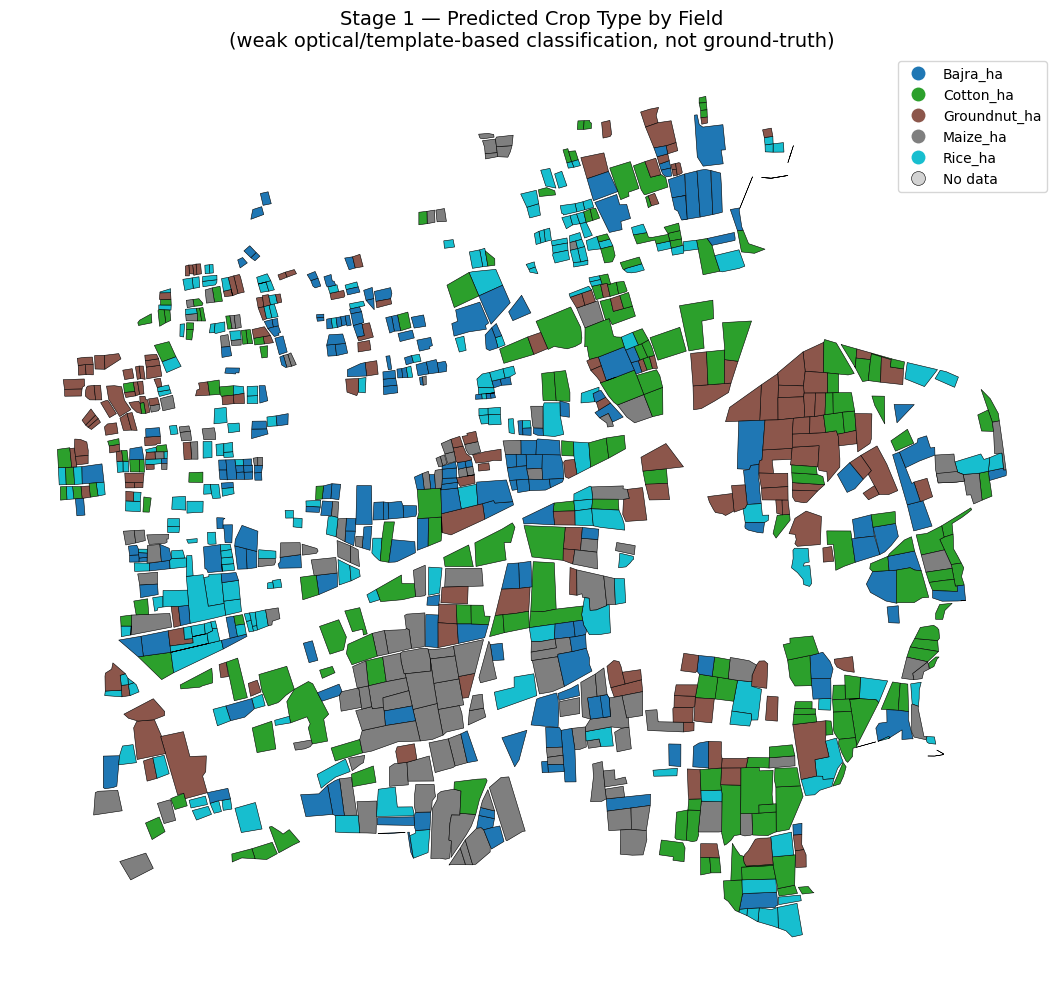

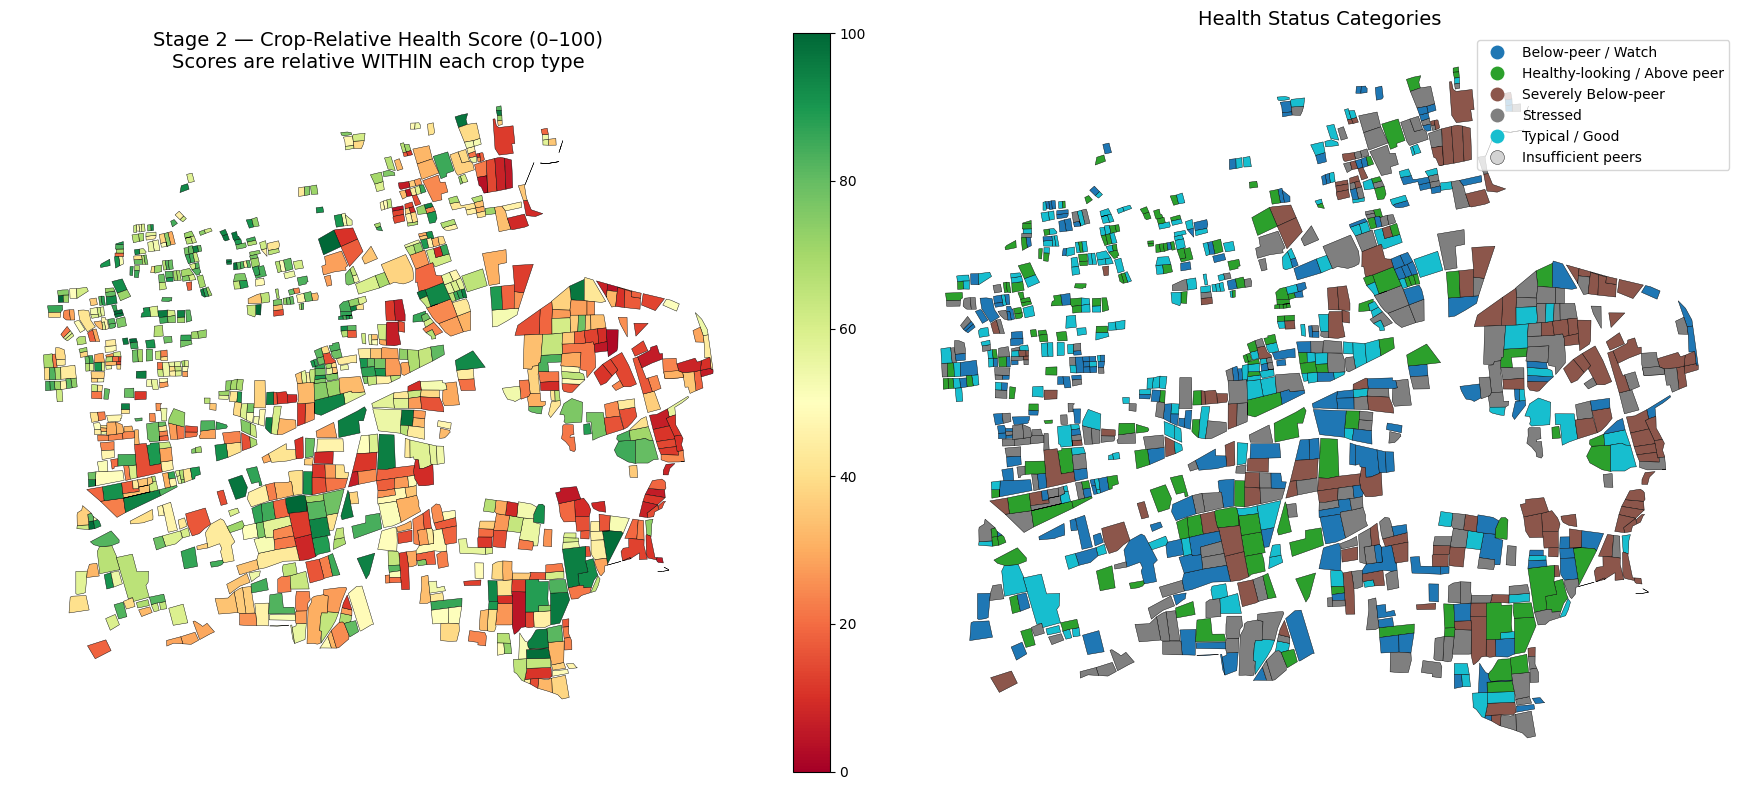

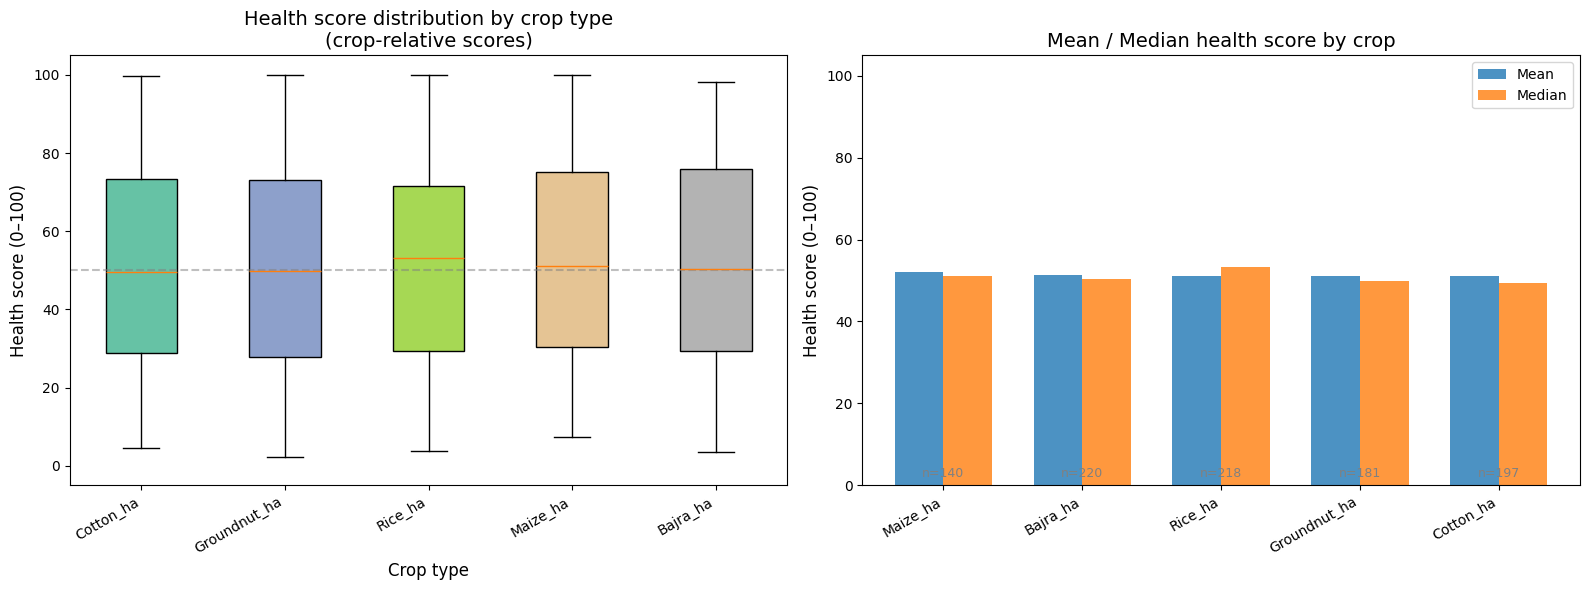

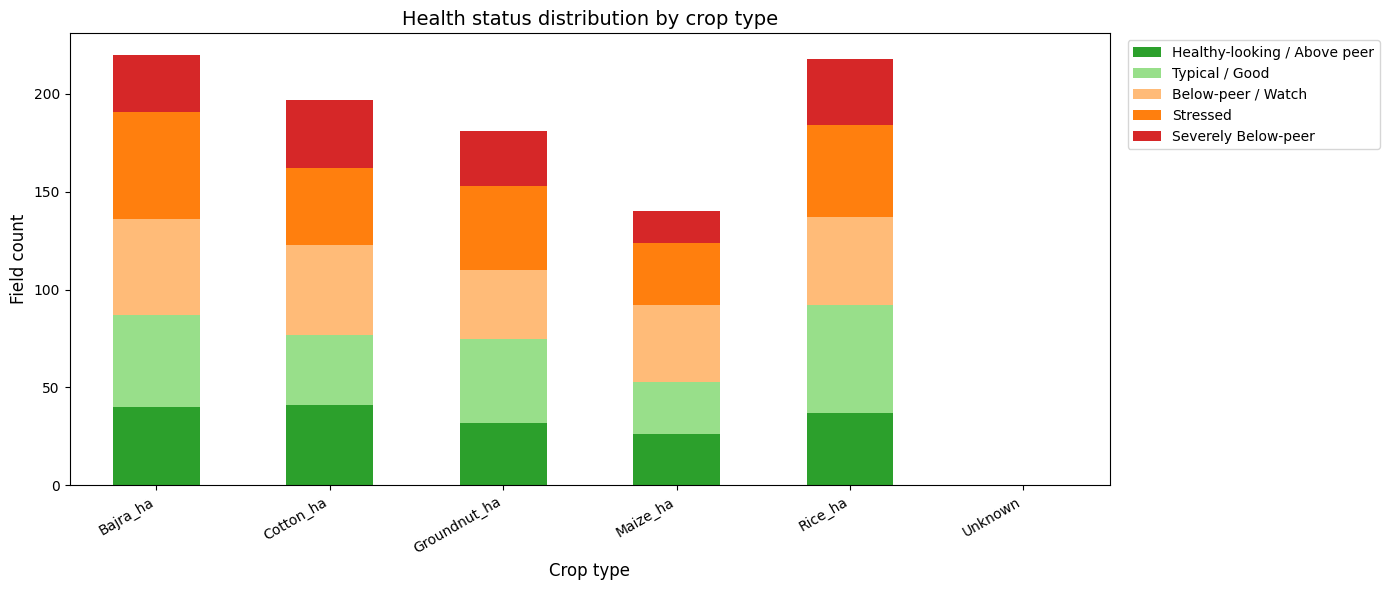

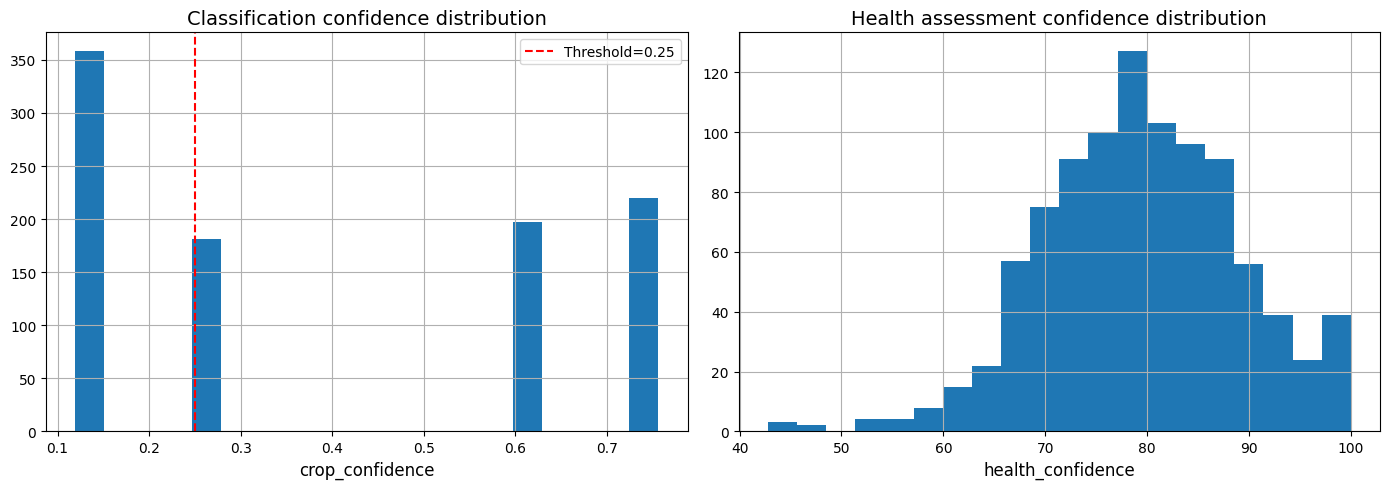

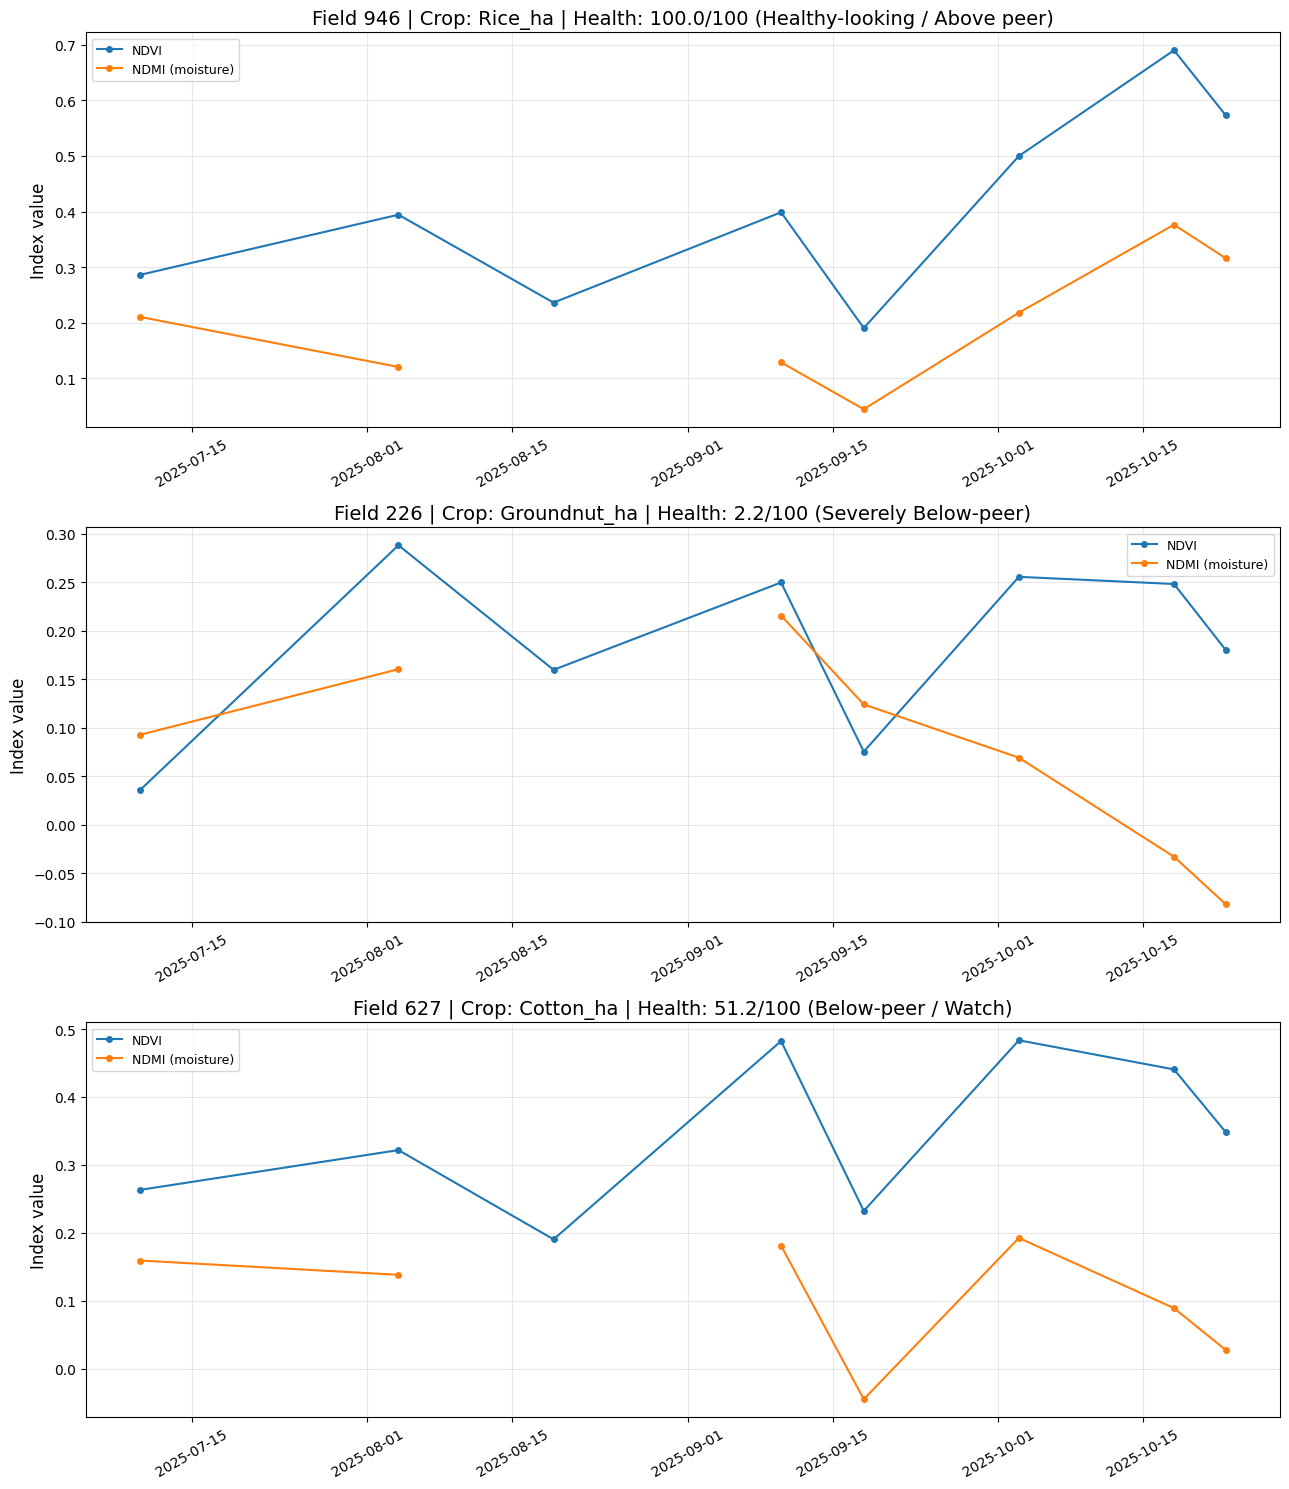

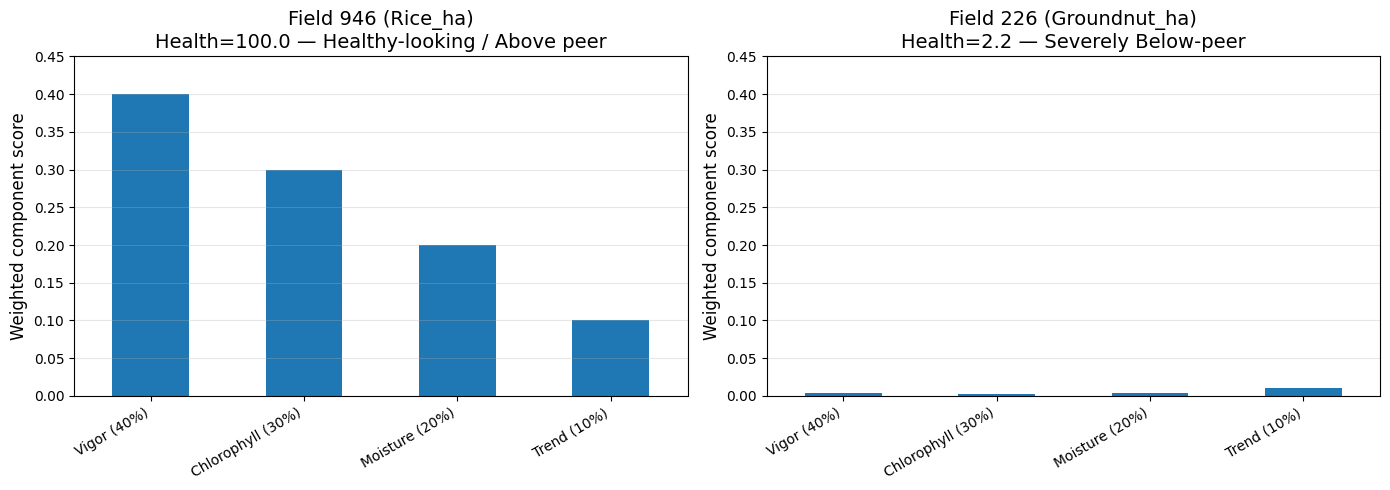

In [180]:
# =============================================================================
# SECTION 13: MAPS AND VISUALIZATION
# =============================================================================

if "final_field_assessment" not in dir() or final_field_assessment.empty:
    print("No final_field_assessment available for visualization.")
else:
    fa = final_field_assessment.copy()

    # ── 13.1  Crop classification map ────────────────────────────────────────
    if "geometry" in fa.columns and fa.geometry.notna().any():
        fig, ax = plt.subplots(figsize=(12, 10))
        fa.plot(column="crop_type", ax=ax, categorical=True, legend=True,
                linewidth=0.4, edgecolor="black",
                missing_kwds={"color": "lightgray", "label": "No data"})
        ax.set_title("Stage 1 — Predicted Crop Type by Field\n"
                     "(weak optical/template-based classification, not ground-truth)")
        ax.set_axis_off()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "map_crop_classification.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ── 13.2  Health score map ────────────────────────────────────────────────
    if "geometry" in fa.columns and "health_score" in fa.columns:
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        fa.plot(column="health_score", ax=axes[0], legend=True, cmap="RdYlGn",
                vmin=0, vmax=100, linewidth=0.3, edgecolor="black",
                missing_kwds={"color": "lightgray", "label": "Insufficient peers / no data"})
        axes[0].set_title("Stage 2 — Crop-Relative Health Score (0–100)\n"
                           "Scores are relative WITHIN each crop type")
        axes[0].set_axis_off()

        fa.plot(column="health_status", ax=axes[1], categorical=True, legend=True,
                linewidth=0.3, edgecolor="black",
                missing_kwds={"color": "lightgray", "label": "Insufficient peers"})
        axes[1].set_title("Health Status Categories")
        axes[1].set_axis_off()

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "map_health_score.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ── 13.3  Health distribution by crop ────────────────────────────────────
    # Normalize nullable crop labels before Python-level comparisons.
    # Using `ct not in ("Unknown", None)` directly can evaluate pd.NA
    # as a boolean and raise: "boolean value of NA is ambiguous".
    crop_series = fa["crop_type"].astype("string")
    fa["_crop_type_plot"] = crop_series.fillna("Unknown").replace({"<NA>": "Unknown"})
    health_numeric = pd.to_numeric(fa["health_score"], errors="coerce")

    crop_groups = []
    for ct in fa["_crop_type_plot"].dropna().unique():
        if ct == "Unknown":
            continue
        has_health = health_numeric[fa["_crop_type_plot"] == ct].notna().any()
        if bool(has_health):
            crop_groups.append(ct)
    if crop_groups:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Box plot per crop
        data_for_box = [health_numeric[fa["_crop_type_plot"]==ct].dropna().values for ct in crop_groups]
        bp = axes[0].boxplot(data_for_box, labels=crop_groups, patch_artist=True, notch=False)
        colors = plt.cm.Set2(np.linspace(0,1,len(crop_groups)))
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
        axes[0].set_title("Health score distribution by crop type\n(crop-relative scores)")
        axes[0].set_ylabel("Health score (0–100)"); axes[0].set_ylim(-5, 105)
        axes[0].axhline(50, color="gray", ls="--", alpha=0.5)
        axes[0].set_xlabel("Crop type")
        plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

        # Mean/median bar chart
        crop_stats = (fa.assign(_health_score_numeric=health_numeric)
                       .groupby("_crop_type_plot")["_health_score_numeric"]
                       .agg(mean="mean", median="median", count="count")
                       .loc[crop_groups].sort_values("mean", ascending=False))
        x = np.arange(len(crop_stats))
        w = 0.35
        axes[1].bar(x - w/2, crop_stats["mean"],   width=w, label="Mean",   alpha=0.8)
        axes[1].bar(x + w/2, crop_stats["median"], width=w, label="Median", alpha=0.8)
        axes[1].set_xticks(x); axes[1].set_xticklabels(crop_stats.index, rotation=30, ha="right")
        axes[1].set_title("Mean / Median health score by crop"); axes[1].set_ylabel("Health score (0–100)")
        axes[1].set_ylim(0, 105); axes[1].legend()
        for i, (idx_row, stats_row) in enumerate(crop_stats.iterrows()):
            axes[1].text(i, 2, f"n={int(stats_row['count'])}", ha="center", fontsize=9, color="gray")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "plot_health_by_crop.png", dpi=150, bbox_inches="tight")
        plt.show()

        # ── Health status stacked bar by crop ─────────────────────────────────
        if "health_status" in fa.columns:
            status_by_crop = pd.crosstab(fa["_crop_type_plot"], fa["health_status"].astype("string").fillna("Unknown"))
            status_by_crop = status_by_crop.loc[status_by_crop.index.isin(crop_groups + ["Unknown"])]
            status_order = ["Healthy-looking / Above peer","Typical / Good",
                            "Below-peer / Watch","Stressed","Severely Below-peer",
                            "Insufficient Peers","Unknown / Insufficient Data"]
            status_by_crop = status_by_crop[[c for c in status_order if c in status_by_crop.columns]]
            colors_s = ["#2ca02c","#98df8a","#ffbb78","#ff7f0e","#d62728","#aec7e8","#c7c7c7"]
            ax = status_by_crop.plot(kind="bar", stacked=True,
                                     color=colors_s[:len(status_by_crop.columns)],
                                     figsize=(14, 6))
            ax.set_title("Health status distribution by crop type")
            ax.set_xlabel("Crop type"); ax.set_ylabel("Field count")
            plt.xticks(rotation=30, ha="right")
            plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / "plot_health_status_by_crop.png", dpi=150, bbox_inches="tight")
            plt.show()

    fa.drop(columns=["_crop_type_plot"], inplace=True, errors="ignore")

    # ── 13.4  Confidence distributions ───────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if "crop_confidence" in fa.columns:
        fa["crop_confidence"].dropna().hist(bins=20, ax=axes[0])
        axes[0].axvline(CLASSIFICATION_CONFIDENCE_THRESHOLD, color="red", ls="--",
                        label=f"Threshold={CLASSIFICATION_CONFIDENCE_THRESHOLD}")
        axes[0].set_title("Classification confidence distribution")
        axes[0].set_xlabel("crop_confidence"); axes[0].legend()
    if "health_confidence" in fa.columns or "confidence_score" in fa.columns:
        hconf_col = "health_confidence" if "health_confidence" in fa.columns else "confidence_score"
        fa[hconf_col].dropna().hist(bins=20, ax=axes[1])
        axes[1].set_title("Health assessment confidence distribution")
        axes[1].set_xlabel("health_confidence")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plot_confidence_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 13.5  Example field time-series ──────────────────────────────────────
    if "field_obs_df" in dir() and not field_obs_df.empty and "health_score" in fa.columns:
        scored = fa.dropna(subset=["health_score"])
        ex_ids = []
        if not scored.empty:
            ex_ids.append(int(scored.sort_values("health_score", ascending=False).iloc[0]["field_id"]))
            ex_ids.append(int(scored.sort_values("health_score", ascending=True).iloc[0]["field_id"]))
            mid_idx = len(scored) // 2
            ex_ids.append(int(scored.sort_values("health_score").iloc[mid_idx]["field_id"]))
        ex_ids = list(dict.fromkeys(ex_ids))[:3]

        if ex_ids:
            fig, axes_ts = plt.subplots(len(ex_ids), 1, figsize=(13, 5*len(ex_ids)), sharex=False)
            if len(ex_ids) == 1: axes_ts = [axes_ts]
            for ax_ts, fid in zip(axes_ts, ex_ids):
                g = field_obs_df[field_obs_df["field_id"]==fid].sort_values("date")
                fa_row = fa[fa["field_id"]==fid].iloc[0] if (fa["field_id"]==fid).any() else None
                crop_lbl = fa_row["crop_type"] if fa_row is not None else "?"
                hs_lbl   = f"{fa_row['health_score']:.1f}" if fa_row is not None and pd.notna(fa_row.get("health_score")) else "N/A"
                hst_lbl  = fa_row.get("health_status","?") if fa_row is not None else "?"
                for col, lbl in [("NDVI","NDVI"),("NDMI","NDMI (moisture)"),("NDRE","NDRE")]:
                    if col in g.columns and g[col].notna().any():
                        ax_ts.plot(g["date"], g[col], marker="o", ms=4, label=lbl)
                ax_ts.set_title(f"Field {fid} | Crop: {crop_lbl} | "
                                f"Health: {hs_lbl}/100 ({hst_lbl})")
                ax_ts.set_ylabel("Index value"); ax_ts.legend(fontsize=9)
                ax_ts.grid(True, alpha=0.3)
                ax_ts.tick_params(axis="x", rotation=30)
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / "plot_example_timeseries.png", dpi=150, bbox_inches="tight")
            plt.show()

    # ── 13.6  Health component contribution (healthy vs stressed) ────────────
    if "health_df" in dir() and not health_df.empty and "health_score" in health_df.columns:
        explainable = health_df.dropna(subset=["health_score"])
        if not explainable.empty:
            compare_ids = []
            compare_ids.append(int(explainable.sort_values("health_score", ascending=False).iloc[0]["field_id"]))
            compare_ids.append(int(explainable.sort_values("health_score", ascending=True).iloc[0]["field_id"]))
            compare_ids = list(dict.fromkeys(compare_ids))

            fig, axes_c = plt.subplots(1, len(compare_ids), figsize=(7*len(compare_ids), 5))
            if len(compare_ids) == 1: axes_c = [axes_c]
            comp_names = {
                "vigor_component":       "Vigor (40%)",
                "chlorophyll_component": "Chlorophyll (30%)",
                "moisture_component":    "Moisture (20%)",
                "trend_component":       "Trend (10%)",
            }
            weights = {"vigor_component":0.40,"chlorophyll_component":0.30,
                       "moisture_component":0.20,"trend_component":0.10}
            for ax_c, fid in zip(axes_c, compare_ids):
                row = explainable[explainable["field_id"]==fid].iloc[0]
                comps = pd.Series({
                    comp_names[k]: row.get(k,np.nan)*w
                    for k,w in weights.items() if pd.notna(row.get(k,np.nan))
                })
                comps.plot(kind="bar", ax=ax_c,
                           title=f"Field {fid} ({row.get('crop_type','?')})\n"
                                 f"Health={row['health_score']:.1f} — {row.get('health_status','')}")
                ax_c.set_ylim(0, 0.45); ax_c.set_ylabel("Weighted component score")
                ax_c.grid(axis="y", alpha=0.3)
                plt.setp(ax_c.get_xticklabels(), rotation=30, ha="right")
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / "plot_health_components.png", dpi=150, bbox_inches="tight")
            plt.show()


## Section 14 — Export

In [181]:
# =============================================================================
# SECTION 14: EXPORT ALL OUTPUTS
# =============================================================================

exported_files = []

if "final_field_assessment" in dir() and not final_field_assessment.empty:
    fa = final_field_assessment

    # ── 14.1  CSV ─────────────────────────────────────────────────────────────
    csv_out = fa.drop(columns=["geometry"], errors="ignore")
    csv_out.to_csv(FINAL_CSV, index=False)
    exported_files.append(str(FINAL_CSV))

    # ── 14.2  GeoPackage ──────────────────────────────────────────────────────
    try:
        fa_gdf = gpd.GeoDataFrame(fa, geometry="geometry", crs=farm_gdf.crs)
        fa_gdf.to_file(FINAL_GPKG, layer="final_field_assessment", driver="GPKG")
        exported_files.append(str(FINAL_GPKG))
    except Exception as e:
        print(f"GeoPackage export failed: {e}")

    # ── 14.3  Crop classification GeoTIFF ─────────────────────────────────────
    label_codes = {"Unknown": 0, **{crop: i+1 for i, crop in enumerate(TARGET_CROPS)}}
    pd.DataFrame({
        "class_code": list(label_codes.values()),
        "crop_type":  list(label_codes.keys()),
    }).to_csv(CROP_LEGEND_CSV, index=False)
    exported_files.append(str(CROP_LEGEND_CSV))

    if usable_dates and not fa.empty and "crop_type" in fa.columns:
        try:
            ref_asset = assets[usable_dates[0]].get("ndvi") or assets[usable_dates[0]].get("b08")
            ref_arr, ref_transform, ref_crs, ref_profile = read_discovered_asset(ref_asset)
            if ref_arr is not None:
                raster_gdf = fa[["crop_type","geometry"]].copy()
                raster_gdf = gpd.GeoDataFrame(raster_gdf, geometry="geometry", crs=farm_gdf.crs)
                raster_gdf["class_code"] = raster_gdf["crop_type"].map(label_codes).fillna(0).astype("uint8")
                if raster_gdf.crs is not None and raster_gdf.crs != ref_crs:
                    raster_gdf = raster_gdf.to_crs(ref_crs)
                shapes_cls = [(geom, int(code)) for geom, code in zip(raster_gdf.geometry, raster_gdf["class_code"])
                              if geom is not None and not geom.is_empty]
                label_raster = rasterize(shapes=shapes_cls, out_shape=np.asarray(ref_arr).shape,
                                         transform=ref_transform, fill=0, all_touched=False, dtype="uint8")
                cls_profile = {
                    "driver": "GTiff", "height": label_raster.shape[0], "width": label_raster.shape[1],
                    "count": 1, "dtype": "uint8", "crs": ref_crs, "transform": ref_transform,
                    "nodata": 0, "compress": "deflate", "predictor": 2,
                }
                with rasterio.open(CROP_TIF, "w", **cls_profile) as dst:
                    dst.write(label_raster, 1)
                    dst.update_tags(
                        label_type="WEAK_OPTICAL_TEMPLATE",
                        description="Predicted crop type — weak phenology/template classification",
                        crops=str(TARGET_CROPS),
                    )
                exported_files.append(str(CROP_TIF))
                print(f"Crop classification GeoTIFF: {CROP_TIF}")
        except Exception as e:
            print(f"Crop GeoTIFF export failed: {e}")
    else:
        print("Crop GeoTIFF skipped: no usable dates or missing crop_type column.")

    # ── 14.4  Health score GeoTIFF (float32, 0–100, nodata=-9999) ────────────
    pd.DataFrame([
        {"health_score_min": 0,  "health_score_max": 20,  "health_status": "Severely Below-peer",        "color_suggestion": "#d62728"},
        {"health_score_min": 20, "health_score_max": 40,  "health_status": "Stressed",                   "color_suggestion": "#ff7f0e"},
        {"health_score_min": 40, "health_score_max": 60,  "health_status": "Below-peer / Watch",          "color_suggestion": "#ffbb78"},
        {"health_score_min": 60, "health_score_max": 80,  "health_status": "Typical / Good",              "color_suggestion": "#98df8a"},
        {"health_score_min": 80, "health_score_max": 100, "health_status": "Healthy-looking / Above peer","color_suggestion": "#2ca02c"},
        {"health_score_min": -9999, "health_score_max": -9999, "health_status": "Insufficient Peers / No data","color_suggestion": "#c7c7c7"},
    ]).to_csv(HEALTH_LEGEND_CSV, index=False)
    exported_files.append(str(HEALTH_LEGEND_CSV))

    if usable_dates and "health_score" in fa.columns:
        try:
            ref_asset = assets[usable_dates[0]].get("ndvi") or assets[usable_dates[0]].get("b08")
            ref_arr, ref_transform, ref_crs, ref_profile = read_discovered_asset(ref_asset)
            if ref_arr is not None:
                h_raster_gdf = fa[["health_score","geometry"]].copy()
                h_raster_gdf = gpd.GeoDataFrame(h_raster_gdf, geometry="geometry", crs=farm_gdf.crs)
                h_raster_gdf["hs_float"] = pd.to_numeric(h_raster_gdf["health_score"], errors="coerce").fillna(HEALTH_RASTER_NODATA).astype("float32")
                if h_raster_gdf.crs is not None and h_raster_gdf.crs != ref_crs:
                    h_raster_gdf = h_raster_gdf.to_crs(ref_crs)
                shapes_h = [(geom, float(hs)) for geom, hs in zip(h_raster_gdf.geometry, h_raster_gdf["hs_float"])
                            if geom is not None and not geom.is_empty]
                out_shape = np.asarray(ref_arr).shape
                health_raster_arr = np.full(out_shape, HEALTH_RASTER_NODATA, dtype="float32")
                if shapes_h:
                    health_raster_arr = rasterize(shapes=shapes_h, out_shape=out_shape,
                                                  transform=ref_transform, fill=HEALTH_RASTER_NODATA,
                                                  all_touched=False, dtype="float32")
                h_profile = {
                    "driver": "GTiff", "height": out_shape[0], "width": out_shape[1],
                    "count": 1, "dtype": HEALTH_RASTER_DTYPE, "crs": ref_crs,
                    "transform": ref_transform, "nodata": HEALTH_RASTER_NODATA,
                    "compress": "deflate", "predictor": 3,
                }
                with rasterio.open(HEALTH_TIF, "w", **h_profile) as dst:
                    dst.write(health_raster_arr, 1)
                    dst.update_tags(
                        description="Crop-specific peer-relative health score (0–100); nodata=-9999",
                        score_range="0–100; higher=better; scores are crop-relative not cross-crop comparable",
                        classification_method="weak_optical_template",
                    )
                exported_files.append(str(HEALTH_TIF))
                print(f"Health score GeoTIFF: {HEALTH_TIF}")
        except Exception as e:
            print(f"Health GeoTIFF export failed: {e}")

    # ── 14.5  Methodology markdown ─────────────────────────────────────────────
    methodology_path = OUTPUT_DIR / "METHODOLOGY.md"
    methodology_path.write_text(
        "# Merged Classification + Health Pipeline — Methodology\n\n"
        "## Stage 1 — Crop Classification\n"
        "NDVI/NDWI/moisture time-series are extracted from Sentinel-2 scenes.\n"
        "Phenology features are computed per field. KMeans (fixed k=5) produces "
        "phenology clusters which are matched one-to-one to the five Kharif target crops "
        "using a combination of Pearson correlation and DTW similarity (Hungarian algorithm).\n"
        "Fields with classification confidence < 0.25 receive `crop_type = Unknown`.\n\n"
        "## Stage 2 — Crop-Specific Health Assessment\n"
        "Full spectral Sentinel-2 reflectance (B02-B12) is extracted per field and date.\n"
        "Vegetation indices: NDVI, EVI, SAVI, MSAVI, GNDVI, NDRE, NDMI, NDWI.\n"
        "The predicted `crop_type` from Stage 1 is used to construct crop-aware peer groups:\n"
        "  - Priority 1: same crop + phenology stage (≥ 10 fields)\n"
        "  - Priority 2: same crop only              (≥ 10 fields)\n"
        "  - Priority 3: same phenology stage        (≥ 15 fields)\n"
        "  - Otherwise: INSUFFICIENT_PEERS (no score assigned)\n\n"
        "Health score = 40% vigor + 30% chlorophyll + 20% moisture + 10% temporal trend.\n"
        "All components are peer-relative percentile ranks — no universal thresholds.\n\n"
        "## Output Interpretation\n"
        "- Health scores are RELATIVE within each crop type. "
        "A Rice field scored 80 is healthy relative to other Rice fields, "
        "not necessarily relative to a Cotton field also scored 80.\n"
        "- This is a satellite-derived condition index, NOT a disease diagnosis.\n"
        "- Ground-truth observations are required to confirm the nature of any stress.\n"
    )
    exported_files.append(str(methodology_path))

print("\n========== EXPORTED FILES ==========")
for f in exported_files:
    size = Path(f).stat().st_size / 1024 if Path(f).exists() else 0
    print(f"  {Path(f).name:50s}  {size:8.1f} KB")


Crop classification GeoTIFF: /kaggle/working/Sokhda_Merged_Pipeline_Output/field_crop_classification.tif
Health score GeoTIFF: /kaggle/working/Sokhda_Merged_Pipeline_Output/field_health_score.tif

========== EXPORTED FILES ==========
  final_field_assessment.csv                             845.8 KB
  final_field_assessment.gpkg                           1012.0 KB
  field_crop_classification_legend.csv                     0.1 KB
  field_crop_classification.tif                           14.4 KB
  field_health_score_legend.csv                            0.3 KB
  field_health_score.tif                                  86.8 KB
  METHODOLOGY.md                                           1.5 KB


## Section 15 — Final Summary

In [182]:
# =============================================================================
# SECTION 15: FINAL SUMMARY PRINT
# =============================================================================
# Verify that crop_type was established BEFORE health scoring in the pipeline.
# Then print a comprehensive summary.

print("=" * 70)
print("MERGED PIPELINE — FINAL SUMMARY")
print("=" * 70)

if "final_field_assessment" in dir() and not final_field_assessment.empty:
    fa = final_field_assessment

    total_fields      = len(fa)
    classified_fields = int((fa["crop_type"] != "Unknown").sum())
    unknown_fields    = int((fa["crop_type"] == "Unknown").sum())
    scored_fields     = int(fa["health_score"].notna().sum()) if "health_score" in fa.columns else 0
    insuff_fields     = int((fa.get("peer_group","") == "INSUFFICIENT_PEERS").sum()) if "peer_group" in fa.columns else 0

    print(f"  Total fields:                   {total_fields}")
    print(f"  Classified (known crop):         {classified_fields}  ({classified_fields/max(1,total_fields):.1%})")
    print(f"  Unknown / low-confidence:        {unknown_fields}  ({unknown_fields/max(1,total_fields):.1%})")
    print(f"  Fields with health scores:       {scored_fields}  ({scored_fields/max(1,total_fields):.1%})")
    print(f"  INSUFFICIENT_PEERS (no score):   {insuff_fields}  ({insuff_fields/max(1,total_fields):.1%})")

    print("\n  Crop distribution:")
    for crop, count in fa["crop_type"].value_counts(dropna=False).items():
        print(f"    {str(crop):25s}  {count} fields")

    if "health_score" in fa.columns and classified_fields > 0:
        print("\n  Average health score by crop:")
        crop_stats = (fa[fa["crop_type"] != "Unknown"]
                      .groupby("crop_type")["health_score"]
                      .agg(mean="mean", median="median", count="count")
                      .sort_values("mean", ascending=False))
        for crop, row in crop_stats.iterrows():
            bar_len = int(row["mean"] / 5) if np.isfinite(row["mean"]) else 0
            bar = "█" * bar_len
            print(f"    {str(crop):25s}  mean={row['mean']:5.1f}  median={row['median']:5.1f}  "
                  f"n={int(row['count']):3d}  {bar}")

    if "health_status" in fa.columns:
        print("\n  Health status distribution:")
        for status, count in fa["health_status"].value_counts(dropna=False).items():
            print(f"    {str(status):35s}  {count} fields")

    if "health_method" in fa.columns:
        print("\n  Health method distribution:")
        for method, count in fa["health_method"].value_counts(dropna=False).items():
            print(f"    {str(method):35s}  {count} fields")

    print("\n  Key outputs:")
    for fp in [FINAL_CSV, FINAL_GPKG, CROP_TIF, CROP_LEGEND_CSV, HEALTH_TIF, HEALTH_LEGEND_CSV]:
        exists = "✓" if Path(fp).exists() else "✗"
        print(f"    {exists}  {fp}")

    print("\n" + "=" * 70)
    print("PIPELINE INTEGRITY CHECK")
    print("  crop_type set BEFORE health scoring: ✓ (enforced by notebook section order)")
    print("  Health scores are crop-relative:     ✓ (peer groups use crop_type)")
    print("  No all-fields health fallback:       ✓ (INSUFFICIENT_PEERS instead)")
    print("  Classification is weak/optical only: ✓ (not ground-truth)")
    print("  Result is condition index, not diagnosis: ✓")
    print("=" * 70)

else:
    print("WARNING: final_field_assessment not available; no summary to print.")
    print("Check that all earlier sections ran without errors.")


MERGED PIPELINE — FINAL SUMMARY
  Total fields:                   966
  Classified (known crop):         956  (99.0%)
  Unknown / low-confidence:        0  (0.0%)
  Fields with health scores:       956  (99.0%)
  INSUFFICIENT_PEERS (no score):   0  (0.0%)

  Crop distribution:
    Bajra_ha                   220 fields
    Rice_ha                    218 fields
    Cotton_ha                  197 fields
    Groundnut_ha               181 fields
    Maize_ha                   140 fields
    <NA>                       10 fields

  Average health score by crop:
    Maize_ha                   mean= 52.1  median= 51.0  n=140  ██████████
    Bajra_ha                   mean= 51.4  median= 50.3  n=220  ██████████
    Rice_ha                    mean= 51.1  median= 53.2  n=218  ██████████
    Groundnut_ha               mean= 51.1  median= 49.8  n=181  ██████████
    Cotton_ha                  mean= 51.0  median= 49.5  n=197  ██████████

  Health status distribution:
    Stressed                    

# SAR PIPELINE

The cells below are the original SAR pipeline, with its input bridge configured to consume the optical notebook outputs when available.

In [183]:
!apt-get update -qq
!apt-get install -y wget unzip default-jre
!apt-get install -y gdal-bin

# Download snap.sh and excute
%cd /kaggle/working

!wget -O esa-snap_linux.sh \
https://download.esa.int/step/snap/13.0/installers/esa-snap_sentinel_linux-13.0.0.sh

!chmod +x esa-snap_linux.sh

!./esa-snap_linux.sh -q -dir /kaggle/working/snap
!rm esa-snap_linux.sh

# Download SNAP Graph
%mkdir gpt_graphs
%cd gpt_graphs
!gdown 1MnENQjRnB24eVClxrQd91p92qqN6nnV3
%cd ..

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
default-jre is already the newest version (2:1.11-72build2).
unzip is already the newest version (6.0-26ubuntu3.2).
wget is already the newest version (1.21.2-2ubuntu1.4).
0 upgraded, 0 newly installed, 0 to remove and 161 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gdal-bin is already the newest version (3.8.4+dfsg-1~jammy0).
0 upgraded, 0 newly installed, 0 to remove and 161 not upgraded.
/kaggle/working
--2026-08-19 18:59:10--  https://download.esa.int/step/snap/13.0/installers/esa-snap_sentinel_linux-13.0.0.sh
Resolving download.esa.int (download.esa.int)... 151.101.2.132, 151.101.66.132, 151.101.130.132, ...
Connecting to download.esa

In [184]:
from __future__ import annotations

# Standard library imports
import gc
import json
import re
import shutil
import subprocess
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

# Third-party imports
import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
from rasterio.windows import Window
from scipy.ndimage import generic_filter
from scipy.stats import spearmanr
from shapely.geometry import mapping
from shapely.ops import unary_union
from sklearn.decomposition import IncrementalPCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

# Suppress warnings
warnings.filterwarnings("ignore")

In [185]:
DATA_ROOT = Path(
    "/kaggle/input/competitions/anrf-aise-hack-2-0-round-2-sar-crop-health-yield-estimation"
)
GRAPH = Path("/kaggle/working/gpt_graphs/SLC_To_GeoCoded.xml")
GPT = "/kaggle/working/snap/bin/gpt"
GDAL_TRANSLATE = "gdal_translate"
OUTPUT_ROOT = Path("/kaggle/working/01_Preprocessed_SAR")

MAX_WORKERS = 3
GPT_RAM_PER_WORKER = "7G"
GPT_CACHE_SIZE = "4096M"

SKIP_SCENE = "CAPELLA_C14_SM_SLC_HH_20250619021410_20250619021415"


def _validate_raster(path, sample_size=256):
    """Return (True, message) when the TIFF can be read safely."""
    path = Path(path)
    try:
        with rasterio.open(path) as ds:
            if ds.count < 1 or ds.width < 1 or ds.height < 1:
                return False, "Invalid raster dimensions"

            # Read a small sample from every band. This catches truncated
            # TIFF strips/tiles without loading a huge SAR scene into RAM.
            w = min(sample_size, ds.width)
            h = min(sample_size, ds.height)
            for band in range(1, ds.count + 1):
                ds.read(band, window=Window(0, 0, w, h))

                # Also check the opposite corner when the raster is larger.
                if ds.width > w or ds.height > h:
                    x0 = max(0, ds.width - w)
                    y0 = max(0, ds.height - h)
                    ds.read(band, window=Window(x0, y0, w, h))

        return True, "OK"
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"


def process_scene(scene_dir):
    json_file = next(
        (
            f
            for f in scene_dir.glob("*.json")
            if "_extended" not in f.name and "_digest" not in f.name
        ),
        None,
    )

    if json_file is None:
        return scene_dir.name, "SKIP", "No STAC JSON found"

    out_dir = OUTPUT_ROOT / scene_dir.name
    out_dir.mkdir(parents=True, exist_ok=True)

    out_file = out_dir / f"{scene_dir.name}_Sigma0_TC_dB_RLee.tif"
    log_file = out_dir / "gpt.log"

    # Never trust an existing file blindly. The previous notebook could leave
    # a truncated TIFF behind after an interrupted/failed write.
    if out_file.exists():
        ok, msg = _validate_raster(out_file)
        if ok:
            return scene_dir.name, "SKIP", "Already processed and validated"
        print(f"REBUILD: {scene_dir.name} -> invalid existing TIFF: {msg}")
        out_file.unlink(missing_ok=True)

    # Remove stale intermediate output before retrying.
    compressed_file = out_dir / f"{scene_dir.name}_Sigma0_TC_dB_RLee_LZW.tif"
    compressed_file.unlink(missing_ok=True)

    result = subprocess.run(
        [
            GPT,
            str(GRAPH),
            f"-Pinput={json_file}",
            f"-Poutput={out_file}",
            "-q",
            "1",
            "-c",
            GPT_CACHE_SIZE,
            f"-J-Xmx{GPT_RAM_PER_WORKER}",
        ],
        stdout=log_file.open("w"),
        stderr=subprocess.STDOUT,
        text=True,
    )

    if result.returncode != 0 or not out_file.exists():
        return scene_dir.name, "FAIL", f"SNAP GPT failed; see log: {log_file}"

    ok, msg = _validate_raster(out_file)
    if not ok:
        out_file.unlink(missing_ok=True)
        return scene_dir.name, "FAIL", f"SNAP produced invalid TIFF: {msg}; see log: {log_file}"

    result = subprocess.run(
        [
            GDAL_TRANSLATE,
            str(out_file),
            str(compressed_file),
            "-co",
            "COMPRESS=LZW",
            "-co",
            "TILED=YES",
            "-co",
            "BIGTIFF=IF_SAFER",
        ],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.PIPE,
        text=True,
    )

    if result.returncode != 0 or not compressed_file.exists():
        return (
            scene_dir.name,
            "FAIL",
            f"Compression failed: {result.stderr.strip()}",
        )

    ok, msg = _validate_raster(compressed_file)
    if not ok:
        compressed_file.unlink(missing_ok=True)
        return (
            scene_dir.name,
            "FAIL",
            f"Compressed TIFF failed validation: {msg}",
        )

    out_file.unlink(missing_ok=True)
    compressed_file.rename(out_file)

    return scene_dir.name, "SUCCESS", "Finished successfully"


def snap_run():
    scene_dirs = sorted(
        d
        for d in DATA_ROOT.iterdir()
        if d.is_dir()
        and d.name.startswith("CAPELLA")
        and d.name != SKIP_SCENE
    )

    print(f"Found {len(scene_dirs)} scenes to process.")
    print(f"Starting pool with {MAX_WORKERS} workers...\n")

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(process_scene, scene) for scene in scene_dirs]

        for i, future in enumerate(as_completed(futures), 1):
            scene_name, status, message = future.result()

            if status == "SUCCESS":
                print(f"[{i}/{len(scene_dirs)}] {scene_name}")
            elif status == "SKIP":
                print(f"[{i}/{len(scene_dirs)}] {scene_name} ({message})")
            else:
                print(f"[{i}/{len(scene_dirs)}] {scene_name} - {message}")

    print("\nAll processing complete.")


OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
snap_run()


Found 3 scenes to process.
Starting pool with 3 workers...

[1/3] CAPELLA_C14_SM_SLC_HH_20250606072501_20250606072506 (Already processed and validated)
[2/3] CAPELLA_C14_SM_SLC_HH_20251013022643_20251013022648 (Already processed and validated)
[3/3] CAPELLA_C14_SM_SLC_HH_20250814031124_20250814031129 (Already processed and validated)

All processing complete.


In [186]:
NODATA_VAL = -9999.0
def crop_sar_to_village(
    data_root=Path("/kaggle/input/competitions/anrf-aise-hack-2-0-round-2-sar-crop-health-yield-estimation"),
    preproc_root=Path("/kaggle/working/01_Preprocessed_SAR"),
    out_root=Path("/kaggle/working/02_Cropped_Village_SAR"),
    village_shp=None,
    delete_source_after_success=False,
    stop_on_error=False,
):
    if village_shp is None:
        village_shp = data_root / "Village_Shp" / "Village_Shp" / "Sokhda_Village.shp"

    out_root.mkdir(parents=True, exist_ok=True)

    village_shp = Path(village_shp)
    writable_shp = Path("/kaggle/working/Sokhda_Village.shp")

    for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg"]:
        src = village_shp.with_suffix(ext)
        dst = writable_shp.with_suffix(ext)
        if src.exists():
            shutil.copy2(src, dst)

    village_shp = writable_shp

    village_gdf = gpd.read_file(village_shp)
    if village_gdf.empty:
        raise ValueError(f"No features found in village shapefile: {village_shp}")

    village_union = unary_union(village_gdf.geometry)

    scene_dirs = sorted([d for d in preproc_root.iterdir() if d.is_dir()])
    if not scene_dirs:
        raise FileNotFoundError(f"No preprocessed scene folders found in: {preproc_root}")

    failed_scenes = []

    for scene_dir in scene_dirs:
        src_files = list(scene_dir.glob("*_Sigma0_TC_dB_RLee.tif"))
        if not src_files:
            print(f"SKIP: no SAR GeoTIFF found in {scene_dir.name}")
            failed_scenes.append((scene_dir.name, "No SAR GeoTIFF"))
            continue

        src_tif = src_files[0]
        out_scene_dir = out_root / scene_dir.name
        out_scene_dir.mkdir(parents=True, exist_ok=True)

        out_tif = out_scene_dir / src_tif.name
        tmp_tif = out_scene_dir / (src_tif.stem + ".tmp.tif")
        tmp_tif.unlink(missing_ok=True)

        try:
            with rasterio.open(src_tif) as src:
                if src.crs is None:
                    raise ValueError(f"Raster has no CRS: {src_tif}")

                village_proj = gpd.GeoSeries(
                    [village_union], crs=village_gdf.crs
                ).to_crs(src.crs).iloc[0]

                out_image, out_transform = mask(
                    src,
                    [mapping(village_proj)],
                    crop=True,
                    all_touched=False,
                    filled=False,
                )

                out_image = out_image.filled(NODATA_VAL)

                out_meta = src.meta.copy()
                out_meta.update({
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform,
                    "nodata": NODATA_VAL,
                    "compress": "LZW",
                    "BIGTIFF": "IF_SAFER",
                })

                # Do not force tiling: small crop sizes can interact badly with
                # inherited block settings. GDAL/Rasterio can write a clean
                # stripped TIFF without that risk.
                out_meta.pop("tiled", None)
                out_meta.pop("blockxsize", None)
                out_meta.pop("blockysize", None)

                with rasterio.open(tmp_tif, "w", **out_meta) as dst:
                    dst.write(out_image)

            # Validate the newly created crop before replacing any old output.
            ok, msg = _validate_raster(tmp_tif)
            if not ok:
                raise rasterio.errors.RasterioIOError(
                    f"New cropped TIFF failed validation: {msg}"
                )

            tmp_tif.replace(out_tif)

            if delete_source_after_success:
                shutil.rmtree(scene_dir, ignore_errors=True)

            print(f"OK: {scene_dir.name} -> {out_tif}")

        except (rasterio.errors.RasterioIOError, ValueError, OSError) as e:
            tmp_tif.unlink(missing_ok=True)
            failed_scenes.append((scene_dir.name, str(e)))
            print(f"FAIL: {scene_dir.name}: {e}")

            if stop_on_error:
                raise

    print(f"Done. Failed/skipped scenes: {len(failed_scenes)}")
    if failed_scenes:
        print("\nProblem scenes:")
        for scene_name, reason in failed_scenes:
            print(f"  - {scene_name}: {reason}")

    return failed_scenes


crop_sar_to_village()


OK: CAPELLA_C14_SM_SLC_HH_20250606072501_20250606072506 -> /kaggle/working/02_Cropped_Village_SAR/CAPELLA_C14_SM_SLC_HH_20250606072501_20250606072506/CAPELLA_C14_SM_SLC_HH_20250606072501_20250606072506_Sigma0_TC_dB_RLee.tif
OK: CAPELLA_C14_SM_SLC_HH_20250814031124_20250814031129 -> /kaggle/working/02_Cropped_Village_SAR/CAPELLA_C14_SM_SLC_HH_20250814031124_20250814031129/CAPELLA_C14_SM_SLC_HH_20250814031124_20250814031129_Sigma0_TC_dB_RLee.tif
OK: CAPELLA_C14_SM_SLC_HH_20251013022643_20251013022648 -> /kaggle/working/02_Cropped_Village_SAR/CAPELLA_C14_SM_SLC_HH_20251013022643_20251013022648/CAPELLA_C14_SM_SLC_HH_20251013022643_20251013022648_Sigma0_TC_dB_RLee.tif
Done. Failed/skipped scenes: 0


[]

In [187]:
NODATA_VAL = -9999.0

# ---- texture / GLCM config -------------------------------------------------
GLCM_LEVELS = 24            # quantization levels; keeps GLCM small & stable
GLCM_DB_MIN = -25.0         # typical cropland Sigma0-dB floor for X-band
GLCM_DB_MAX = 5.0           # typical cropland Sigma0-dB ceiling
MIN_PIXELS_FOR_TEXTURE = 25 # below this, texture is not meaningful -> NaN

# ---- core/edge config -------------------------------------------------------
CORE_SHRINK_FRACTION = 0.25 # inward buffer distance = this * half of the
                             # field's shorter bounding-box side

# ---- QC threshold config -----------------------------------------------------
QC_LOW_COVERAGE_FRACTION = 0.6     # valid_fraction below this -> flag
QC_MIN_FIELD_AREA_M2 = 300.0       # ~ smaller than this -> "very small field"
QC_EDGE_CONTAM_DB = 1.0            # |core_mean - full_mean| above this -> flag
QC_NOISY_CV = 0.5                  # cv above this -> "noisy_texture"
QC_OUTLIER_Z = 3.5                 # |z| above this within crop group -> flag

In [188]:
# =============================================================================
# Low-level stat helpers
# =============================================================================

def _parse_scene_date(scene_name: str) -> str:
    m = re.search(r"_(\d{8})\d{6}_", scene_name)
    if m:
        return m.group(1)
    m = re.search(r"(\d{8})", scene_name)
    return m.group(1) if m else scene_name


def _safe_entropy(values: np.ndarray, bins: int = 16) -> float:
    if values.size == 0:
        return np.nan
    hist, _ = np.histogram(values, bins=bins)
    s = hist.sum()
    if s == 0:
        return np.nan
    p = hist / s
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def _stats_from_values(values: np.ndarray) -> dict:
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return {
            "count": 0,
            "mean": np.nan, "std": np.nan, "min": np.nan, "max": np.nan,
            "p10": np.nan, "p25": np.nan, "p50": np.nan, "p75": np.nan, "p90": np.nan,
            "range": np.nan, "iqr": np.nan, "cv": np.nan, "mad": np.nan, "entropy": np.nan,
        }

    q10, q25, q50, q75, q90 = np.percentile(values, [10, 25, 50, 75, 90])
    mean = float(values.mean())
    std = float(values.std(ddof=1)) if values.size > 1 else 0.0
    med = float(q50)
    mad = float(np.median(np.abs(values - med)))
    return {
        "count": int(values.size),
        "mean": mean,
        "std": std,
        "min": float(values.min()),
        "max": float(values.max()),
        "p10": float(q10),
        "p25": float(q25),
        "p50": float(q50),
        "p75": float(q75),
        "p90": float(q90),
        "range": float(values.max() - values.min()),
        "iqr": float(q75 - q25),
        "cv": float(std / (abs(mean) + 1e-6)),
        "mad": mad,
        "entropy": _safe_entropy(values),
    }


def _texture_features(band, valid_mask: np.ndarray | None) -> dict:
    """
    Real spatial-texture (GLCM) features on the farm's raster window.
    `band` is the 2D array cropped to the farm's bounding box; `valid_mask`
    marks in-farm, in-coverage pixels. Masked-out pixels are filled with the
    farm's own mean before quantization so they don't fabricate a spurious
    low-value texture class.
    """
    try:
        from skimage.feature import graycomatrix, graycoprops
    except ImportError:
        return {"glcm_contrast": np.nan, "glcm_homogeneity": np.nan,
                "glcm_dissimilarity": np.nan, "glcm_energy": np.nan,
                "glcm_correlation": np.nan, "local_variance": np.nan}

    arr = np.asarray(band, dtype=np.float32)
    if valid_mask is None:
        valid_mask = np.isfinite(arr) & (arr != NODATA_VAL)

    n_valid = int(valid_mask.sum())
    if n_valid < MIN_PIXELS_FOR_TEXTURE:
        return {"glcm_contrast": np.nan, "glcm_homogeneity": np.nan,
                "glcm_dissimilarity": np.nan, "glcm_energy": np.nan,
                "glcm_correlation": np.nan, "local_variance": np.nan}

    fill_value = float(arr[valid_mask].mean())
    filled = np.where(valid_mask, arr, fill_value)
    clipped = np.clip(filled, GLCM_DB_MIN, GLCM_DB_MAX)
    quantized = (
        (clipped - GLCM_DB_MIN) / (GLCM_DB_MAX - GLCM_DB_MIN) * (GLCM_LEVELS - 1)
    ).astype(np.uint8)

    glcm = graycomatrix(
        quantized,
        distances=[1],
        angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
        levels=GLCM_LEVELS,
        symmetric=True,
        normed=True,
    )

    def _avg(prop):
        return float(graycoprops(glcm, prop).mean())

    # local variance: variance of a 3x3 moving window average, averaged
    # over valid pixels -- a cheap, fast texture-uniformity proxy that
    # complements GLCM and is robust on small farm windows.
    if filled.shape[0] >= 3 and filled.shape[1] >= 3:
        from scipy.ndimage import uniform_filter
        local_mean = uniform_filter(filled, size=3)
        local_sqmean = uniform_filter(filled ** 2, size=3)
        local_var_map = np.clip(local_sqmean - local_mean ** 2, 0, None)
        local_variance = float(local_var_map[valid_mask].mean())
    else:
        local_variance = np.nan

    return {
        "glcm_contrast": _avg("contrast"),
        "glcm_homogeneity": _avg("homogeneity"),
        "glcm_dissimilarity": _avg("dissimilarity"),
        "glcm_energy": _avg("energy"),
        "glcm_correlation": _avg("correlation"),
        "local_variance": local_variance,
    }


def _geom_features(geom) -> dict:
    area = float(geom.area)
    perim = float(geom.length)
    minx, miny, maxx, maxy = geom.bounds
    w = float(maxx - minx)
    h = float(maxy - miny)
    compactness = float((4.0 * np.pi * area) / (perim * perim + 1e-9))
    aspect_ratio = float(w / (h + 1e-9))
    return {
        "area_m2": area,
        "perimeter_m": perim,
        "compactness": compactness,
        "aspect_ratio": aspect_ratio,
    }


def _core_geometry(geom, shrink_fraction: float = CORE_SHRINK_FRACTION):
    """Inward-buffered 'core' polygon, sized relative to the field's own
    extent so small/oddly-shaped fields still get a sensible core."""
    minx, miny, maxx, maxy = geom.bounds
    half_extent = min(maxx - minx, maxy - miny) / 2.0
    buffer_dist = -max(1.0, half_extent * shrink_fraction)
    core = geom.buffer(buffer_dist)
    if core.is_empty or not core.is_valid or core.area <= 0:
        return None
    return core




def _extract_masked_values(src, geom, all_touched: bool):
    """Returns (values_1d, band_2d, valid_mask_2d) for a geometry against an
    open rasterio dataset, or (empty, None, None) if masking fails."""
    try:
        out, _ = mask(
            src,
            [mapping(geom)],
            crop=True,
            all_touched=all_touched,
            filled=False,
            indexes=[1],   # keep band axis so we can safely take a 2D slice
        )
    except Exception:
        return np.array([], dtype=np.float32), None, None

    band = out[0]  # 2D masked array

    if np.ma.isMaskedArray(band):
        valid_mask = ~band.mask
        values = band.compressed().astype(np.float32)
        band_arr = np.asarray(band.filled(NODATA_VAL), dtype=np.float32)
    else:
        band_arr = np.asarray(band, dtype=np.float32)
        valid_mask = np.isfinite(band_arr) & (band_arr != NODATA_VAL)
        values = band_arr[valid_mask]

    return values, band_arr, valid_mask

In [189]:
def build_farm_feature_stack(
    sar_root=Path("/kaggle/working/02_Cropped_Village_SAR"),
    farm_shp=None,
    out_csv=Path("/kaggle/working/farm_feature_stack.csv"),
    out_manifest=Path("/kaggle/working/feature_manifest.json"),
    crop_df=None,
    crop_farm_id_col="FID",
    crop_type_col="crop_type",
    all_touched=False,
    excluded_scene_dates=("20250619",),
):
    if farm_shp is None or not Path(farm_shp).exists():
        candidates = list(Path("/kaggle").rglob("*Sokhda_Farms*.shp")) + list(Path.cwd().rglob("*Sokhda_Farms*.shp"))
        if candidates:
            farm_shp = candidates[0]
        else:
            farm_shp = Path("/kaggle/input/competitions/anrf-aise-hack-2-0-round-2-sar-crop-health-yield-estimation/Farm_boundaries_shp/Farm_boundaries_shp/Sokhda_Farms.shp")
    # ------------------------------------------------------------------
    # Kaggle /kaggle/input is read-only.  GDAL/pyogrio may try to create
    # or update the .shx index while opening a shapefile, which causes:
    #   DataSourceError: ... .shx for writing
    #
    # Make a writable copy of the COMPLETE shapefile sidecar set before
    # opening it.  This also handles cases where the original .shx is
    # missing/corrupt and GDAL needs to rebuild it.
    # ------------------------------------------------------------------
    farm_shp = Path(farm_shp)

    if str(farm_shp).startswith("/kaggle/input/"):
        safe_dir = Path("/kaggle/working/farm_boundaries_safe")
        safe_dir.mkdir(parents=True, exist_ok=True)

        copied = []
        # Copy every file belonging to this shapefile (not only the common
        # .shp/.shx/.dbf/.prj files).  Extra sidecars such as .cpg/.qix are
        # harmless and can contain useful encoding/spatial-index metadata.
        for sidecar in farm_shp.parent.glob(f"{farm_shp.stem}.*"):
            if sidecar.is_file():
                dst = safe_dir / sidecar.name
                shutil.copy2(sidecar, dst)
                copied.append(dst.name)

        if not copied:
            raise FileNotFoundError(
                f"No files found for shapefile base '{farm_shp.stem}' "
                f"in {farm_shp.parent}"
            )

        farm_shp = safe_dir / farm_shp.name
        print(f"Using writable farm shapefile: {farm_shp}")
        print(f"Copied shapefile components: {', '.join(sorted(copied))}")

    farms = gpd.read_file(farm_shp)
    if farms.empty:
        raise ValueError(f"No farm features found: {farm_shp}")

    farm_id_col = next((c for c in ["FID", "fid", "id", "ID"] if c in farms.columns), None)
    if farm_id_col is None:
        raise ValueError(f"No farm id column found in {farm_shp}. Columns: {list(farms.columns)}")

    # Keep a stable village identifier when available. The supplied farm
    # shapefile contains both ID_1 and VILLAGE; prefer ID_1, then VILLAGE.
    village_source_col = next(
        (c for c in ["ID_1", "VILLAGE"] if c in farms.columns),
        None,
    )

    keep_cols = [farm_id_col, "geometry"]
    if village_source_col is not None:
        keep_cols.append(village_source_col)

    farms = farms[keep_cols].copy()
    farms = farms.rename(columns={farm_id_col: "farm_id"})
    if village_source_col is not None:
        farms = farms.rename(columns={village_source_col: "village_id"})
    else:
        farms["village_id"] = "Sokhda"

    # metric geometry features (full + core)
    farms_metric = farms.to_crs("EPSG:32643")
    farms_metric["core_geometry"] = farms_metric.geometry.apply(_core_geometry)
    geom_meta = (
        farms_metric.set_index("farm_id").geometry.apply(_geom_features).apply(pd.Series).reset_index()
    )
    village_meta = farms_metric[["farm_id", "village_id"]].drop_duplicates("farm_id")

    scene_dirs = sorted([d for d in sar_root.iterdir() if d.is_dir()])
    if not scene_dirs:
        raise FileNotFoundError(f"No cropped SAR scene folders found in: {sar_root}")

    rows = []
    reprojected_cache: dict[str, gpd.GeoDataFrame] = {}

    excluded_scene_dates = {str(d) for d in excluded_scene_dates}

    for scene_dir in scene_dirs:
        tif_files = list(scene_dir.glob("*.tif"))
        if not tif_files:
            continue

        raster_path = tif_files[0]
        scene_name = scene_dir.name
        scene_date = _parse_scene_date(scene_name)

        # 2025-06-19 was identified in the supplied project notes as a
        # rain-contaminated acquisition. Exclude it from model features unless
        # explicitly removed from excluded_scene_dates.
        if scene_date in excluded_scene_dates:
            print(f"Skipping excluded SAR scene {scene_name} ({scene_date})")
            continue

        with rasterio.open(raster_path) as src:
            if src.crs is None:
                raise ValueError(f"Raster has no CRS: {raster_path}")

            crs_key = str(src.crs)
            if crs_key not in reprojected_cache:
                proj = farms_metric.to_crs(src.crs)
                proj["farm_id"] = farms_metric["farm_id"].values
                reprojected_cache[crs_key] = proj
            farms_proj = reprojected_cache[crs_key]

            for _, row in farms_proj.iterrows():
                farm_id = row["farm_id"]
                geom = row.geometry
                core_geom = row["core_geometry"]

                full_values, full_band, full_mask = _extract_masked_values(src, geom, all_touched)
                total_px = full_mask.size if full_mask is not None else 0
                valid_px = full_values.size

                stats = _stats_from_values(full_values)
                texture = _texture_features(full_band, full_mask) if full_band is not None else {
                    "glcm_contrast": np.nan, "glcm_homogeneity": np.nan,
                    "glcm_dissimilarity": np.nan, "glcm_energy": np.nan,
                    "glcm_correlation": np.nan, "local_variance": np.nan,
                }

                # core-vs-edge
                if core_geom is not None:
                    core_values, _, _ = _extract_masked_values(src, core_geom, all_touched)
                else:
                    core_values = np.array([], dtype=np.float32)

                core_mean = float(np.mean(core_values)) if core_values.size else np.nan
                full_mean = stats["mean"]
                edge_core_diff = (
                    float(full_mean - core_mean)
                    if np.isfinite(full_mean) and np.isfinite(core_mean)
                    else np.nan
                )
                # patchiness: how much more variable the whole field is vs its
                # core alone -- high values suggest a non-uniform / patchy crop
                core_std = float(np.std(core_values)) if core_values.size > 1 else np.nan
                patchiness_score = (
                    float(stats["std"] - core_std)
                    if np.isfinite(stats["std"]) and np.isfinite(core_std)
                    else np.nan
                )

                stats.update(texture)
                stats.update({
                    "core_mean": core_mean,
                    "edge_core_diff": edge_core_diff,
                    "patchiness_score": patchiness_score,
                    "scene_name": scene_name,
                    "scene_date": scene_date,
                    "farm_id": farm_id,
                    "valid_px": int(valid_px),
                    "total_px": int(total_px),
                    "valid_fraction": float(valid_px / (total_px + 1e-9)),
                })
                rows.append(stats)

    long_df = pd.DataFrame(rows)
    if long_df.empty:
        raise ValueError("No farm-level SAR features were extracted.")

    feature_cols = [
        "mean", "std", "min", "max", "p10", "p25", "p50", "p75", "p90",
        "range", "iqr", "cv", "mad", "entropy", "valid_fraction",
        "glcm_contrast", "glcm_homogeneity", "glcm_dissimilarity",
        "glcm_energy", "glcm_correlation", "local_variance",
        "core_mean", "edge_core_diff", "patchiness_score",
    ]

    wide_parts = []
    for feat in feature_cols:
        part = long_df.pivot(index="farm_id", columns="scene_date", values=feat)
        part.columns = [f"{feat}_{c}" for c in part.columns]
        wide_parts.append(part)

    stack = pd.concat(wide_parts, axis=1).reset_index()

    date_order = sorted(long_df["scene_date"].unique().tolist())
    n_dates = len(date_order)

    for feat in feature_cols:
        cols = [f"{feat}_{d}" for d in date_order if f"{feat}_{d}" in stack.columns]
        if len(cols) < 2:
            continue

        # consecutive deltas + first-to-last (unchanged behaviour)
        for i in range(len(cols) - 1):
            d1 = cols[i].rsplit("_", 1)[-1]
            d2 = cols[i + 1].rsplit("_", 1)[-1]
            stack[f"{feat}_delta_{d1}_to_{d2}"] = stack[cols[i + 1]] - stack[cols[i]]
        stack[f"{feat}_delta_first_to_last"] = stack[cols[-1]] - stack[cols[0]]

        x = np.arange(len(cols), dtype=np.float32)
        y = stack[cols].to_numpy(dtype=np.float32)

        slopes, r2s, monotonic, amplitude, auc, cv_time, momentum = [], [], [], [], [], [], []
        for r in y:
            finite = np.isfinite(r)
            if finite.sum() >= 2:
                xf, rf = x[finite], r[finite]
                coef = np.polyfit(xf, rf, 1)
                slope = float(coef[0])
                pred = np.polyval(coef, xf)
                ss_res = float(np.sum((rf - pred) ** 2))
                ss_tot = float(np.sum((rf - rf.mean()) ** 2)) + 1e-9
                r2 = float(1 - ss_res / ss_tot)
                rho = spearmanr(xf, rf).correlation if len(xf) >= 3 else np.nan
                amp = float(rf.max() - rf.min())
                trap = float(np.trapz(rf, xf)) if len(xf) >= 2 else np.nan
                cvt = float(rf.std(ddof=0) / (abs(rf.mean()) + 1e-6))
                mom = float(rf[-1] - rf[:-1].mean()) if len(rf) >= 2 else np.nan
            else:
                slope = r2 = rho = amp = trap = cvt = mom = np.nan
            slopes.append(slope); r2s.append(r2); monotonic.append(rho)
            amplitude.append(amp); auc.append(trap); cv_time.append(cvt); momentum.append(mom)

        stack[f"{feat}_trend_slope"] = slopes
        stack[f"{feat}_trend_r2"] = r2s
        stack[f"{feat}_monotonicity"] = monotonic
        stack[f"{feat}_amplitude"] = amplitude
        stack[f"{feat}_auc"] = auc
        stack[f"{feat}_cv_over_time"] = cv_time
        stack[f"{feat}_momentum"] = momentum

    # geometry + village metadata
    stack = stack.merge(geom_meta, on="farm_id", how="left")
    stack = stack.merge(village_meta, on="farm_id", how="left")

    # optional crop labels
    if crop_df is not None:
        crop_df = crop_df.copy()
        if crop_farm_id_col != "farm_id":
            crop_df = crop_df.rename(columns={crop_farm_id_col: "farm_id"})
        keep_cols = ["farm_id"]
        if crop_type_col in crop_df.columns:
            keep_cols.append(crop_type_col)
        crop_df = crop_df[keep_cols].drop_duplicates("farm_id")
        stack = stack.merge(crop_df, on="farm_id", how="left")

    # ---- quality / reliability flags -----------------------------------
    valid_frac_cols = [c for c in stack.columns if c.startswith("valid_fraction_") and "delta" not in c and "trend" not in c and "auc" not in c and "momentum" not in c and "cv_over_time" not in c and "amplitude" not in c and "monotonicity" not in c]
    edge_diff_cols = [c for c in stack.columns if c.startswith("edge_core_diff_") and "delta" not in c and "trend" not in c and "auc" not in c and "momentum" not in c and "cv_over_time" not in c and "amplitude" not in c and "monotonicity" not in c]
    cv_cols = [c for c in stack.columns if c.startswith("cv_") and "delta" not in c and "trend" not in c and "auc" not in c and "momentum" not in c]

    stack["qc_low_coverage_flag"] = (
        stack[valid_frac_cols].min(axis=1) < QC_LOW_COVERAGE_FRACTION if valid_frac_cols else False
    )
    stack["qc_high_edge_contamination_flag"] = (
        stack[edge_diff_cols].abs().max(axis=1) > QC_EDGE_CONTAM_DB if edge_diff_cols else False
    )
    stack["qc_very_small_field_flag"] = stack["area_m2"] < QC_MIN_FIELD_AREA_M2
    stack["qc_noisy_texture_flag"] = (
        stack[cv_cols].max(axis=1) > QC_NOISY_CV if cv_cols else False
    )

    # outlier flag: z-score within crop type (or globally if no crop labels)
    group_col = crop_type_col if crop_type_col in stack.columns else None
    mean_cols = [c for c in stack.columns if re.match(r"^mean_\d{8}$", c)]
    if mean_cols:
        overall_mean = stack[mean_cols].mean(axis=1)
        if group_col:
            grp_mean = overall_mean.groupby(stack[group_col]).transform("mean")
            grp_std = overall_mean.groupby(stack[group_col]).transform("std").replace(0, np.nan)
        else:
            grp_mean = overall_mean.mean()
            grp_std = overall_mean.std()
        z = (overall_mean - grp_mean) / (grp_std + 1e-9)
        stack["qc_suspect_outlier_flag"] = z.abs() > QC_OUTLIER_Z
    else:
        stack["qc_suspect_outlier_flag"] = False

    stack.to_csv(out_csv, index=False)

    manifest = {
        "n_dates": n_dates,
        "dates_used": date_order,
        "base_stat_columns": feature_cols,
        "temporal_derived_suffixes": [
            "_delta_<d1>_to_<d2>", "_delta_first_to_last", "_trend_slope",
            "_trend_r2", "_monotonicity", "_amplitude", "_auc",
            "_cv_over_time", "_momentum",
        ],
        "geometry_columns": ["area_m2", "perimeter_m", "compactness", "aspect_ratio"],
        "village_column": "village_id",
        "excluded_scene_dates": sorted(excluded_scene_dates),
        "qc_flag_columns": [
            "qc_low_coverage_flag", "qc_high_edge_contamination_flag",
            "qc_very_small_field_flag", "qc_noisy_texture_flag",
            "qc_suspect_outlier_flag",
        ],
        "notes": (
            "Texture features are GLCM-based (contrast, homogeneity, "
            "dissimilarity, energy/ASM, correlation) plus a fast local-"
            "variance proxy, computed per farm per date on Sigma0 dB "
            "quantized to a fixed dynamic range. Core/edge features use an "
            "inward-buffered 'core' polygon sized relative to each field's "
            "own extent, so small fields still yield a usable core."
        ),
    }
    with open(out_manifest, "w") as f:
        json.dump(manifest, f, indent=2)

    print(f"Saved feature stack: {out_csv}  ({stack.shape[0]} farms x {stack.shape[1]} columns)")
    print(f"Saved feature manifest: {out_manifest}")
    return stack, long_df

In [190]:
# ---------------------------------------------------------------------------
# OPTIONAL SANITY CHECK — verify the farm boundary dataset is readable from
# the writable Kaggle location before running feature extraction.
# ---------------------------------------------------------------------------
from pathlib import Path

_default_farm_dir = Path("/kaggle/input/competitions/anrf-aise-hack-2-0-round-2-sar-crop-health-yield-estimation/Farm_boundaries_shp/Farm_boundaries_shp")
_default_farm_shp = _default_farm_dir / "Sokhda_Farms.shp"

print("Original farm shapefile:", _default_farm_shp)
print("Exists:", _default_farm_shp.exists())

if _default_farm_shp.exists():
    print("Sidecar files found:")
    for p in sorted(_default_farm_dir.glob("Sokhda_Farms.*")):
        print("  ", p.name)

# The patched build_farm_feature_stack() performs the actual writable copy
# automatically, so no manual path changes are required in later cells.


Original farm shapefile: /kaggle/input/competitions/anrf-aise-hack-2-0-round-2-sar-crop-health-yield-estimation/Farm_boundaries_shp/Farm_boundaries_shp/Sokhda_Farms.shp
Exists: True
Sidecar files found:
   Sokhda_Farms.cpg
   Sokhda_Farms.dbf
   Sokhda_Farms.prj
   Sokhda_Farms.shp
   Sokhda_Farms.shx


In [191]:
def _make_health_model(n_estimators: int, random_state: int):
    from xgboost import XGBRegressor

    return XGBRegressor(
        n_estimators=int(n_estimators),
        max_depth=2,
        min_child_weight=10,
        learning_rate=0.025,
        subsample=0.85,
        colsample_bytree=0.70,
        reg_lambda=15.0,
        reg_alpha=1.0,
        gamma=0.05,
        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=75,
        tree_method="hist",
        max_bin=96,
        missing=np.nan,
        n_jobs=-1,
        random_state=random_state,
    )

def _make_crop_model(n_estimators: int, num_classes: int, random_state: int):
    from xgboost import XGBClassifier

    return XGBClassifier(
        n_estimators=int(n_estimators),
        max_depth=3,
        min_child_weight=5,
        learning_rate=0.035,
        subsample=0.85,
        colsample_bytree=0.80,
        reg_lambda=10.0,
        reg_alpha=0.5,
        gamma=0.05,
        objective="multi:softprob",
        num_class=int(num_classes),
        eval_metric="mlogloss",
        early_stopping_rounds=75,
        tree_method="hist",
        max_bin=96,
        missing=np.nan,
        n_jobs=-1,
        random_state=random_state,
    )


In [192]:
def _prepare_health_targets(labels: pd.DataFrame, farm_id_col: str, health_target_col: str):
    if farm_id_col not in labels.columns:
        raise ValueError(
            f"'{farm_id_col}' column is missing from the pseudo-label CSV. "
            f"Found: {list(labels.columns)}"
        )
    if health_target_col not in labels.columns:
        raise ValueError(
            f"'{health_target_col}' column is missing from the pseudo-label CSV. "
            f"Found: {list(labels.columns)}"
        )

    out = labels[[farm_id_col, health_target_col]].copy()
    out[farm_id_col] = pd.to_numeric(out[farm_id_col], errors="coerce")
    out[health_target_col] = pd.to_numeric(out[health_target_col], errors="coerce")
    out = out.dropna(subset=[farm_id_col, health_target_col])

    # Never drop zero: a health value of 0.0 is a valid pseudo-label.
    # If duplicate farm IDs are present, average their label values rather
    # than silently taking an arbitrary row.
    out = (
        out.groupby(farm_id_col, as_index=False)[health_target_col]
        .mean()
    )

    # The supplied health examples are already on a 0-100 scale.
    # Preserve that scale exactly. Only reject impossible values.
    if (out[health_target_col] < 0).any() or (out[health_target_col] > 100).any():
        bad = out.loc[
            (out[health_target_col] < 0) | (out[health_target_col] > 100),
            [farm_id_col, health_target_col],
        ].head(10)
        raise ValueError(
            "Health pseudo-labels must be in [0, 100]. "
            f"Examples outside range:\n{bad}"
        )

    return out

In [193]:
def _build_health_features(
    df: pd.DataFrame,
    crop_type_col: str = "crop_type",
    selected_feature_csv: str | Path = "/kaggle/working/feature_recommended.csv",
    include_crop_encoding: bool = False,
    crop_values: pd.Series | np.ndarray | None = None,
):
    """Build the SAR feature matrix.

    The base matrix contains SAR/numeric features only. When ``include_crop_encoding``
    is enabled, a supplied crop series is one-hot encoded and appended. During
    training this must be the crop model prediction (preferably out-of-fold),
    not the ground-truth/optical crop label.
    """
    geometry_cols = {"area_m2", "perimeter_m", "compactness", "aspect_ratio"}
    excluded = {"farm_id", "village_id", "health_index", "health_score"} | geometry_cols

    selected_path = Path(selected_feature_csv)
    if not selected_path.exists():
        selected_features = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if c not in excluded
        ]
    else:
        selected_df = pd.read_csv(selected_path)
        if "feature" not in selected_df.columns:
            raise ValueError(f"{selected_path} must contain a 'feature' column.")
        if "recommended" in selected_df.columns:
            selected_df = selected_df[selected_df["recommended"].astype(bool)]
        selected_features = selected_df["feature"].tolist()

    available_features = [
        f for f in selected_features
        if f in df.columns
        and f not in excluded
        and pd.api.types.is_numeric_dtype(df[f])
    ]
    missing_features = sorted(set(selected_features) - set(available_features))
    if len(available_features) < 10:
        raise ValueError(
            f"Only {len(available_features)} selected features were found in feature_stack. "
            f"Missing examples: {missing_features[:15]}"
        )

    X = df[available_features].copy()
    X = X.replace([np.inf, -np.inf], np.nan).astype(np.float32)
    informative_features = [c for c in X.columns if X[c].nunique(dropna=True) > 1]
    X = X[informative_features]

    if include_crop_encoding:
        if crop_values is not None:
            crop_series = pd.Series(crop_values, index=df.index).fillna("Unknown").astype(str)
        elif crop_type_col in df.columns:
            crop_series = df[crop_type_col].fillna("Unknown").astype(str)
        else:
            raise ValueError(f"No crop values available for crop-aware features: {crop_type_col}")
        crop_dummies = pd.get_dummies(crop_series, prefix="crop", dtype=np.float32)
        X = pd.concat([X, crop_dummies], axis=1)

    print(f"Selected SAR features: {len(informative_features)}")
    if include_crop_encoding:
        print(f"Final model features including crop encoding: {X.shape[1]}")
    else:
        print(f"Final model features without crop leakage: {X.shape[1]}")
    if missing_features:
        print(f"Selected features missing from stack: {len(missing_features)}")
    return X, list(X.columns)


In [194]:
def _stratified_health_folds(y: pd.Series, n_splits: int, random_state: int):
    """
    Stratify continuous health labels using rank-quantile bins. This keeps
    very low, medium and high-health farms represented in every fold while
    remaining valid when many values are tied.
    """
    from sklearn.model_selection import StratifiedKFold

    n_bins = max(2, min(10, len(y) // max(n_splits, 2)))
    ranks = y.rank(method="first")
    bins = pd.qcut(ranks, q=n_bins, labels=False, duplicates="drop")

    # In tiny/degenerate cases, fall back to regular KFold.
    if bins.nunique(dropna=True) < 2:
        from sklearn.model_selection import KFold
        return KFold(n_splits=n_splits, shuffle=True, random_state=random_state), None

    bins_np = bins.astype(int).to_numpy()
    min_bin_count = int(pd.Series(bins_np).value_counts().min())

    # Reduce folds if a quantile bin is too small for the requested CV.
    # This keeps the function safe for smaller subsets used in nested CV.
    safe_splits = min(int(n_splits), min_bin_count)
    safe_splits = max(2, safe_splits) if min_bin_count >= 2 else 1

    if safe_splits < 2:
        from sklearn.model_selection import KFold
        return KFold(n_splits=max(2, min(int(n_splits), len(y))), shuffle=True, random_state=random_state), None

    skf = StratifiedKFold(
        n_splits=safe_splits,
        shuffle=True,
        random_state=random_state,
    )
    return skf, bins_np


In [195]:
def train_pseudo_label_model(
    feature_stack: pd.DataFrame,
    pseudo_label_csv: Path,
    farm_id_col: str = "farm_id",
    health_target_col: str = "health_index",
    crop_type_col: str = "crop_type",
    village_id_col: str = "village_id",
    health_weight: float = 0.70,
    area_weight: float = 0.30,
    n_splits: int = 5,
    random_state: int = 42,
    max_n_estimators: int = 1400,
    crop_max_n_estimators: int = 1200,
    yield_scale: float = 100.0,
    test_size: float = 0.20,
    selected_feature_csv: str | Path = "/kaggle/working/feature_recommended.csv",
):
    """
    Improved joint SAR pipeline.

    1) SAR -> crop probability distribution.
    2) SAR -> health (baseline).
    3) SAR + soft crop probabilities -> health.
    4) Validation-selected blend of the two health models.

    Important: the health model never receives the hard crop label.
    It receives probabilities, confidence, margin and entropy so uncertainty
    is preserved. Cross-fitted crop probabilities are used for health training.
    """
    from sklearn.metrics import (
        mean_absolute_error, r2_score, accuracy_score,
        balanced_accuracy_score, f1_score, confusion_matrix
    )
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder
    from sklearn.utils.class_weight import compute_sample_weight
    from scipy.stats import spearmanr

    if health_weight < 0 or area_weight < 0 or health_weight + area_weight <= 0:
        raise ValueError("health_weight and area_weight must be non-negative and not both zero.")
    weight_sum = health_weight + area_weight
    health_weight /= weight_sum
    area_weight /= weight_sum

    labels = pd.read_csv(pseudo_label_csv)
    labels = _prepare_health_targets(labels, farm_id_col=farm_id_col, health_target_col=health_target_col)

    if crop_type_col not in feature_stack.columns:
        raise ValueError(f"feature_stack must contain '{crop_type_col}' for crop training.")

    crop_labels = feature_stack[[farm_id_col, crop_type_col]].copy()
    crop_labels[crop_type_col] = crop_labels[crop_type_col].fillna("Unknown").astype(str)
    crop_labels = crop_labels.drop_duplicates(farm_id_col, keep="first")

    df = (
        feature_stack
        .drop(columns=[health_target_col], errors="ignore")
        .merge(labels, on=farm_id_col, how="inner", validate="one_to_one")
    )
    if df.empty:
        raise ValueError("No overlap between feature_stack and pseudo-label farm IDs.")

    # Preserve the crop label only as a training target; never as a health input.
    df = df.drop(columns=[crop_type_col], errors="ignore").merge(
        crop_labels[[farm_id_col, crop_type_col]],
        on=farm_id_col,
        how="left",
    )
    df[crop_type_col] = df[crop_type_col].fillna("Unknown").astype(str)

    print(f"Health pseudo-label farms available: {len(labels)}")
    print(f"Farms available for joint SAR training: {len(df)}")

    X_sar, feature_columns = _build_health_features(
        df,
        crop_type_col=crop_type_col,
        selected_feature_csv=selected_feature_csv,
        include_crop_encoding=False,
    )
    print(f"Using {len(feature_columns)} SAR features for crop classification.")

    y_health = df[health_target_col].astype(np.float32)
    le = LabelEncoder()
    y_crop = pd.Series(le.fit_transform(df[crop_type_col].astype(str)), index=df.index, name="crop_code")
    class_names = list(le.classes_)

    # Joint split: preserve crop proportions and broad health levels.
    rank_values = y_health.rank(method="first")
    n_bins = min(8, max(2, len(df) // 80))
    health_bins = pd.qcut(rank_values, q=n_bins, labels=False, duplicates="drop")
    strat_key = df[crop_type_col].astype(str) + "__" + health_bins.astype(str)
    if strat_key.value_counts().min() < 2:
        strat_key = df[crop_type_col].astype(str)

    all_indices = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        all_indices,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
        stratify=strat_key,
    )
    train_idx = np.asarray(train_idx)
    test_idx = np.asarray(test_idx)

    X_train = X_sar.iloc[train_idx].copy()
    X_test = X_sar.iloc[test_idx].copy()
    y_health_train = y_health.iloc[train_idx].copy()
    y_health_test = y_health.iloc[test_idx].copy()
    y_crop_train = y_crop.iloc[train_idx].copy()
    y_crop_test = y_crop.iloc[test_idx].copy()

    print(f"Train farms: {len(train_idx)} | Test farms: {len(test_idx)}")
    print("Crop classes:", ", ".join(class_names))

    def crop_model(n_estimators, seed):
        return _make_crop_model(n_estimators, len(class_names), seed)

    def fit_crop(model, Xtr, ytr, Xva=None, yva=None):
        w = compute_sample_weight(class_weight="balanced", y=ytr.to_numpy())
        if Xva is not None:
            model.fit(
                Xtr, ytr,
                sample_weight=w,
                eval_set=[(Xva, yva)],
                verbose=False,
            )
        else:
            model.set_params(early_stopping_rounds=None)
            model.fit(Xtr, ytr, sample_weight=w, verbose=False)
        return model

    def crop_feature_columns(proba):
        prob_cols = [f"crop_p_{cls}" for cls in class_names]
        out = pd.DataFrame(proba, columns=prob_cols)
        sorted_p = np.sort(proba, axis=1)
        out["crop_confidence"] = sorted_p[:, -1]
        out["crop_margin"] = sorted_p[:, -1] - sorted_p[:, -2]
        entropy = -np.sum(np.clip(proba, 1e-8, 1.0) * np.log(np.clip(proba, 1e-8, 1.0)), axis=1)
        out["crop_entropy"] = entropy / np.log(len(class_names))
        return out.astype(np.float32)

    # ------------------------------------------------------------------
    # CROP CLASSIFICATION: 5-fold OOF probabilities for the training set.
    # ------------------------------------------------------------------
    crop_oof_proba = np.zeros((len(X_train), len(class_names)), dtype=np.float32)
    crop_best_iterations = []
    crop_splitter, _ = _stratified_health_folds(
        y_health_train, n_splits=n_splits, random_state=random_state
    )

    for fold, (tr_local, va_local) in enumerate(crop_splitter.split(X_train, y_crop_train.to_numpy()), 1):
        model = crop_model(crop_max_n_estimators, random_state + 100 + fold)
        fit_crop(model, X_train.iloc[tr_local], y_crop_train.iloc[tr_local],
                 X_train.iloc[va_local], y_crop_train.iloc[va_local])
        proba = model.predict_proba(X_train.iloc[va_local])
        pred = np.argmax(proba, axis=1)
        crop_oof_proba[va_local] = proba
        bi = getattr(model, "best_iteration", None)
        if bi is not None:
            crop_best_iterations.append(int(bi) + 1)
        print(
            f"[crop-CV fold {fold}] Accuracy={accuracy_score(y_crop_train.iloc[va_local], pred):.4f} "
            f"BalancedAcc={balanced_accuracy_score(y_crop_train.iloc[va_local], pred):.4f} "
            f"MacroF1={f1_score(y_crop_train.iloc[va_local], pred, average='macro', zero_division=0):.4f} "
            f"n={len(va_local)}"
        )

    crop_oof_pred = np.argmax(crop_oof_proba, axis=1)
    print(
        "\n[CROP TRAIN CV] "
        f"Accuracy={accuracy_score(y_crop_train, crop_oof_pred):.4f} "
        f"BalancedAcc={balanced_accuracy_score(y_crop_train, crop_oof_pred):.4f} "
        f"MacroF1={f1_score(y_crop_train, crop_oof_pred, average='macro', zero_division=0):.4f}"
    )

    crop_n_estimators = int(np.median(crop_best_iterations)) if crop_best_iterations else 400
    crop_n_estimators = max(150, min(crop_n_estimators, crop_max_n_estimators))
    print(f"Selected crop tree count from TRAIN CV: {crop_n_estimators}")

    model_crop = crop_model(crop_n_estimators, random_state + 1000)
    fit_crop(model_crop, X_train, y_crop_train)
    crop_test_proba = model_crop.predict_proba(X_test)
    crop_test_pred = np.argmax(crop_test_proba, axis=1)
    crop_test_conf = crop_test_proba.max(axis=1)

    print("\n================================================")
    print(
        "[CROP LOCKED TEST] "
        f"Accuracy={accuracy_score(y_crop_test, crop_test_pred):.4f} "
        f"BalancedAcc={balanced_accuracy_score(y_crop_test, crop_test_pred):.4f} "
        f"MacroF1={f1_score(y_crop_test, crop_test_pred, average='macro', zero_division=0):.4f} "
        f"n={len(test_idx)}"
    )
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(confusion_matrix(y_crop_test, crop_test_pred, labels=np.arange(len(class_names))))
    print("Class order:", class_names)
    print("================================================")

    crop_test_results = pd.DataFrame({
        "farm_id": df.iloc[test_idx][farm_id_col].to_numpy(),
        "actual_crop_type": le.inverse_transform(y_crop_test.to_numpy()),
        "predicted_crop_type": le.inverse_transform(crop_test_pred),
        "crop_confidence": crop_test_conf,
    })
    crop_test_results.to_csv("/kaggle/working/crop_test_predictions.csv", index=False)

    train_crop_feats = crop_feature_columns(crop_oof_proba)
    test_crop_feats = crop_feature_columns(crop_test_proba)

    # ------------------------------------------------------------------
    # HEALTH MODEL HELPERS
    # ------------------------------------------------------------------
    def make_health_design(sar_df, crop_feat_df=None):
        out = sar_df.reset_index(drop=True).copy()
        if crop_feat_df is not None:
            out = pd.concat([out, crop_feat_df.reset_index(drop=True)], axis=1)
        return out

    X_train_soft = make_health_design(X_train, train_crop_feats)
    X_test_soft = make_health_design(X_test, test_crop_feats)
    print(f"Health model features with soft crop probabilities: {X_train_soft.shape[1]}")

    # ------------------------------------------------------------------
    # NESTED HEALTH CV: each outer fold gets crop probabilities from a crop
    # model trained without the outer validation farms' crop labels.
    # ------------------------------------------------------------------
    health_cv_sar = np.full(len(X_train), np.nan, dtype=np.float32)
    health_cv_soft = np.full(len(X_train), np.nan, dtype=np.float32)
    health_best_iterations_sar = []
    health_best_iterations_soft = []

    health_splitter, health_strata = _stratified_health_folds(
        y_health_train, n_splits=n_splits, random_state=random_state + 700
    )

    # IMPORTANT: use the quantile health bins returned by the helper.
    # Passing the raw rank values here would make every farm its own class,
    # causing StratifiedKFold to fail with:
    # "n_splits cannot be greater than the number of members in each class".
    health_split_labels = (
        health_strata
        if health_strata is not None
        else y_health_train.rank(method="first").to_numpy()
    )

    for fold, (tr_local, va_local) in enumerate(
        health_splitter.split(X_train, health_split_labels), 1
    ):
        # Crop model for this outer fold.
        outer_crop = crop_model(crop_n_estimators, random_state + 2000 + fold)
        fit_crop(outer_crop, X_train.iloc[tr_local], y_crop_train.iloc[tr_local])

        # The inner training subset gets OOF crop probabilities.
        inner_oof = np.zeros((len(tr_local), len(class_names)), dtype=np.float32)
        inner_y_crop = y_crop_train.iloc[tr_local].reset_index(drop=True)
        inner_X = X_train.iloc[tr_local].reset_index(drop=True)
        inner_splitter, _ = _stratified_health_folds(
            y_health_train.iloc[tr_local].reset_index(drop=True),
            n_splits=min(4, max(2, len(tr_local) // 120)),
            random_state=random_state + 3000 + fold,
        )
        for in_fold, (itr, iva) in enumerate(inner_splitter.split(inner_X, inner_y_crop.to_numpy()), 1):
            inner_model = crop_model(crop_n_estimators, random_state + 4000 + fold * 10 + in_fold)
            fit_crop(inner_model, inner_X.iloc[itr], inner_y_crop.iloc[itr])
            inner_oof[iva] = inner_model.predict_proba(inner_X.iloc[iva])

        inner_crop_feats = crop_feature_columns(inner_oof)
        val_crop_feats = crop_feature_columns(outer_crop.predict_proba(X_train.iloc[va_local]))

        Xtr_sar = X_train.iloc[tr_local]
        Xva_sar = X_train.iloc[va_local]
        Xtr_soft = make_health_design(Xtr_sar, inner_crop_feats)
        Xva_soft = make_health_design(Xva_sar, val_crop_feats)
        ytr_h = y_health_train.iloc[tr_local]
        yva_h = y_health_train.iloc[va_local]

        model_sar = _make_health_model(max_n_estimators, random_state + 5000 + fold)
        model_sar.fit(Xtr_sar, ytr_h, eval_set=[(Xva_sar, yva_h)], verbose=False)
        pred_sar = np.clip(model_sar.predict(Xva_sar), 0, 100)

        model_soft = _make_health_model(max_n_estimators, random_state + 6000 + fold)
        model_soft.fit(Xtr_soft, ytr_h, eval_set=[(Xva_soft, yva_h)], verbose=False)
        pred_soft = np.clip(model_soft.predict(Xva_soft), 0, 100)

        health_cv_sar[va_local] = pred_sar
        health_cv_soft[va_local] = pred_soft

        bi = getattr(model_sar, "best_iteration", None)
        if bi is not None:
            health_best_iterations_sar.append(int(bi) + 1)
        bi = getattr(model_soft, "best_iteration", None)
        if bi is not None:
            health_best_iterations_soft.append(int(bi) + 1)

        print(
            f"[health-CV fold {fold}] "
            f"SAR_R2={r2_score(yva_h, pred_sar):.4f} "
            f"SoftCrop_R2={r2_score(yva_h, pred_soft):.4f} "
            f"SAR_MAE={mean_absolute_error(yva_h, pred_sar):.4f} "
            f"SoftCrop_MAE={mean_absolute_error(yva_h, pred_soft):.4f}"
        )

    # Choose blend weight only from OOF training predictions.
    candidate_weights = np.linspace(0.0, 1.0, 21)  # weight on soft-crop model
    best_w = 0.0
    best_mae = np.inf
    for w in candidate_weights:
        blended = (1.0 - w) * health_cv_sar + w * health_cv_soft
        mae = mean_absolute_error(y_health_train, blended)
        if mae < best_mae:
            best_mae = mae
            best_w = float(w)

    blend_cv = (1.0 - best_w) * health_cv_sar + best_w * health_cv_soft
    print(
        "\n[HEALTH TRAIN CV] "
        f"SAR-only MAE={mean_absolute_error(y_health_train, health_cv_sar):.4f} "
        f"R2={r2_score(y_health_train, health_cv_sar):.4f} "
        f"Spearman={spearmanr(y_health_train, health_cv_sar).statistic:.4f}"
    )
    print(
        "[HEALTH TRAIN CV] "
        f"Soft-crop MAE={mean_absolute_error(y_health_train, health_cv_soft):.4f} "
        f"R2={r2_score(y_health_train, health_cv_soft):.4f} "
        f"Spearman={spearmanr(y_health_train, health_cv_soft).statistic:.4f}"
    )
    print(
        "[HEALTH TRAIN CV] "
        f"Selected blend soft-crop weight={best_w:.2f} "
        f"MAE={mean_absolute_error(y_health_train, blend_cv):.4f} "
        f"R2={r2_score(y_health_train, blend_cv):.4f} "
        f"Spearman={spearmanr(y_health_train, blend_cv).statistic:.4f}"
    )

    health_n_sar = int(np.median(health_best_iterations_sar)) if health_best_iterations_sar else 500
    health_n_soft = int(np.median(health_best_iterations_soft)) if health_best_iterations_soft else 500
    health_n_sar = max(150, min(health_n_sar, max_n_estimators))
    health_n_soft = max(150, min(health_n_soft, max_n_estimators))
    print(f"Selected health trees: SAR={health_n_sar}, SoftCrop={health_n_soft}")

    # Final models. SAR baseline is retained because it can outperform the
    # crop-aware model when crop uncertainty is high.
    model_health_sar = _make_health_model(health_n_sar, random_state + 8000)
    model_health_sar.set_params(early_stopping_rounds=None)
    model_health_sar.fit(X_train, y_health_train, verbose=False)

    model_health_soft = _make_health_model(health_n_soft, random_state + 9000)
    model_health_soft.set_params(early_stopping_rounds=None)
    model_health_soft.fit(X_train_soft, y_health_train, verbose=False)

    health_test_sar = np.clip(model_health_sar.predict(X_test), 0, 100)
    health_test_soft = np.clip(model_health_soft.predict(X_test_soft), 0, 100)
    health_test_pred = np.clip(
        (1.0 - best_w) * health_test_sar + best_w * health_test_soft,
        0.0, 100.0
    )

    print("\n================================================")
    print(
        "[HEALTH LOCKED TEST — SAR ONLY] "
        f"MAE={mean_absolute_error(y_health_test, health_test_sar):.4f} "
        f"R2={r2_score(y_health_test, health_test_sar):.4f} "
        f"Spearman={spearmanr(y_health_test, health_test_sar).statistic:.4f} "
        f"n={len(test_idx)}"
    )
    print(
        "[HEALTH LOCKED TEST — SOFT CROP] "
        f"MAE={mean_absolute_error(y_health_test, health_test_soft):.4f} "
        f"R2={r2_score(y_health_test, health_test_soft):.4f} "
        f"Spearman={spearmanr(y_health_test, health_test_soft).statistic:.4f} "
        f"n={len(test_idx)}"
    )
    print(
        "[HEALTH LOCKED TEST — BLENDED] "
        f"MAE={mean_absolute_error(y_health_test, health_test_pred):.4f} "
        f"R2={r2_score(y_health_test, health_test_pred):.4f} "
        f"Spearman={spearmanr(y_health_test, health_test_pred).statistic:.4f} "
        f"n={len(test_idx)}"
    )
    print(f"Selected soft-crop blend weight: {best_w:.2f}")
    print("================================================")

    test_results = pd.DataFrame({
        "farm_id": df.iloc[test_idx][farm_id_col].to_numpy(),
        "actual_health": y_health_test.to_numpy(),
        "predicted_health_sar": health_test_sar,
        "predicted_health_soft_crop": health_test_soft,
        "predicted_health": health_test_pred,
        "absolute_error": np.abs(y_health_test.to_numpy() - health_test_pred),
    })
    test_results.to_csv("/kaggle/working/health_test_predictions.csv", index=False)

    # ------------------------------------------------------------------
    # ALL FARMS / FINAL INFERENCE
    # ------------------------------------------------------------------
    X_full, _ = _build_health_features(
        feature_stack.assign(**{health_target_col: np.nan}),
        crop_type_col=crop_type_col,
        selected_feature_csv=selected_feature_csv,
        include_crop_encoding=False,
    )
    X_full = X_full.reindex(columns=X_train.columns, fill_value=np.nan)

    full_crop_proba = model_crop.predict_proba(X_full)
    predicted_crop_idx = np.argmax(full_crop_proba, axis=1)
    predicted_crop_type = le.inverse_transform(predicted_crop_idx)
    full_crop_conf = full_crop_proba.max(axis=1)
    full_crop_feats = crop_feature_columns(full_crop_proba)

    X_full_soft = make_health_design(X_full, full_crop_feats)
    health_full_sar = np.clip(model_health_sar.predict(X_full), 0, 100)
    health_full_soft = np.clip(model_health_soft.predict(X_full_soft), 0, 100)
    health_index = np.clip(
        (1.0 - best_w) * health_full_sar + best_w * health_full_soft,
        0.0, 100.0
    )

    if "area_m2" not in feature_stack.columns:
        raise ValueError("feature_stack must contain 'area_m2'.")
    area = pd.to_numeric(feature_stack["area_m2"], errors="coerce").astype(float)
    if area.isna().all() or (area > 0).sum() == 0:
        raise ValueError("No valid positive farm areas found.")

    if village_id_col in feature_stack.columns:
        area_max = pd.DataFrame({
            village_id_col: feature_stack[village_id_col],
            "_area": area,
        }).groupby(village_id_col)["_area"].transform("max")
    else:
        area_max = pd.Series(area.max(), index=feature_stack.index)

    area_fraction = (area / (area_max + 1e-9)).clip(0.0, 1.0)
    health_fraction = pd.Series(health_index / 100.0, index=feature_stack.index).clip(0.0, 1.0)
    yield_fraction = np.power(health_fraction, health_weight) * np.power(area_fraction, area_weight)
    yield_estimate = (yield_fraction * float(yield_scale)).astype(float)

    submission_df = pd.DataFrame({
        "village_id": feature_stack[village_id_col].values if village_id_col in feature_stack.columns else "Sokhda",
        "farm_id": feature_stack[farm_id_col].values,
        "crop_type": predicted_crop_type,
        "crop_confidence": full_crop_conf,
        "health_index": health_index,
        "yield_estimate_to_date": yield_estimate,
    })

    print(f"\nDerived yield formula: health^{health_weight:.3f} * area^{area_weight:.3f}")
    print(f"Health range: {health_index.min():.2f} .. {health_index.max():.2f}")
    print(f"Yield range: {yield_estimate.min():.2f} .. {yield_estimate.max():.2f}")
    print("Predicted crop counts:")
    print(submission_df["crop_type"].value_counts().to_string())

    return {
        "crop_model": model_crop,
        "health_model_sar": model_health_sar,
        "health_model_soft_crop": model_health_soft,
        "label_encoder": le,
        "soft_crop_blend_weight": best_w,
    }, submission_df


In [196]:
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------------------------
# Prefer the optical notebook output directly when both notebooks are merged
# into the same .ipynb. The optical stage creates:
#   optical_crop_output : farm_id, crop_type
#   optical_health_output: farm_id, health_index
#
# The CSV files are still written/read as a fallback so this SAR notebook
# remains runnable independently.
# ---------------------------------------------------------------------------

crop_results_path = Path("/kaggle/working/Crop_Aware_Field_Health_Results.csv")
health_score_path = Path("/kaggle/working/Health_Score.csv")
round1_path = Path("/kaggle/working/round1_farms.csv")

if "optical_crop_output" in globals() and optical_crop_output is not None:
    df_crop = optical_crop_output.copy()
    df_crop = df_crop[["farm_id", "crop_type"]].copy()
    print("Using crop labels directly from optical notebook: optical_crop_output")
elif round1_path.exists():
    df_crop = pd.read_csv(round1_path)
    crop_col = (
        "farm_id" if "farm_id" in df_crop.columns
        else "field_id" if "field_id" in df_crop.columns
        else df_crop.columns[0]
    )
    df_crop = df_crop[[crop_col, "crop_type"]].rename(
        columns={crop_col: "farm_id"}
    )
else:
    # Standalone SAR fallback.
    if not crop_results_path.exists():
        try:
            !gdown 1xzNeYaArVGrPzteRfyT0i6VEkkxQYXlX -O /kaggle/working/Crop_Aware_Field_Health_Results.csv
        except Exception as e:
            print("gdown failed for crop labels:", e)

    if not crop_results_path.exists():
        raise FileNotFoundError(
            "No optical crop output found. Expected optical_crop_output, "
            "round1_farms.csv, or Crop_Aware_Field_Health_Results.csv."
        )

    raw_crop = pd.read_csv(crop_results_path)
    crop_col = (
        "field_id" if "field_id" in raw_crop.columns
        else "farm_id" if "farm_id" in raw_crop.columns
        else raw_crop.columns[0]
    )
    df_crop = raw_crop[[crop_col, "crop_type"]].rename(
        columns={crop_col: "farm_id"}
    )

# Health pseudo-labels.
if "optical_health_output" in globals() and optical_health_output is not None:
    df_health = optical_health_output.copy()
    df_health = df_health[["farm_id", "health_index"]].copy()
    print("Using health labels directly from optical notebook: optical_health_output")
elif health_score_path.exists():
    df_health = pd.read_csv(health_score_path)
    h_id_col = (
        "farm_id" if "farm_id" in df_health.columns
        else "field_id" if "field_id" in df_health.columns
        else df_health.columns[0]
    )
    h_val_col = (
        "health_index" if "health_index" in df_health.columns
        else "health_score" if "health_score" in df_health.columns
        else df_health.columns[1]
    )
    df_health = df_health[[h_id_col, h_val_col]].rename(
        columns={h_id_col: "farm_id", h_val_col: "health_index"}
    )
else:
    # Standalone SAR fallback.
    try:
        !gdown 1uAb1pWVHDKgCESjbFMqcOp4CCMVwfQg6 -O /kaggle/working/Health_Score.csv
    except Exception as e:
        print("gdown failed for health labels:", e)

    if not health_score_path.exists():
        raise FileNotFoundError(
            "No optical health output found. Expected optical_health_output "
            "or Health_Score.csv."
        )

    raw_health = pd.read_csv(health_score_path)
    h_id_col = (
        "field_id" if "field_id" in raw_health.columns
        else "farm_id" if "farm_id" in raw_health.columns
        else raw_health.columns[0]
    )
    h_val_col = (
        "health_score" if "health_score" in raw_health.columns
        else "health_index" if "health_index" in raw_health.columns
        else raw_health.columns[1]
    )
    df_health = raw_health[[h_id_col, h_val_col]].rename(
        columns={h_id_col: "farm_id", h_val_col: "health_index"}
    )

# Standardize types/schema once, regardless of which branch supplied the data.
df_crop["farm_id"] = pd.to_numeric(df_crop["farm_id"], errors="coerce")
df_crop["crop_type"] = df_crop["crop_type"].fillna("Unknown").astype(str)
df_crop = df_crop.dropna(subset=["farm_id"]).copy()
df_crop["farm_id"] = df_crop["farm_id"].astype(int)
df_crop = df_crop[["farm_id", "crop_type"]].drop_duplicates("farm_id")

df_health["farm_id"] = pd.to_numeric(df_health["farm_id"], errors="coerce")
df_health["health_index"] = pd.to_numeric(
    df_health["health_index"], errors="coerce"
)
df_health = df_health.dropna(subset=["farm_id", "health_index"]).copy()
df_health["farm_id"] = df_health["farm_id"].astype(int)
df_health = df_health[["farm_id", "health_index"]].drop_duplicates(
    "farm_id", keep="first"
)

# Persist the standardized handoff so subsequent SAR cells can use their
# original file-based interface unchanged.
df_crop.to_csv("/kaggle/working/round1_farms.csv", index=False)
df_health.to_csv("/kaggle/working/Health_Score.csv", index=False)

print("Standardized optical → SAR handoff successfully!")
print(f"  Crop rows  : {len(df_crop):,}")
print(f"  Health rows: {len(df_health):,}")
print("\nCrop output:")
print(df_crop.head().to_string(index=False))
print("\nHealth output:")
print(df_health.head().to_string(index=False))


Using crop labels directly from optical notebook: optical_crop_output
Using health labels directly from optical notebook: optical_health_output
Standardized optical → SAR handoff successfully!
  Crop rows  : 966
  Health rows: 956

Crop output:
 farm_id    crop_type
       1    Cotton_ha
       2 Groundnut_ha
       3    Cotton_ha
       4    Cotton_ha
       5    Cotton_ha

Health output:
 farm_id  health_index
       1      7.260274
       2      3.695652
       3     31.643836
       4     23.928571
       5     10.500000


In [197]:
import pandas as pd
from pathlib import Path

HEALTH_PSEUDO_LABEL_CSV = Path("/kaggle/working/Health_Score.csv")
ROUND1_CROP_CSV = Path("/kaggle/working/round1_farms.csv")
FEATURE_CSV = Path("/kaggle/working/farm_feature_stack.csv")
MANIFEST_JSON = Path("/kaggle/working/feature_manifest.json")

crop_df = None
if ROUND1_CROP_CSV.exists():
    crop_df = pd.read_csv(ROUND1_CROP_CSV)
    if "farm_id" in crop_df.columns and "FID" not in crop_df.columns:
        crop_df = crop_df.rename(columns={"farm_id": "FID"})

feature_stack, farm_date_long = build_farm_feature_stack(
    sar_root=Path("/kaggle/working/02_Cropped_Village_SAR"),
    out_csv=FEATURE_CSV,
    out_manifest=MANIFEST_JSON,
    crop_df=crop_df,
    crop_farm_id_col="FID",
    crop_type_col="crop_type",
    excluded_scene_dates=("20250619",),
)
print("SAR Feature Extraction Complete! Saved to:", FEATURE_CSV)


Using writable farm shapefile: /kaggle/working/farm_boundaries_safe/Sokhda_Farms.shp
Copied shapefile components: Sokhda_Farms.cpg, Sokhda_Farms.dbf, Sokhda_Farms.prj, Sokhda_Farms.shp, Sokhda_Farms.shx
Saved feature stack: /kaggle/working/farm_feature_stack.csv  (966 farms x 324 columns)
Saved feature manifest: /kaggle/working/feature_manifest.json
SAR Feature Extraction Complete! Saved to: /kaggle/working/farm_feature_stack.csv


In [198]:
import pandas as pd
import numpy as np

# 1. Load feature stack and health scores
stack = pd.read_csv("/kaggle/working/farm_feature_stack.csv")
health = pd.read_csv("/kaggle/working/Health_Score.csv")

# Clean whitespace from column names
health.columns = health.columns.str.strip()
stack.columns = stack.columns.str.strip()

# Standardize ID column to "farm_id" in both DataFrames if named "field_id"
for df in [stack, health]:
    if "field_id" in df.columns and "farm_id" not in df.columns:
        df.rename(columns={"field_id": "farm_id"}, inplace=True)

# Standardize target column to "health_index"
if "health_score" in health.columns and "health_index" not in health.columns:
    health.rename(columns={"health_score": "health_index"}, inplace=True)

# 2. Merge health index with feature stack
df = stack.merge(health[["farm_id", "health_index"]], on="farm_id", how="inner")

# 3. Select numeric features (excluding metadata, ID, and target columns)
exclude = {"farm_id", "field_id", "village_id", "crop_type", "health_index", "health_score", "area_m2", "perimeter_m", "compactness", "aspect_ratio"}
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

# 4. Rank features by absolute correlation with health_index (pick top 60)
corrs = df[num_cols].apply(lambda x: abs(x.corr(df["health_index"]))).fillna(0)
top_features = corrs.nlargest(60).index.tolist()

# 5. Save selected features expected by model script
recommended_df = pd.DataFrame({"feature": top_features, "recommended": True})
recommended_df.to_csv("/kaggle/working/feature_recommended.csv", index=False)

print(f"Successfully created /kaggle/working/feature_recommended.csv with {len(top_features)} top features!")


Successfully created /kaggle/working/feature_recommended.csv with 60 top features!


In [199]:
import pandas as pd
from pathlib import Path

HEALTH_PSEUDO_LABEL_CSV = Path("/kaggle/working/Health_Score.csv")
ROUND1_CROP_CSV = Path("/kaggle/working/round1_farms.csv")
FEATURE_CSV = Path("/kaggle/working/farm_feature_stack.csv")
SUBMISSION_CSV = Path("/kaggle/working/final_submission.csv")

if "feature_stack" not in locals() or feature_stack is None:
    feature_stack = pd.read_csv(FEATURE_CSV)

if "field_id" in feature_stack.columns and "farm_id" not in feature_stack.columns:
    feature_stack = feature_stack.rename(columns={"field_id": "farm_id"})

labels = pd.read_csv(HEALTH_PSEUDO_LABEL_CSV)
labels = labels.rename(columns={"field_id": "farm_id", "health_score": "health_index"})
labels.to_csv(HEALTH_PSEUDO_LABEL_CSV, index=False)

models, submission_df = train_pseudo_label_model(
    feature_stack=feature_stack,
    pseudo_label_csv=HEALTH_PSEUDO_LABEL_CSV,
    farm_id_col="farm_id",
    health_target_col="health_index",
    crop_type_col="crop_type",
    village_id_col="village_id",
    health_weight=0.70,
    area_weight=0.30,
    n_splits=5,
    random_state=42,
    max_n_estimators=1200,
    yield_scale=100.0,
    test_size=0.20,
    selected_feature_csv="/kaggle/working/feature_recommended.csv",
)

submission_df.to_csv(SUBMISSION_CSV, index=False)

print(f"\nSaved final submission: {SUBMISSION_CSV}")
print("Crop test predictions: /kaggle/working/crop_test_predictions.csv")
print("Health test predictions: /kaggle/working/health_test_predictions.csv")
print(submission_df.head(10).to_string(index=False))


Health pseudo-label farms available: 956
Farms available for joint SAR training: 956
Selected SAR features: 60
Final model features without crop leakage: 60
Using 60 SAR features for crop classification.
Train farms: 764 | Test farms: 192
Crop classes: Bajra_ha, Cotton_ha, Groundnut_ha, Maize_ha, Rice_ha
[crop-CV fold 1] Accuracy=0.3725 BalancedAcc=0.3651 MacroF1=0.3509 n=153
[crop-CV fold 2] Accuracy=0.3725 BalancedAcc=0.3657 MacroF1=0.3679 n=153
[crop-CV fold 3] Accuracy=0.3529 BalancedAcc=0.3373 MacroF1=0.3400 n=153
[crop-CV fold 4] Accuracy=0.3922 BalancedAcc=0.3784 MacroF1=0.3731 n=153
[crop-CV fold 5] Accuracy=0.4211 BalancedAcc=0.4208 MacroF1=0.4176 n=152

[CROP TRAIN CV] Accuracy=0.3822 BalancedAcc=0.3732 MacroF1=0.3715
Selected crop tree count from TRAIN CV: 150

[CROP LOCKED TEST] Accuracy=0.3594 BalancedAcc=0.3543 MacroF1=0.3524 n=192
Confusion matrix (rows=actual, cols=predicted):
[[22  2  9  3  8]
 [ 2 14 11  6  5]
 [ 8  4 12 11  2]
 [ 9  4  2  8  4]
 [13  5  7  8 13]]
Cla

## Section 16 — SAR Crop + Health Outputs, Maps, Graphs, and GeoTIFFs

This section mirrors the optical-stage reporting/export pattern. It creates prediction summaries, diagnostic plots, spatial maps, a GeoPackage, crop/health/yield GeoTIFFs, and a combined multi-band GeoTIFF for GIS/QGIS use.


SAR CROP + HEALTH — OUTPUT EXPORT
Total prediction rows: 966
Final CSV: /kaggle/working/SAR_Crop_Health_Outputs/final_sar_crop_health_yield.csv


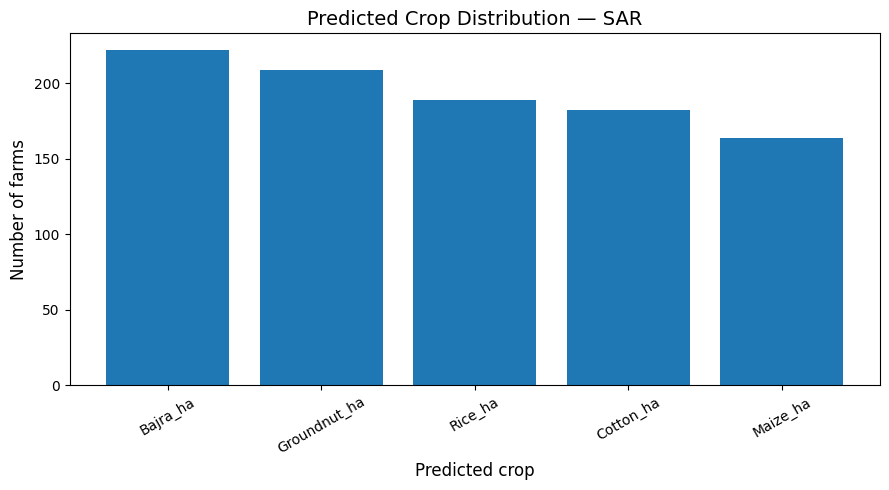

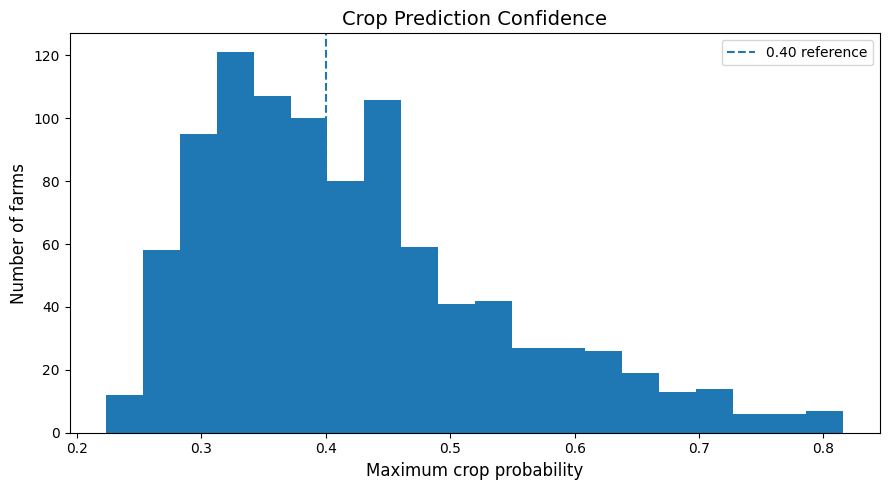

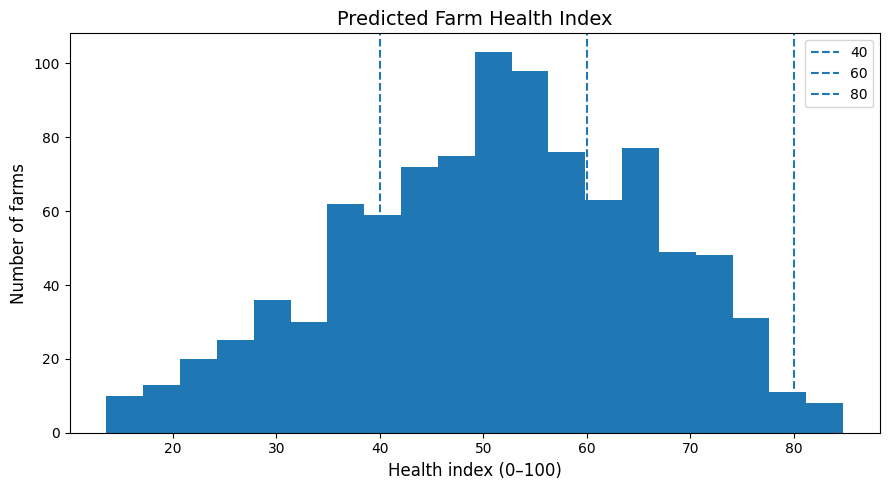

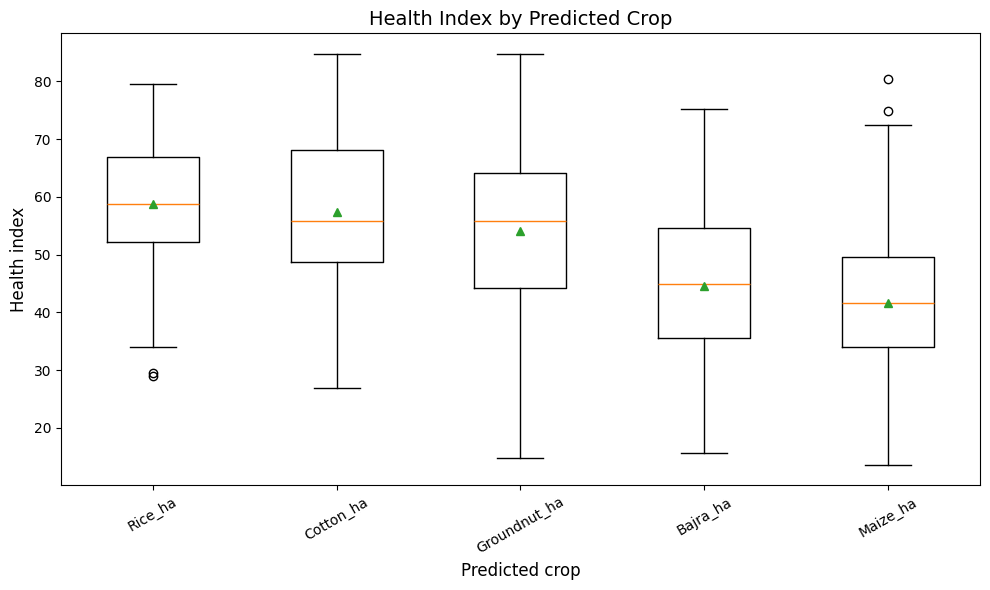

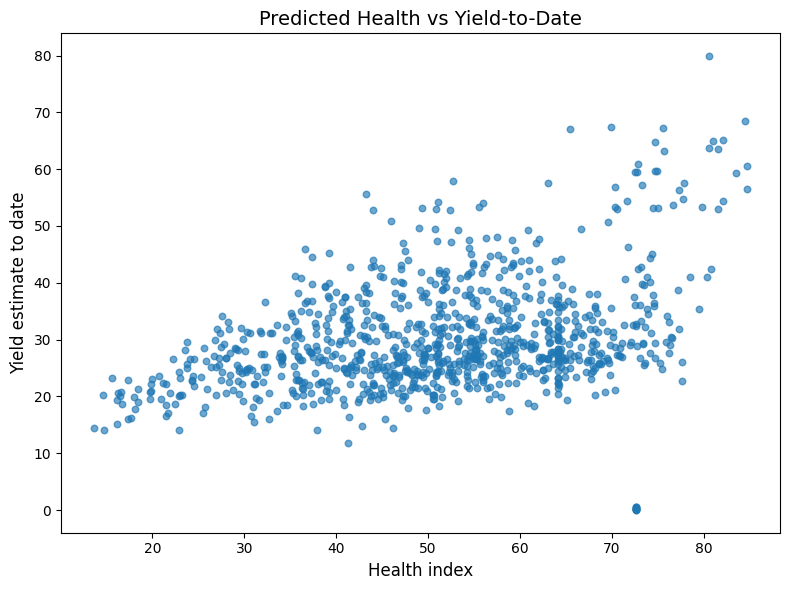

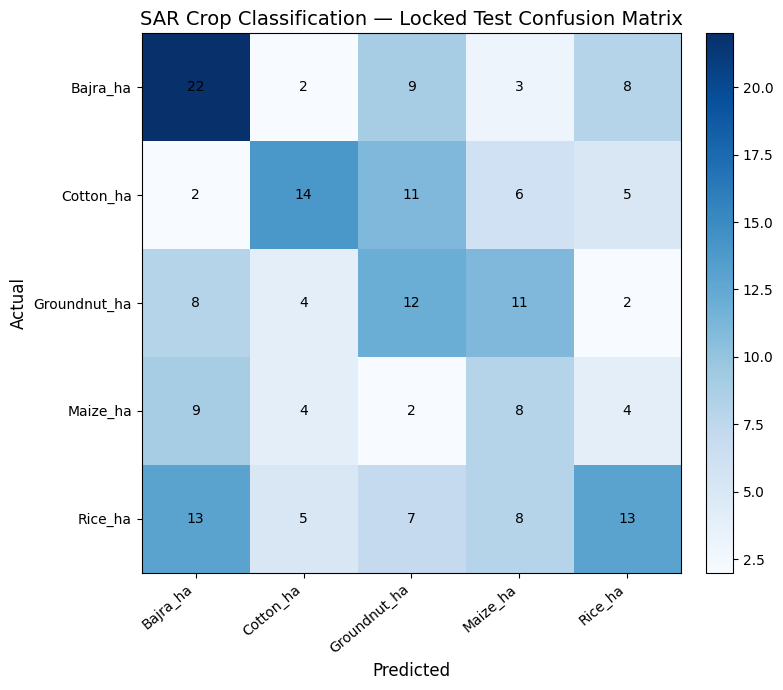

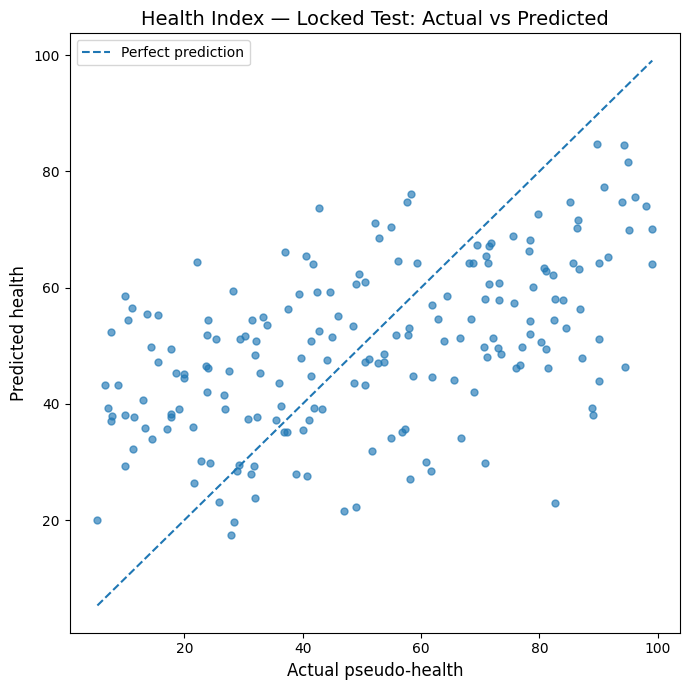

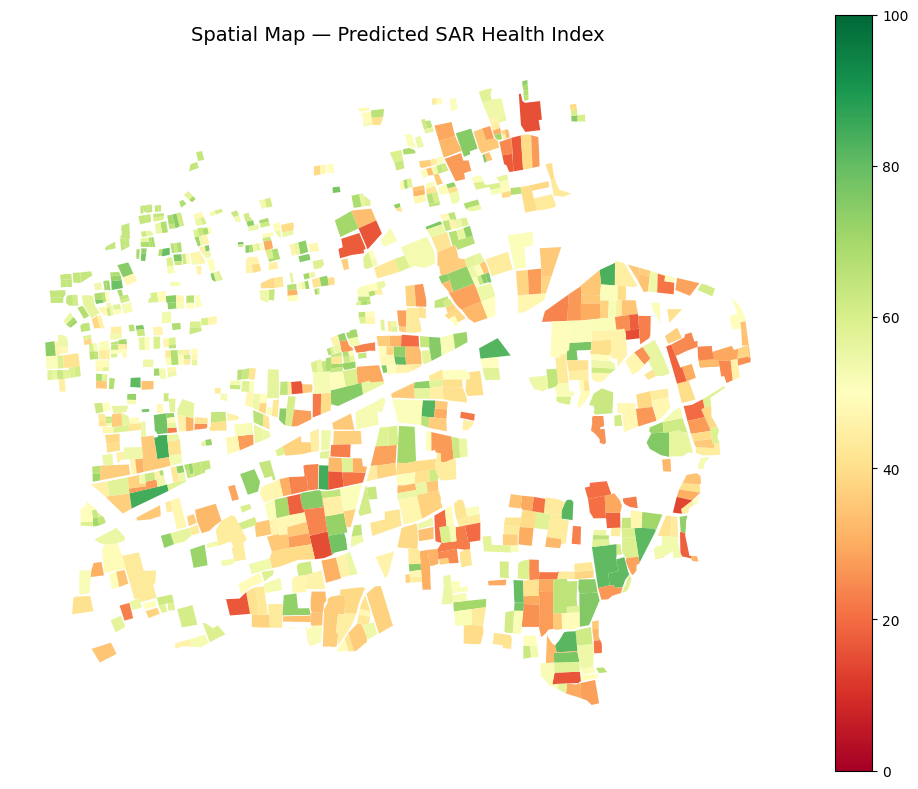

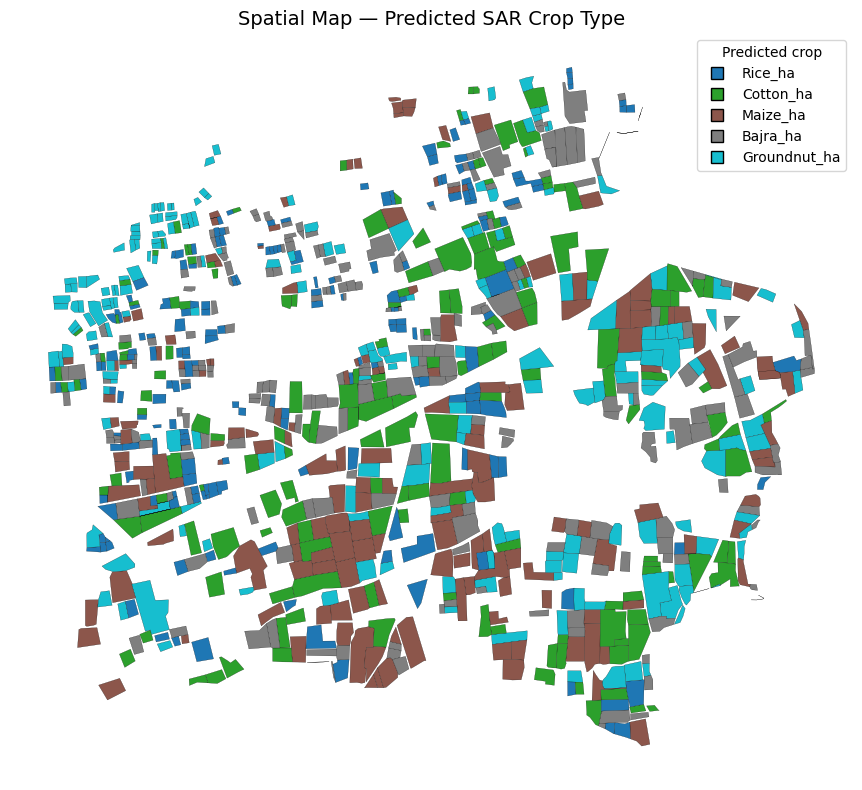

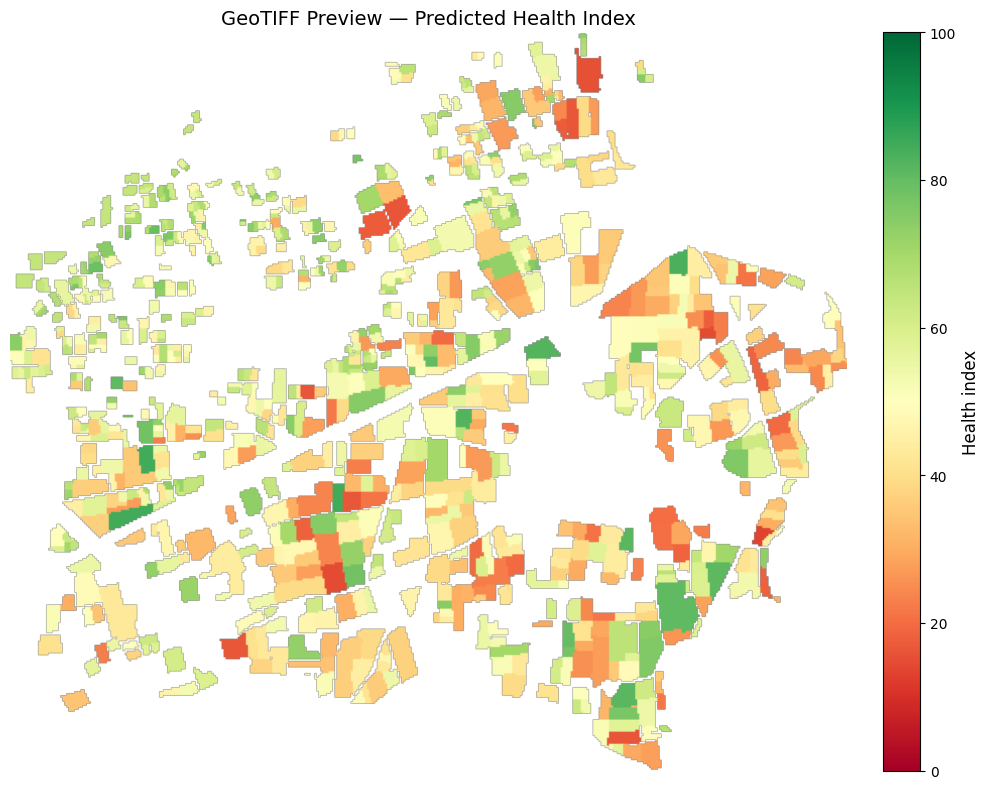


SAR OUTPUTS CREATED
✓ /kaggle/working/SAR_Crop_Health_Outputs/final_sar_crop_health_yield.csv
✓ /kaggle/working/SAR_Crop_Health_Outputs/model_test_metrics.csv
✓ /kaggle/working/SAR_Crop_Health_Outputs/predicted_crop_summary.csv
✓ /kaggle/working/SAR_Crop_Health_Outputs/health_summary_by_crop.csv
✓ /kaggle/working/SAR_Crop_Health_Outputs/crop_code_legend.csv
✓ /kaggle/working/SAR_Crop_Health_Outputs/health_status_legend.csv
✓ /kaggle/working/SAR_Crop_Health_Outputs/final_sar_crop_health_yield.gpkg
✓ /kaggle/working/SAR_Crop_Health_Outputs/predicted_crop_type.tif
✓ /kaggle/working/SAR_Crop_Health_Outputs/predicted_health_index.tif
✓ /kaggle/working/SAR_Crop_Health_Outputs/crop_confidence.tif
✓ /kaggle/working/SAR_Crop_Health_Outputs/yield_estimate_to_date.tif
✓ /kaggle/working/SAR_Crop_Health_Outputs/sar_crop_health_yield_stack.tif

Graphs saved under: /kaggle/working/SAR_Crop_Health_Outputs/plots
  ✓ 01_predicted_crop_distribution.png
  ✓ 02_crop_confidence_distribution.png
  ✓ 03_heal

,crop_type,farms,mean_health,median_health,min_health,max_health,mean_crop_confidence,mean_yield_estimate
4,Rice_ha,189,58.700424,58.825336,28.967468,79.464355,0.363366,29.085666
1,Cotton_ha,182,57.432114,55.858727,26.922640,84.717712,0.506229,34.608513
2,Groundnut_ha,209,54.118675,55.869221,14.751045,84.748146,0.389639,31.246870
0,Bajra_ha,222,44.487759,44.903908,15.562252,75.242722,0.457991,25.963904
3,Maize_ha,164,41.541656,41.531212,13.604181,80.391312,0.394227,30.655794



Predicted crop distribution:


,crop_type,predicted_farm_count,percentage
0,Bajra_ha,222,22.981366
1,Groundnut_ha,209,21.635611
2,Rice_ha,189,19.565217
3,Cotton_ha,182,18.840580
4,Maize_ha,164,16.977226



Done. The combined GeoTIFF contains:
  Band 1 = predicted crop code
  Band 2 = health index
  Band 3 = crop confidence
  Band 4 = yield estimate to date


In [200]:
# =============================================================================
# SECTION 16: SAR CROP + HEALTH OUTPUTS, GRAPHS, MAPS AND GEOTIFFS
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize

SAR_OUTPUT_DIR = Path("/kaggle/working/SAR_Crop_Health_Outputs")
PLOTS_DIR = SAR_OUTPUT_DIR / "plots"
SAR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_SAR_CSV = SAR_OUTPUT_DIR / "final_sar_crop_health_yield.csv"
FINAL_SAR_GPKG = SAR_OUTPUT_DIR / "final_sar_crop_health_yield.gpkg"
CROP_TIF_OUT = SAR_OUTPUT_DIR / "predicted_crop_type.tif"
HEALTH_TIF_OUT = SAR_OUTPUT_DIR / "predicted_health_index.tif"
CONF_TIF_OUT = SAR_OUTPUT_DIR / "crop_confidence.tif"
YIELD_TIF_OUT = SAR_OUTPUT_DIR / "yield_estimate_to_date.tif"
COMBINED_TIF_OUT = SAR_OUTPUT_DIR / "sar_crop_health_yield_stack.tif"
CROP_LEGEND_OUT = SAR_OUTPUT_DIR / "crop_code_legend.csv"
HEALTH_LEGEND_OUT = SAR_OUTPUT_DIR / "health_status_legend.csv"
MODEL_METRICS_OUT = SAR_OUTPUT_DIR / "model_test_metrics.csv"
HEALTH_BY_CROP_OUT = SAR_OUTPUT_DIR / "health_summary_by_crop.csv"
CROP_SUMMARY_OUT = SAR_OUTPUT_DIR / "predicted_crop_summary.csv"

# -----------------------------------------------------------------------------
# 16.1 Final tabular output
# -----------------------------------------------------------------------------
if "submission_df" not in globals() or submission_df is None or submission_df.empty:
    raise RuntimeError("submission_df is not available. Run the SAR model training cell first.")

sar_results = submission_df.copy()
if "farm_id" not in sar_results.columns:
    raise ValueError("submission_df must contain farm_id.")
sar_results["farm_id"] = pd.to_numeric(sar_results["farm_id"], errors="coerce")
sar_results = sar_results.dropna(subset=["farm_id"]).copy()
sar_results["farm_id"] = sar_results["farm_id"].astype(int)

if "crop_type" in sar_results.columns:
    sar_results["crop_type"] = sar_results["crop_type"].fillna("Unknown").astype(str)
for col in ["health_index", "crop_confidence", "yield_estimate_to_date"]:
    if col in sar_results.columns:
        sar_results[col] = pd.to_numeric(sar_results[col], errors="coerce")

sar_results.to_csv(FINAL_SAR_CSV, index=False)

print("=" * 78)
print("SAR CROP + HEALTH — OUTPUT EXPORT")
print("=" * 78)
print(f"Total prediction rows: {len(sar_results):,}")
print(f"Final CSV: {FINAL_SAR_CSV}")

# -----------------------------------------------------------------------------
# 16.2 Model test metrics / diagnostics
# -----------------------------------------------------------------------------
metrics_rows = []

crop_test_path = Path("/kaggle/working/crop_test_predictions.csv")
health_test_path = Path("/kaggle/working/health_test_predictions.csv")

if crop_test_path.exists():
    crop_test = pd.read_csv(crop_test_path)
    if {"actual_crop_type", "predicted_crop_type"}.issubset(crop_test.columns):
        from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
        yt = crop_test["actual_crop_type"].astype(str)
        yp = crop_test["predicted_crop_type"].astype(str)
        metrics_rows.append({
            "task": "crop_classification",
            "model": "SAR crop classifier",
            "n_test": len(crop_test),
            "accuracy": accuracy_score(yt, yp),
            "balanced_accuracy": balanced_accuracy_score(yt, yp),
            "macro_f1": f1_score(yt, yp, average="macro", zero_division=0),
            "mae": np.nan,
            "r2": np.nan,
            "spearman": np.nan,
        })
else:
    crop_test = None

if health_test_path.exists():
    health_test = pd.read_csv(health_test_path)
    if {"actual_health", "predicted_health"}.issubset(health_test.columns):
        from sklearn.metrics import mean_absolute_error, r2_score
        from scipy.stats import spearmanr
        actual = pd.to_numeric(health_test["actual_health"], errors="coerce")
        pred = pd.to_numeric(health_test["predicted_health"], errors="coerce")
        valid = actual.notna() & pred.notna()
        if valid.any():
            metrics_rows.append({
                "task": "health_regression",
                "model": "selected health model",
                "n_test": int(valid.sum()),
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                "macro_f1": np.nan,
                "mae": mean_absolute_error(actual[valid], pred[valid]),
                "r2": r2_score(actual[valid], pred[valid]),
                "spearman": spearmanr(actual[valid], pred[valid]).statistic,
            })
else:
    health_test = None

model_metrics_df = pd.DataFrame(metrics_rows)
model_metrics_df.to_csv(MODEL_METRICS_OUT, index=False)

# -----------------------------------------------------------------------------
# 16.3 Summary tables
# -----------------------------------------------------------------------------
if "crop_type" in sar_results.columns:
    crop_summary = (
        sar_results["crop_type"]
        .value_counts(dropna=False)
        .rename_axis("crop_type")
        .reset_index(name="predicted_farm_count")
    )
    crop_summary["percentage"] = 100.0 * crop_summary["predicted_farm_count"] / max(len(sar_results), 1)
    crop_summary.to_csv(CROP_SUMMARY_OUT, index=False)
else:
    crop_summary = pd.DataFrame()

if {"crop_type", "health_index", "crop_confidence", "yield_estimate_to_date"}.issubset(sar_results.columns):
    health_by_crop = (
        sar_results.groupby("crop_type")
        .agg(
            farms=("farm_id", "count"),
            mean_health=("health_index", "mean"),
            median_health=("health_index", "median"),
            min_health=("health_index", "min"),
            max_health=("health_index", "max"),
            mean_crop_confidence=("crop_confidence", "mean"),
            mean_yield_estimate=("yield_estimate_to_date", "mean"),
        )
        .reset_index()
        .sort_values("mean_health", ascending=False)
    )
else:
    health_by_crop = pd.DataFrame()

health_by_crop.to_csv(HEALTH_BY_CROP_OUT, index=False)

# -----------------------------------------------------------------------------
# 16.4 Crop / health status legends
# -----------------------------------------------------------------------------
TARGET_CROP_LIST = ["Rice_ha", "Cotton_ha", "Maize_ha", "Bajra_ha", "Groundnut_ha"]
observed_crops = sorted(set(sar_results.get("crop_type", pd.Series(dtype=str)).dropna().astype(str)))
all_crops = [c for c in TARGET_CROP_LIST if c in observed_crops] + [c for c in observed_crops if c not in TARGET_CROP_LIST]
crop_codes = {crop: i + 1 for i, crop in enumerate(all_crops)}
if "Unknown" in observed_crops and "Unknown" not in crop_codes:
    crop_codes["Unknown"] = 0

pd.DataFrame([
    {"class_code": code, "crop_type": crop}
    for crop, code in crop_codes.items()
]).sort_values("class_code").to_csv(CROP_LEGEND_OUT, index=False)

pd.DataFrame([
    {"health_min": 0, "health_max": 20, "health_status": "Severely low"},
    {"health_min": 20, "health_max": 40, "health_status": "Stressed"},
    {"health_min": 40, "health_max": 60, "health_status": "Below average / Watch"},
    {"health_min": 60, "health_max": 80, "health_status": "Good"},
    {"health_min": 80, "health_max": 100, "health_status": "Very good"},
]).to_csv(HEALTH_LEGEND_OUT, index=False)

# -----------------------------------------------------------------------------
# 16.5 Diagnostic graphs
# -----------------------------------------------------------------------------
plt.close("all")

# A. Predicted crop distribution
if not crop_summary.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(crop_summary["crop_type"], crop_summary["predicted_farm_count"])
    ax.set_title("Predicted Crop Distribution — SAR")
    ax.set_ylabel("Number of farms")
    ax.set_xlabel("Predicted crop")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "01_predicted_crop_distribution.png", dpi=180, bbox_inches="tight")
    plt.show()

# B. Crop confidence distribution
if "crop_confidence" in sar_results.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(sar_results["crop_confidence"].dropna(), bins=20)
    ax.axvline(0.40, linestyle="--", label="0.40 reference")
    ax.set_title("Crop Prediction Confidence")
    ax.set_xlabel("Maximum crop probability")
    ax.set_ylabel("Number of farms")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "02_crop_confidence_distribution.png", dpi=180, bbox_inches="tight")
    plt.show()

# C. Health distribution
if "health_index" in sar_results.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(sar_results["health_index"].dropna(), bins=20)
    ax.axvline(40, linestyle="--", label="40")
    ax.axvline(60, linestyle="--", label="60")
    ax.axvline(80, linestyle="--", label="80")
    ax.set_title("Predicted Farm Health Index")
    ax.set_xlabel("Health index (0–100)")
    ax.set_ylabel("Number of farms")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "03_health_distribution.png", dpi=180, bbox_inches="tight")
    plt.show()

# D. Health by predicted crop
if not health_by_crop.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    grouped = [
        sar_results.loc[sar_results["crop_type"] == crop, "health_index"].dropna().to_numpy()
        for crop in health_by_crop["crop_type"]
    ]
    ax.boxplot(grouped, labels=health_by_crop["crop_type"].tolist(), showmeans=True)
    ax.set_title("Health Index by Predicted Crop")
    ax.set_xlabel("Predicted crop")
    ax.set_ylabel("Health index")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "04_health_by_predicted_crop.png", dpi=180, bbox_inches="tight")
    plt.show()

# E. Health vs yield
if {"health_index", "yield_estimate_to_date"}.issubset(sar_results.columns):
    valid = sar_results[["health_index", "yield_estimate_to_date"]].dropna()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(valid["health_index"], valid["yield_estimate_to_date"], alpha=0.65, s=22)
    ax.set_title("Predicted Health vs Yield-to-Date")
    ax.set_xlabel("Health index")
    ax.set_ylabel("Yield estimate to date")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "05_health_vs_yield.png", dpi=180, bbox_inches="tight")
    plt.show()

# F. Crop confusion matrix
if crop_test is not None and {"actual_crop_type", "predicted_crop_type"}.issubset(crop_test.columns):
    from sklearn.metrics import confusion_matrix
    labels_cm = sorted(set(crop_test["actual_crop_type"].astype(str)) | set(crop_test["predicted_crop_type"].astype(str)))
    cm = confusion_matrix(crop_test["actual_crop_type"].astype(str), crop_test["predicted_crop_type"].astype(str), labels=labels_cm)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(np.arange(len(labels_cm)))
    ax.set_yticks(np.arange(len(labels_cm)))
    ax.set_xticklabels(labels_cm, rotation=40, ha="right")
    ax.set_yticklabels(labels_cm)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("SAR Crop Classification — Locked Test Confusion Matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "06_crop_confusion_matrix.png", dpi=180, bbox_inches="tight")
    plt.show()

# G. Health actual vs predicted
if health_test is not None and {"actual_health", "predicted_health"}.issubset(health_test.columns):
    h = health_test[["actual_health", "predicted_health"]].apply(pd.to_numeric, errors="coerce").dropna()
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(h["actual_health"], h["predicted_health"], alpha=0.65, s=25)
    lo = float(min(h.min()))
    hi = float(max(h.max()))
    ax.plot([lo, hi], [lo, hi], linestyle="--", label="Perfect prediction")
    ax.set_title("Health Index — Locked Test: Actual vs Predicted")
    ax.set_xlabel("Actual pseudo-health")
    ax.set_ylabel("Predicted health")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "07_health_actual_vs_predicted.png", dpi=180, bbox_inches="tight")
    plt.show()

# -----------------------------------------------------------------------------
# 16.6 Spatial prediction layer
# -----------------------------------------------------------------------------
# The optical/SAR notebooks use the original farm FID as the persistent ID.
if "farm_gdf" not in globals() or farm_gdf is None or farm_gdf.empty:
    farm_gdf = read_shapefile_from_zip(farm_zip, "farm boundaries for SAR export")

if farm_gdf is None or farm_gdf.empty:
    print("Spatial exports skipped: farm boundaries unavailable.")
else:
    base_gdf = farm_gdf.copy()
    if "field_id" not in base_gdf.columns:
        id_col = next((c for c in ["FID", "fid", "id", "ID"] if c in base_gdf.columns), None)
        if id_col is None:
            raise ValueError("Could not identify farm ID column in farm boundaries.")
        base_gdf["field_id"] = pd.to_numeric(base_gdf[id_col], errors="coerce")
    base_gdf["field_id"] = pd.to_numeric(base_gdf["field_id"], errors="coerce")
    base_gdf = base_gdf.dropna(subset=["field_id"]).copy()
    base_gdf["field_id"] = base_gdf["field_id"].astype(int)

    spatial_gdf = base_gdf[["field_id", "geometry"]].merge(
        sar_results.rename(columns={"farm_id": "field_id"}),
        on="field_id",
        how="left",
    )
    spatial_gdf = gpd.GeoDataFrame(spatial_gdf, geometry="geometry", crs=base_gdf.crs)
    spatial_gdf.to_file(FINAL_SAR_GPKG, layer="sar_crop_health_yield", driver="GPKG")

    # GIS maps in notebook
    if "health_index" in spatial_gdf.columns:
        fig, ax = plt.subplots(figsize=(10, 8))
        spatial_gdf.plot(column="health_index", ax=ax, cmap="RdYlGn", legend=True,
                         vmin=0, vmax=100, missing_kwds={"color": "lightgrey", "label": "No prediction"})
        ax.set_title("Spatial Map — Predicted SAR Health Index")
        ax.set_axis_off()
        fig.tight_layout()
        fig.savefig(PLOTS_DIR / "08_spatial_health_map.png", dpi=180, bbox_inches="tight")
        plt.show()

    if "crop_type" in spatial_gdf.columns:
        crop_colors = plt.cm.tab10(np.linspace(0, 1, max(len(crop_codes), 1)))
        color_map = {crop: crop_colors[i] for i, crop in enumerate(crop_codes.keys())}
        spatial_gdf["_crop_color"] = spatial_gdf["crop_type"].map(color_map)
        fig, ax = plt.subplots(figsize=(10, 8))
        spatial_gdf.plot(ax=ax, color=spatial_gdf["_crop_color"], edgecolor="black", linewidth=0.15,
                         missing_kwds={"color": "lightgrey"})
        handles = [plt.Line2D([0], [0], marker="s", linestyle="", markerfacecolor=color_map[c],
                              markeredgecolor="black", markersize=9, label=c) for c in color_map]
        ax.legend(handles=handles, title="Predicted crop", loc="best")
        ax.set_title("Spatial Map — Predicted SAR Crop Type")
        ax.set_axis_off()
        fig.tight_layout()
        fig.savefig(PLOTS_DIR / "09_spatial_crop_map.png", dpi=180, bbox_inches="tight")
        plt.show()

    # Reproject to a local projected CRS for metre-based rasterization.
    raster_gdf = spatial_gdf.copy()
    if raster_gdf.crs is None:
        raise ValueError("Farm boundaries have no CRS; cannot create GeoTIFF outputs.")
    if raster_gdf.crs.is_geographic:
        try:
            projected_crs = raster_gdf.estimate_utm_crs()
        except Exception:
            projected_crs = None
        if projected_crs is not None:
            raster_gdf = raster_gdf.to_crs(projected_crs)

    minx, miny, maxx, maxy = raster_gdf.total_bounds
    target_resolution = 10.0  # metres when using projected UTM-style CRS
    width = max(1, int(np.ceil((maxx - minx) / target_resolution)))
    height = max(1, int(np.ceil((maxy - miny) / target_resolution)))

    # Prevent an unexpectedly huge raster in a future dataset.
    if width > 5000 or height > 5000:
        target_resolution = max((maxx - minx) / 5000.0, (maxy - miny) / 5000.0)
        width = max(1, int(np.ceil((maxx - minx) / target_resolution)))
        height = max(1, int(np.ceil((maxy - miny) / target_resolution)))

    transform = from_origin(minx, maxy, target_resolution, target_resolution)
    out_shape = (height, width)

    def raster_values(column, dtype, fill):
        vals = pd.to_numeric(raster_gdf[column], errors="coerce") if column in raster_gdf.columns else pd.Series(np.nan, index=raster_gdf.index)
        shapes = []
        for geom, val in zip(raster_gdf.geometry, vals):
            if geom is None or geom.is_empty or not np.isfinite(val):
                continue
            shapes.append((geom, val))
        return rasterize(
            shapes,
            out_shape=out_shape,
            transform=transform,
            fill=fill,
            dtype=dtype,
            all_touched=False,
        )

    crop_raster = np.zeros(out_shape, dtype=np.uint8)
    if "crop_type" in raster_gdf.columns:
        crop_shapes = []
        for geom, crop in zip(raster_gdf.geometry, raster_gdf["crop_type"]):
            if geom is None or geom.is_empty or pd.isna(crop):
                continue
            code = crop_codes.get(str(crop), 0)
            crop_shapes.append((geom, code))
        crop_raster = rasterize(crop_shapes, out_shape=out_shape, transform=transform, fill=0, dtype="uint8")

    health_raster = raster_values("health_index", "float32", -9999.0)
    conf_raster = raster_values("crop_confidence", "float32", -9999.0)
    yield_raster = raster_values("yield_estimate_to_date", "float32", -9999.0)

    profile = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": 1,
        "crs": raster_gdf.crs,
        "transform": transform,
        "compress": "deflate",
    }

    profile.update(dtype="uint8", nodata=0)
    with rasterio.open(CROP_TIF_OUT, "w", **profile) as dst:
        dst.write(crop_raster, 1)
        dst.update_tags(description="Predicted SAR crop type class code", legend=str(CROP_LEGEND_OUT))

    profile.update(dtype="float32", nodata=-9999.0)
    for path, arr, desc in [
        (HEALTH_TIF_OUT, health_raster, "Predicted SAR health index, 0-100; higher is better"),
        (CONF_TIF_OUT, conf_raster, "Maximum predicted crop probability / crop confidence"),
        (YIELD_TIF_OUT, yield_raster, "Predicted yield-to-date estimate"),
    ]:
        with rasterio.open(path, "w", **profile) as dst:
            dst.write(arr.astype(np.float32), 1)
            dst.update_tags(description=desc)

    # Combined GIS-ready stack: crop code, health, crop confidence, yield.
    stack_profile = profile.copy()
    stack_profile.update(count=4, dtype="float32", nodata=-9999.0)
    with rasterio.open(COMBINED_TIF_OUT, "w", **stack_profile) as dst:
        dst.write(crop_raster.astype(np.float32), 1)
        dst.write(health_raster.astype(np.float32), 2)
        dst.write(conf_raster.astype(np.float32), 3)
        dst.write(yield_raster.astype(np.float32), 4)
        dst.set_band_description(1, "predicted_crop_code")
        dst.set_band_description(2, "health_index")
        dst.set_band_description(3, "crop_confidence")
        dst.set_band_description(4, "yield_estimate_to_date")
        dst.update_tags(
            description="SAR crop + health + yield prediction stack",
            crop_legend=str(CROP_LEGEND_OUT),
            health_legend=str(HEALTH_LEGEND_OUT),
            resolution_m=float(target_resolution),
        )

    # Categorical + continuous raster map previews.
    fig, ax = plt.subplots(figsize=(10, 8))
    masked_health = np.ma.masked_where(health_raster == -9999.0, health_raster)
    im = ax.imshow(masked_health, cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_title("GeoTIFF Preview — Predicted Health Index")
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Health index")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "10_geotiff_health_preview.png", dpi=180, bbox_inches="tight")
    plt.show()

# -----------------------------------------------------------------------------
# 16.7 Final output summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 78)
print("SAR OUTPUTS CREATED")
print("=" * 78)
for path in [
    FINAL_SAR_CSV,
    MODEL_METRICS_OUT,
    CROP_SUMMARY_OUT,
    HEALTH_BY_CROP_OUT,
    CROP_LEGEND_OUT,
    HEALTH_LEGEND_OUT,
    FINAL_SAR_GPKG,
    CROP_TIF_OUT,
    HEALTH_TIF_OUT,
    CONF_TIF_OUT,
    YIELD_TIF_OUT,
    COMBINED_TIF_OUT,
]:
    print(f"{'✓' if path.exists() else '✗'} {path}")

print(f"\nGraphs saved under: {PLOTS_DIR}")
for p in sorted(PLOTS_DIR.glob("*.png")):
    print(f"  ✓ {p.name}")

if not health_by_crop.empty:
    print("\nHealth summary by predicted crop:")
    display(health_by_crop)

if not crop_summary.empty:
    print("\nPredicted crop distribution:")
    display(crop_summary)

print("\nDone. The combined GeoTIFF contains:")
print("  Band 1 = predicted crop code")
print("  Band 2 = health index")
print("  Band 3 = crop confidence")
print("  Band 4 = yield estimate to date")
